# "Smart Value" Strategy
## Master Finance - "Alternative Risk Premia" Course
**FULL PERIOD: 2007-2025 With IS: 2007-2020, OOS: 2021-2025** 

## 1. Data, HMM and functions

In [4]:
# -----------------------------------------------------------------------------
# VALUE-HMM EUROPE -- DATA LOADING & PREPARATION (Sections 0-6 + HMM)
# -----------------------------------------------------------------------------


import os
import time
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")
_START_TIME = time.time()


# -----------------------------------------------------------------------------
# SECTION 0 -- CONFIGURATION
# -----------------------------------------------------------------------------
try:
    DATA_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    DATA_DIR = os.path.abspath(".")
print(f"[Value-HMM EUR] DATA_DIR = {DATA_DIR}")

PARAMS = {
    "start_date":       "2007-01-01", 
    "end_date":         "2025-12-31", 
    "warmup_date":      "2003-01-01",  
    "prices_start":     "2003-01-01", 
    "initial_capital":  10_000_000,

    "pit_lag_days":     60,  

    # -- Portfolio construction
    "n_core":               25,
    "n_satellite":          5,
    "core_pct":             0.80,
    "satellite_max_pct":    0.20,
    "cash_min_pct":         0.00,

    # -- Weight constraints
    "max_weight_single":    0.06,
    "max_weight_sector":    0.25,
    "drift_band":           0.03,

    # -- Fundamental filters
    "fscore_min":           7,
    "fscore_sell":          5,
    "core_fscore_min":      7,
    "sat_fscore_min":       5,

    # -- Universe filters
    "mktcap_min":               150,   
    "mktcap_max":             25000,
    "price_min":                3.0,    
    "volume_eur_min_MEUR":      1.0,
    "volume_lookback_months":   3,
    "mktcap_smallcap_threshold": 500,
    "mom_trap_floor":          -0.25,
    "max_neg_earnings_exposure": 0.15,

    # -- HMM
    "hmm_n_states":         3,
    "hmm_train_window":     60,  
    "hmm_prob_threshold":   0.70,

    # -- Regime allocation targets
    "core_target_bull":         0.85,
    "core_target_transition":   0.80,
    "core_target_bear":         0.72,
    "sat_target_bull":          0.12,
    "sat_target_transition":    0.07,
    "sat_target_bear":          0.00,
    "cash_floor_bull":          0.03,
    "cash_floor_transition":    0.05,
    "cash_floor_bear":          0.08,

    # -- Deployment
    "deploy_bull":          0.80,
    "deploy_transition":    0.40,

    # -- Transaction costs (continuous formula v1.5)
    # TC_bps = tc_formula_coeff / mktcap_B ^ tc_formula_exp
    "tc_formula_coeff":     30.0,
    "tc_formula_exp":       0.4,
    "tc_equity":            0.0030,    
    "tc_etf":               0.0010,
    "tc_mmf":               0.0002,
    "tc_fx":                0.0010,

    # -- Eurozone countries
    "eurozone_countries": [
        "AUT", "BEL", "CYP", "DEU", "ESP", "EST", "FIN", "FRA",
        "GRC", "HRV", "IRL", "ITA", "LTU", "LUX", "LVA", "MLT",
        "NLD", "PRT", "SVK", "SVN",
    ],

    # -- Sector caps (GICS level 1)
    "sectors_extra_cap": {40: 0.20, 60: 0.15},

    # -- Extended Europe (disabled by default)
    "extended_europe": False,
    "extended_countries": ["GBR", "CHE", "SWE", "NOR", "DNK"],

    # -- QARP filter
    "qarp_exclude_top_pct": 0.10,

    # -- Low-vol tilt in composite score
    "lowvol_weight": 0.07,

    # -- Partial rebalancing
    "rebal_n_rotate_pct": 0.25,
    "rebal_tc_buffer_score": 0.05,

    # -- BCE DFR (optional HMM feature)
    "bce_rate_file": "BCE_DFR.csv",
}

print(f"[Value-HMM EUR] Backtest OOS: {PARAMS['start_date']} -> {PARAMS['end_date']}")
print(f"  Capital: {PARAMS['initial_capital']:,.0f} EUR | "
      f"Core: {PARAMS['n_core']} titles | PIT lag: {PARAMS['pit_lag_days']}d")


# -----------------------------------------------------------------------------
# SECTION 1 -- RISK-FREE RATE EUR (EONIA + EUR-STR -> MONTHLY)
# -----------------------------------------------------------------------------
print("\n[1/7] Risk-free rate EUR (EONIA -> EUR-STR)...")

# EONIA daily -> monthly compounding (Act/360)
_eonia_raw = pd.read_csv(f"{DATA_DIR}/EONIARATE.csv",
                         parse_dates=["observation_date"])
_eonia_raw = _eonia_raw.rename(columns={"observation_date": "date",
                                        "EONIARATE": "rate_ann"})
_eonia_raw["daily_ret"] = _eonia_raw["rate_ann"] / 100 / 360
_eonia_raw["month_end"] = _eonia_raw["date"] + pd.offsets.MonthEnd(0)

eonia_monthly = (
    _eonia_raw.groupby("month_end")["daily_ret"]
    .apply(lambda x: (1 + x).prod() - 1)
    .rename("rf_monthly")
)

# EUR-STR daily -> monthly compounding
_str_raw = pd.read_csv(f"{DATA_DIR}/STR.csv",
                       usecols=["TIME_PERIOD", "OBS_VALUE"],
                       parse_dates=["TIME_PERIOD"])
_str_raw = _str_raw.rename(columns={"TIME_PERIOD": "date",
                                    "OBS_VALUE": "rate_ann"})
_str_raw["daily_ret"] = _str_raw["rate_ann"] / 100 / 360
_str_raw["month_end"] = _str_raw["date"] + pd.offsets.MonthEnd(0)

str_monthly = (
    _str_raw.groupby("month_end")["daily_ret"]
    .apply(lambda x: (1 + x).prod() - 1)
    .rename("rf_monthly")
)

rf_monthly = str_monthly.combine_first(eonia_monthly).sort_index()

print(f"  RF monthly: {rf_monthly.index.min():%Y-%m} -> "
      f"{rf_monthly.index.max():%Y-%m} ({len(rf_monthly)} months)")
print(f"  Min={rf_monthly.min()*100:.3f}%/m | "
      f"Max={rf_monthly.max()*100:.3f}%/m | "
      f"Mean={rf_monthly.mean()*100:.3f}%/m")

# -----------------------------------------------------------------------------
# SECTION 1.5 -- BCE DEPOSIT FACILITY RATE (optional HMM feature)
# -----------------------------------------------------------------------------
print("\n[1.5/7] BCE DFR (HMM feature)...")

_bce_has_data = False
_bce_monthly = None

try:
    _bce_path = f"{DATA_DIR}/{PARAMS['bce_rate_file']}"
    _bce_raw = pd.read_csv(_bce_path, low_memory=False)
    _bce_raw.columns = [c.strip().lower() for c in _bce_raw.columns]

    _date_col = next((c for c in _bce_raw.columns
                      if c in ("date", "time_period", "obs_date")), None)
    _val_col = next((c for c in _bce_raw.columns
                     if c in ("rate", "obs_value", "value", "dfr")), None)
    if _date_col is None or _val_col is None:
        raise ValueError(f"Expected columns not found. Available: {list(_bce_raw.columns)}")

    _bce_raw["_date"] = pd.to_datetime(_bce_raw[_date_col], errors="coerce")
    _bce_raw["_rate"] = pd.to_numeric(_bce_raw[_val_col], errors="coerce")
    _bce_raw = _bce_raw.dropna(subset=["_date", "_rate"]).sort_values("_date")
    _bce_raw["_month_end"] = _bce_raw["_date"] + pd.offsets.MonthEnd(0)

    _bce_monthly = (
        _bce_raw.groupby("_month_end")["_rate"].last()
        .rename("bce_dfr")
        .reindex(pd.date_range(_bce_raw["_month_end"].min(),
                               _bce_raw["_month_end"].max(), freq="ME"))
        .ffill()
    )
    _bce_has_data = True
    print(f"  BCE DFR loaded: {_bce_monthly.index.min():%Y-%m} -> "
          f"{_bce_monthly.index.max():%Y-%m} ({len(_bce_monthly)} months)")
    print(f"  Min={_bce_monthly.min():.2f}%/y | Max={_bce_monthly.max():.2f}%/y")

except FileNotFoundError:
    print(f"  WARNING: {PARAMS['bce_rate_file']} not found -> HMM with 4 features")
except Exception as _bce_exc:
    print(f"  WARNING: BCE DFR load error: {_bce_exc} -> HMM with 4 features")


# -----------------------------------------------------------------------------
# SECTION 2 -- FAMA-FRENCH 5 FACTORS EUROPE
# -----------------------------------------------------------------------------
print("\n[2/7] FF5 Europe factors...")

ff5_raw = pd.read_table(f"{DATA_DIR}/Europe_5_Factors.txt",
                        skiprows=6, sep=r"\s+", on_bad_lines="skip")
ff5_raw = ff5_raw.reset_index().rename(columns={ff5_raw.reset_index().columns[0]: "yyyymm"})
ff5_raw["yyyymm"] = ff5_raw["yyyymm"].astype(str).str.strip()
ff5_raw = ff5_raw[ff5_raw["yyyymm"].str.match(r"^\d{6}$", na=False)].copy()
ff5_raw["date"] = pd.to_datetime(ff5_raw["yyyymm"], format="%Y%m") + pd.offsets.MonthEnd(0)

for col in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]:
    ff5_raw[col] = pd.to_numeric(ff5_raw[col], errors="coerce")

ff5 = ff5_raw.set_index("date")[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]].dropna()

ff5["FF5_RF"] = ff5["RF"] / 100.0
_rf_mapped = rf_monthly.reindex(ff5.index)
ff5["RF"] = _rf_mapped.fillna(ff5["FF5_RF"]).values
ff5["Mkt_ret"] = ff5["Mkt-RF"] / 100.0 + ff5["RF"]

print(f"  FF5 Europe: {ff5.index.min():%Y-%m} -> {ff5.index.max():%Y-%m} "
      f"({len(ff5)} months)")


# -----------------------------------------------------------------------------
# SECTION 3 -- HMM WALK-FORWARD (REGIME DETECTION)
# -----------------------------------------------------------------------------
print("\n[3/7] HMM features & walk-forward training...")

feat = pd.DataFrame(index=ff5.index)
feat["Mkt-RF"] = ff5["Mkt-RF"]
feat["HML"] = ff5["HML"]
feat["RMW"] = ff5["RMW"]
feat["Mkt_vol_6m"] = ff5["Mkt-RF"].rolling(6, min_periods=4).std()

# Optional feature 5: BCE DFR level
if _bce_has_data and _bce_monthly is not None:
    _bce_aligned = (
        _bce_monthly.copy()
        .rename_axis("date")
        .pipe(lambda s: s.set_axis(s.index + pd.offsets.MonthEnd(0)))
        .reindex(ff5.index + pd.offsets.MonthEnd(0))
        .ffill()
    )
    _bce_aligned.index = ff5.index
    feat["bce_dfr"] = _bce_aligned.shift(1)
    _bce_cover = feat["bce_dfr"].notna().mean()
    print(f"  BCE DFR aligned: coverage {_bce_cover:.1%}")
    if _bce_cover < 0.80:
        print(f"  WARNING: low coverage -> dropping bce_dfr from features")
        feat = feat.drop(columns=["bce_dfr"])

feat = feat.dropna().copy()
print(f"  HMM features: {list(feat.columns)}")
print(f"  Feature period: {feat.index.min():%Y-%m} -> {feat.index.max():%Y-%m}")


def run_hmm_walkforward(feat_df: pd.DataFrame,
                        train_w: int = 36,
                        mode: str = "expanding") -> pd.DataFrame:
    """
    Walk-forward Gaussian HMM (3 states) with expanding window.
    Labels states by mean Mkt-RF: BULLISH > TRANSITION > BEARISH.
    Double-lock confirmation: same regime 2 consecutive months + prob >= threshold.
    """
    rows = []
    n = len(feat_df)

    for i in range(train_w, n):
        window = feat_df.iloc[:i] if mode == "expanding" else feat_df.iloc[i - train_w:i]
        curr_date = feat_df.index[i]

        # Z-score standardization within window
        mu = window.mean()
        sig = window.std().replace(0, 1e-8)
        window_sc = (window - mu) / sig

        model = GaussianHMM(
            n_components=PARAMS["hmm_n_states"],
            covariance_type="diag",
            n_iter=300, tol=1e-4,
            random_state=42,
            init_params="mc", params="stmc",
        )
        # Persistence prior (diagonal ~87%)
        model.transmat_ = np.array([
            [0.87, 0.09, 0.04],
            [0.06, 0.88, 0.06],
            [0.04, 0.09, 0.87],
        ])

        try:
            model.fit(window_sc.values)

            # Epsilon smoothing on transmat (avoid zero-row states)
            _eps = 1e-6
            _tm = model.transmat_ + _eps
            model.transmat_ = _tm / _tm.sum(axis=1, keepdims=True)

            # Semantic labelling by Mkt-RF mean per state
            state_mkt_avg = {s: model.means_[s, 0] for s in range(PARAMS["hmm_n_states"])}
            ordered = sorted(state_mkt_avg, key=state_mkt_avg.get, reverse=True)
            label_map = {ordered[0]: "BULLISH",
                         ordered[1]: "TRANSITION",
                         ordered[2]: "BEARISH"}

            # Decode on recent 12 months for Viterbi stability
            recent = feat_df.iloc[max(0, i - 36):i + 1]
            recent_sc = (recent - mu) / sig
            _, seq = model.decode(recent_sc.values, algorithm="viterbi")
            probs = model.predict_proba(recent_sc.values)

            st, pr = seq[-1], probs[-1]
            rows.append({
                "date": curr_date,
                "regime": label_map[st],
                "max_prob": pr.max(),
                "prob_bull": pr[ordered[0]],
                "prob_bear": pr[ordered[2]],
            })

        except Exception:
            rows.append({
                "date": curr_date,
                "regime": "TRANSITION",
                "max_prob": 1.0 / PARAMS["hmm_n_states"],
                "prob_bull": 1.0 / PARAMS["hmm_n_states"],
                "prob_bear": 1.0 / PARAMS["hmm_n_states"],
            })

    out = pd.DataFrame(rows).set_index("date")

    # Double-lock confirmation
    out["regime_prev"] = out["regime"].shift(1)
    out["confirmed"] = (
        (out["regime"] == out["regime_prev"])
        & (out["max_prob"] >= PARAMS["hmm_prob_threshold"])
    )
    out["regime_conf"] = np.where(out["confirmed"], out["regime"], "TRANSITION")
    return out


print("  Training HMM walk-forward (expanding window)...")
_t0 = time.time()

hmm_df = run_hmm_walkforward(feat,
                             train_w=PARAMS["hmm_train_window"],
                             mode="expanding")
hmm_df_oos = hmm_df  # meme objet, walk-forward garantit l'integrite

_elapsed = time.time() - _t0
print(f"  Done in {_elapsed:.1f}s")
print(f"  Confirmed regime distribution (full): {hmm_df['regime_conf'].value_counts().to_dict()}")
print(f"  Confirmed regime distribution (IS-only): {hmm_df_oos['regime_conf'].value_counts().to_dict()}")


# -----------------------------------------------------------------------------
# SECTION 4 -- FX CROSS-RATES EUR
# -----------------------------------------------------------------------------

print("\n[4/7] FX cross-rates EUR...")

_fx_raw = pd.read_csv(f"{DATA_DIR}/Taux de change ",
                      parse_dates=["date"], low_memory=False)
_fx_raw = _fx_raw.sort_values("date").set_index("date")

_fx_cols_needed = ["exeuus", "exuseu", "exusuk", "exszus", "exsdus", "exnous", "exdnus"]
for _c in _fx_cols_needed:
    if _c in _fx_raw.columns:
        _fx_raw[_c] = pd.to_numeric(_fx_raw[_c], errors="coerce")

fx = pd.DataFrame(index=_fx_raw.index)
fx["EUR_per_USD"] = _fx_raw["exeuus"]
if "exusuk" in _fx_raw.columns:
    fx["EUR_per_GBP"] = _fx_raw["exeuus"] * _fx_raw["exusuk"]
if "exszus" in _fx_raw.columns:
    fx["EUR_per_CHF"] = _fx_raw["exeuus"] / _fx_raw["exszus"]
if "exsdus" in _fx_raw.columns:
    fx["EUR_per_SEK"] = _fx_raw["exeuus"] / _fx_raw["exsdus"]
if "exnous" in _fx_raw.columns:
    fx["EUR_per_NOK"] = _fx_raw["exeuus"] / _fx_raw["exnous"]
if "exdnus" in _fx_raw.columns:
    fx["EUR_per_DKK"] = _fx_raw["exeuus"] / _fx_raw["exdnus"]

fx_ret = fx.pct_change()
fx.index = fx.index + pd.offsets.MonthEnd(0)
fx_ret.index = fx_ret.index + pd.offsets.MonthEnd(0)

CURRENCY_TO_FX_COL = {
    "GBP": "EUR_per_GBP", "CHF": "EUR_per_CHF", "SEK": "EUR_per_SEK",
    "NOK": "EUR_per_NOK", "DKK": "EUR_per_DKK", "USD": "EUR_per_USD",
}
_fx_avail = [k for k, v in CURRENCY_TO_FX_COL.items() if v in fx_ret.columns]
print(f"  Cross-rates available: {_fx_avail}")
print(f"  FX period: {fx.dropna(how='all').index.min():%Y-%m} -> "
      f"{fx.dropna(how='all').index.max():%Y-%m}")

# -----------------------------------------------------------------------------
# SECTION 5 -- QUARTERLY FUNDAMENTALS (POINT-IN-TIME)
# -----------------------------------------------------------------------------
print("\n[5/7] Quarterly fundamentals (PIT)...")

FUNDA_COLS = [
    "gvkey", "datadate", "fyearq", "datafqtr",
    "fic", "gsector", "gind", "costat", "dldte",
    "actq", "atq", "ceqq", "cheq",
    "dlcq", "dlttq", "dpq", "gpq",
    "ibq", "lctq", "oiadpq",
    "saleq", "cfoq_final",
]

fundas = pd.read_csv(f"{DATA_DIR}/Company_Info_EUR.csv",
                     usecols=lambda c: c in FUNDA_COLS,
                     low_memory=False)
fundas["datadate"] = pd.to_datetime(fundas["datadate"])
fundas = fundas[fundas["datadate"] >= PARAMS["warmup_date"]].copy()

# Country filter
_valid_countries = PARAMS["eurozone_countries"].copy()
if PARAMS["extended_europe"]:
    _valid_countries += PARAMS["extended_countries"]
fundas = fundas[fundas["fic"].isin(_valid_countries)].copy()

# Numeric conversion
_num_cols = ["actq", "atq", "ceqq", "cheq", "dlcq", "dlttq", "dpq",
             "gpq", "ibq", "lctq", "oiadpq", "saleq", "cfoq_final"]
for c in _num_cols:
    if c in fundas.columns:
        fundas[c] = pd.to_numeric(fundas[c], errors="coerce")

fundas = fundas.sort_values(["gvkey", "datadate"]).copy()

# PIT availability date
pit_lag = pd.DateOffset(days=PARAMS["pit_lag_days"])
fundas["available_date"] = fundas["datadate"] + pit_lag

# Operating cash flow (quarterly, not YTD cumulative)
fundas["oancfq"] = pd.to_numeric(fundas["cfoq_final"], errors="coerce")
_cfo_fallback = fundas["ibq"].fillna(0) + fundas["dpq"].fillna(0)
fundas["oancfq"] = fundas["oancfq"].fillna(_cfo_fallback)

# Fundamental ratios
fundas["roa"] = fundas["ibq"] / fundas["atq"].replace(0, np.nan)
fundas["cfo_at"] = fundas["oancfq"] / fundas["atq"].replace(0, np.nan)
fundas["cur_ratio"] = fundas["actq"] / fundas["lctq"].replace(0, np.nan)
fundas["leverage"] = (
    fundas["dlcq"].fillna(0) + fundas["dlttq"].fillna(0)
) / fundas["atq"].replace(0, np.nan)
fundas["gross_m"] = fundas["gpq"].fillna(0) / fundas["saleq"].replace(0, np.nan)
fundas["turnover"] = fundas["saleq"] / fundas["atq"].replace(0, np.nan)
fundas["gp_at"] = fundas["gpq"].fillna(0) / fundas["atq"].replace(0, np.nan)

# YoY lags (T-4 quarters)
_lag4_cols = ["roa", "cfo_at", "leverage", "cur_ratio", "gross_m", "turnover"]
for c in _lag4_cols:
    fundas[f"{c}_l4"] = fundas.groupby("gvkey")[c].shift(4)

# -- Market cap (Market_Cap_EUR.csv) -- loaded before F-Score for F7
print("  Loading Market_Cap_EUR...")
mktcap_df = pd.read_csv(
    f"{DATA_DIR}/Market_Cap_EUR.csv",
    comment="#", parse_dates=["date_monthly"],
    usecols=["gvkey", "date_monthly", "market_cap_MEUR", "price_EUR",
             "shares_outstanding_M"],
)
mktcap_df = mktcap_df.rename(columns={"date_monthly": "month_end"})
mktcap_df["market_cap_MEUR"] = pd.to_numeric(mktcap_df["market_cap_MEUR"], errors="coerce")
mktcap_df["price_EUR"] = pd.to_numeric(mktcap_df["price_EUR"], errors="coerce")

# Join market cap to fundas on (gvkey, month_end of datadate)
fundas["month_end"] = fundas["datadate"] + pd.offsets.MonthEnd(0)
fundas = fundas.merge(
    mktcap_df[["gvkey", "month_end", "market_cap_MEUR", "shares_outstanding_M"]],
    on=["gvkey", "month_end"], how="left",
)
fundas = fundas.drop(columns=["month_end"])

print(f"  Market cap available: {fundas['market_cap_MEUR'].notna().sum():,} obs "
      f"({fundas['market_cap_MEUR'].notna().mean()*100:.1f}%)")

# Coverage diagnostic by year
_mktcap_cov_annual = (
    fundas[fundas["datadate"] >= pd.Timestamp(PARAMS["warmup_date"])]
    .groupby(fundas["datadate"].dt.year)["market_cap_MEUR"]
    .apply(lambda x: x.notna().mean())
)
_low_cov_years = _mktcap_cov_annual[_mktcap_cov_annual < 0.50]
if len(_low_cov_years) > 0:
    print(f"  WARNING: Market cap coverage <50% for years: "
          f"{sorted(_low_cov_years.index.tolist())}")
else:
    print(f"  Market cap coverage >=50% all years.")

# Shares outstanding -- lag 12m for F7 (dilution)
fundas["shares_outstanding_M"] = pd.to_numeric(
    fundas["shares_outstanding_M"], errors="coerce")
fundas = fundas.sort_values(["gvkey", "datadate"]).copy()
fundas["shares_l12"] = fundas.groupby("gvkey")["shares_outstanding_M"].shift(4)

print(f"  F7 (dilution) shares available: "
      f"{fundas['shares_outstanding_M'].notna().sum():,} obs "
      f"({fundas['shares_outstanding_M'].notna().mean()*100:.1f}%)")

# -- Piotroski F-Score (9 criteria)
fundas["F1"] = (fundas["roa"] > 0).astype(float)
fundas["F2"] = (fundas["cfo_at"] > 0).astype(float)
fundas["F3"] = (fundas["roa"] > fundas["roa_l4"]).astype(float)
# [FIX-3] F4 uses CURRENT values only (cfo_at vs roa), not lagged
fundas["F4"] = (fundas["cfo_at"] > fundas["roa"]).astype(float)
fundas["F5"] = (fundas["leverage"] < fundas["leverage_l4"]).astype(float)
fundas["F6"] = (fundas["cur_ratio"] > fundas["cur_ratio_l4"]).astype(float)
# F7: No dilution (shares_now <= shares_12m_ago)
fundas["F7"] = np.where(
    fundas["shares_l12"].isna() | fundas["shares_outstanding_M"].isna(),
    np.nan,
    (fundas["shares_outstanding_M"] <= fundas["shares_l12"]).astype(float)
)
fundas["F8"] = (fundas["gross_m"] > fundas["gross_m_l4"]).astype(float)
fundas["F9"] = (fundas["turnover"] > fundas["turnover_l4"]).astype(float)

# NaN propagation for lagged criteria -- [FIX-3] F4 excluded (uses current values)
for _fi in ["F3", "F5", "F6", "F7", "F8", "F9"]:
    _lag_col = {"F3": "roa_l4", "F5": "leverage_l4",
                "F6": "cur_ratio_l4", "F7": "shares_l12",
                "F8": "gross_m_l4", "F9": "turnover_l4"}[_fi]
    fundas.loc[fundas[_lag_col].isna(), _fi] = np.nan

_F_COLS = ["F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "F9"]
fundas["fscore"] = fundas[_F_COLS].sum(axis=1, min_count=7)

# [FIX-3] F4 excluded from YoY validity check (it uses current, not lagged values)
_yoy_cols = ["F3", "F5", "F6", "F7", "F8", "F9"]
_n_yoy_valid = fundas[_yoy_cols].notna().sum(axis=1)
fundas.loc[_n_yoy_valid < 5, "fscore"] = np.nan

# Sloan accruals
fundas["accruals"] = (
    fundas["ibq"] - fundas["oancfq"]
) / fundas["atq"].replace(0, np.nan)

# TTM metrics (4-quarter rolling sum)
_TTM_COLS = ["saleq", "oiadpq", "ibq", "dpq", "oancfq", "gpq"]
for c in _TTM_COLS:
    fundas[f"{c}_ttm"] = fundas.groupby("gvkey")[c].transform(
        lambda x: x.rolling(4, min_periods=4).sum()
    )

print(f"  Fundamentals loaded: {fundas['gvkey'].nunique():,} GVKEYs | "
      f"{len(fundas):,} obs | F-Score valid: {fundas['fscore'].notna().sum():,}")

# -----------------------------------------------------------------------------
# SECTION 6 -- MONTHLY PRICES & ADJUSTED RETURNS
# -----------------------------------------------------------------------------
print("\n[6/7] Monthly adjusted returns (prccm + ajexm + dvpsxm)...")

_price_cols = ["gvkey", "datadate", "fic", "curcdm",
               "prccm", "ajexm", "dvpsxm", "exchg", "cshtrm"]
prices = pd.read_csv(f"{DATA_DIR}/monthly_eurozone from 2002.csv",
                     usecols=lambda c: c in _price_cols,
                     low_memory=False)

prices["datadate"] = pd.to_datetime(prices["datadate"]) + pd.offsets.MonthEnd(0)
prices["prccm"] = pd.to_numeric(prices["prccm"], errors="coerce")
prices["ajexm"] = pd.to_numeric(prices["ajexm"], errors="coerce")
prices["dvpsxm"] = pd.to_numeric(prices["dvpsxm"], errors="coerce").fillna(0.0)

# Universe filter
if PARAMS["extended_europe"]:
    prices = prices[prices["fic"].isin(_valid_countries)].copy()
else:
    prices = prices[prices["curcdm"] == "EUR"].copy()
    prices = prices[prices["fic"].isin(PARAMS["eurozone_countries"])].copy()

# Data quality filters
prices = prices[(prices["prccm"] > 0) & (prices["ajexm"] > 0)].copy()
prices = prices[prices["datadate"] >= pd.Timestamp(PARAMS["prices_start"])].copy()
prices = prices.sort_values(["gvkey", "datadate"]).reset_index(drop=True)

# Total adjusted return
prices["adj_price"] = prices["prccm"] / prices["ajexm"]
prices["adj_div"] = prices["dvpsxm"] / prices["ajexm"]
prices["adj_price_lag"] = prices.groupby("gvkey")["adj_price"].shift(1)
prices["ret"] = (prices["adj_price"] + prices["adj_div"]) / prices["adj_price_lag"] - 1

# Hard cap +/-300% (data errors), then -99% floor
prices.loc[prices["ret"] > 3.00, "ret"] = np.nan
prices.loc[prices["ret"] < -0.99, "ret"] = np.nan


# Cross-sectional winsorization (1%-99% per month)
def _winsor_cross_section(group: pd.Series) -> pd.Series:
    valid = group.dropna()
    if len(valid) < 10:
        return group
    return group.clip(lower=valid.quantile(0.01), upper=valid.quantile(0.99))


prices["ret"] = prices.groupby("datadate")["ret"].transform(_winsor_cross_section)

# FX adjustment for extended universe
if PARAMS["extended_europe"]:
    prices["month_end"] = prices["datadate"]
    prices = prices.merge(
        pd.DataFrame({
            "month_end": fx_ret.index,
            **{v: fx_ret[v] for k, v in CURRENCY_TO_FX_COL.items()
               if v in fx_ret.columns}
        }),
        on="month_end", how="left"
    )
    for cur, col in CURRENCY_TO_FX_COL.items():
        if col in prices.columns:
            mask = prices["curcdm"] == cur
            prices.loc[mask, "ret"] = (
                (1 + prices.loc[mask, "ret"].fillna(0))
                * (1 + prices.loc[mask, col].fillna(0)) - 1
            )
    prices = prices.drop(
        columns=[v for v in CURRENCY_TO_FX_COL.values()
                 if v in prices.columns and v != "month_end"],
        errors="ignore"
    )

# Momentum 12-2 and volatility
prices["ret_plus_1"] = 1 + prices["ret"].fillna(0)
prices["mom_12_2"] = prices.groupby("gvkey")["ret_plus_1"].transform(
    lambda x: x.shift(2).rolling(11, min_periods=9).apply(np.prod, raw=True) - 1
)
prices["vol_12m"] = prices.groupby("gvkey")["ret"].transform(
    lambda x: x.rolling(12, min_periods=6).std()
)

# Volume EUR (liquidity filter for small caps)
_vol_lookback = PARAMS.get("volume_lookback_months", 3)
if "cshtrm" in prices.columns:
    prices["cshtrm"] = pd.to_numeric(prices["cshtrm"], errors="coerce")
    prices["volume_eur"] = (prices["prccm"] * prices["cshtrm"]) / 1_000_000
    prices["volume_eur_median"] = prices.groupby("gvkey")["volume_eur"].transform(
        lambda x: x.rolling(_vol_lookback, min_periods=1).median()
    )
    _has_volume = True
else:
    prices["volume_eur_median"] = np.nan
    _has_volume = False
    print("  WARNING: cshtrm absent -- volume filter disabled.")

prices = prices.drop(columns=["adj_price", "adj_div", "adj_price_lag",
                               "ret_plus_1"], errors="ignore")

print(f"  Prices loaded: {prices['gvkey'].nunique():,} GVKEYs | "
      f"{len(prices):,} obs | Valid returns: {prices['ret'].notna().sum():,}")
print(f"  Price period: {prices['datadate'].min():%Y-%m} -> "
      f"{prices['datadate'].max():%Y-%m}")

# Cross-section check
_ret_stats = prices.groupby("datadate")["ret"].agg(["count", "mean", "std"])
_oos_start = pd.Timestamp(PARAMS["start_date"])
_oos_ret = _ret_stats[_ret_stats.index >= _oos_start]
if len(_oos_ret) > 0:
    print(f"  Median cross-section (OOS): {_oos_ret['count'].median():.0f} titles/month | "
          f"mean ret={_oos_ret['mean'].mean()*100:.2f}%/m")


# -----------------------------------------------------------------------------
# SECTION 7 -- UTILITY FUNCTIONS
# -----------------------------------------------------------------------------
print("\n[7/7] Utility functions loaded.")


def apply_caps_and_normalize(weights: np.ndarray, cap: float = 0.06) -> np.ndarray:
    """Iterative projection of weights onto [0, cap] with normalization to 1."""
    w = pd.Series(weights, dtype=float)\
          .replace([np.inf, -np.inf], np.nan)\
          .fillna(0.0).clip(lower=0)
    n = len(w)
    if n == 0:
        return np.array([])
    if cap * n < 1 - 1e-10:
        cap = 1.0 / n
    cap = min(cap, 1.0)
    if w.sum() <= 0:
        return np.repeat(1.0 / n, n)

    w = w / w.sum()
    for _ in range(50):
        over = w > cap
        if not over.any():
            break
        excess = (w[over] - cap).sum()
        w[over] = cap
        under = ~over
        if under.sum() == 0:
            break
        under_sum = w.loc[under].sum()
        if under_sum > 0:
            w.loc[under] += excess * w.loc[under] / under_sum
        else:
            w.loc[under] += excess / under.sum()
        w = w.clip(lower=0)
        if w.sum() <= 0:
            w[:] = 1.0 / n
        else:
            w = w / w.sum()
    return w.values


def get_sector_cap(gsector_val: float, base_cap: float = 0.25) -> float:
    """Dynamic sector cap for GICS European sectors."""
    try:
        sec = int(float(gsector_val or 0))
    except (ValueError, TypeError):
        sec = 0
    return PARAMS["sectors_extra_cap"].get(sec, base_cap)


def apply_regime_tilt(core_df: pd.DataFrame, regime: str,
                      alpha: float = 0.35, cap: float = 0.06) -> pd.DataFrame:
    """Redistribute intra-core risk budget by HMM regime."""
    df = core_df.copy()
    if regime == "TRANSITION" or alpha == 0:
        return df

    df["vol_rk_core"] = (
        df["vol_12m"].fillna(df["vol_12m"].median()).rank(pct=True)
    )

    if regime == "BEARISH":
        raw_tilt = (
            0.50 * df["fscore_rk"].fillna(0.5) +
            0.30 * (1.0 - df["vol_rk_core"]) +
            0.20 * df["gp_at_rk"].fillna(0.5)
        )
    elif regime == "BULLISH":
        raw_tilt = (
            0.45 * df["vscore"].fillna(0.5) +
            0.25 * df["mom_rk"].fillna(0.5) +
            0.30 * df["gp_at_rk"].fillna(0.5)
        )
    else:
        return df

    t_min, t_max = raw_tilt.min(), raw_tilt.max()
    if t_max - t_min < 1e-8:
        return df

    tilt_norm = (raw_tilt - t_min) / (t_max - t_min)
    multiplier = 1.0 + alpha * (tilt_norm - 0.5)
    raw_w = (df["w"] * multiplier.values).values
    df["w"] = apply_caps_and_normalize(raw_w, cap=cap)
    df.drop(columns=["vol_rk_core"], inplace=True)
    return df


def select_stocks(fundas_df: pd.DataFrame, prices_df: pd.DataFrame,
                  as_of: pd.Timestamp, config: dict,
                  current_core=None, max_turnover: float = 0.25,
                  current_regime: str = "TRANSITION") -> tuple:
    """
    Select and weight core + satellite at as_of date.
    Returns (core_df, sat_df, diagnostics) or (None, None, None).
    """
    # 1. PIT snapshot
    _fpit = (
        fundas_df[fundas_df["available_date"] <= as_of]
        .sort_values("available_date")
        .groupby("gvkey").last().reset_index()
    )
    _fscore_min = config.get("fscore_min", PARAMS["fscore_min"])
    f_filt = _fpit[_fpit["fscore"] >= _fscore_min].copy()

    if len(f_filt) < PARAMS["n_core"] + PARAMS["n_satellite"] + 5:
        f_filt = _fpit[_fpit["fscore"] >= max(_fscore_min - 1, 3)].copy()
    if len(f_filt) == 0:
        return None, None, None

    # 2. Merge with current month prices
    # [FIX-2] volume_eur_median included in p_now columns
    mom_col = config.get("momentum_signal", "mom_12_2")
    p_now = prices_df[prices_df["datadate"] == as_of][
        ["gvkey", "ret", "vol_12m", mom_col, "prccm", "volume_eur_median"]
    ].copy().rename(columns={mom_col: "mom_signal", "prccm": "price_eur"})

    m = f_filt.merge(p_now, on="gvkey", how="inner")

    # 3. Current market cap (as_of) -- bias correction (v1.3)
    _mktcap_now = (
        mktcap_df[mktcap_df["month_end"] == as_of][["gvkey", "market_cap_MEUR"]]
        .rename(columns={"market_cap_MEUR": "_mktcap_asof"})
    )
    if len(_mktcap_now) > 0:
        m = m.merge(_mktcap_now, on="gvkey", how="left")
        m["mktcap"] = m["_mktcap_asof"].fillna(m["market_cap_MEUR"].fillna(np.nan))
        m = m.drop(columns=["_mktcap_asof"])
    else:
        m["mktcap"] = m["market_cap_MEUR"].fillna(np.nan)

    # 4. Universe filters
    mktcap_min = config.get("mktcap_min", PARAMS["mktcap_min"])
    price_min = config.get("price_min", PARAMS["price_min"])
    mom_floor = config.get("mom_trap_floor", PARAMS["mom_trap_floor"])
    vol_min_meur = config.get("volume_eur_min_MEUR",
                              PARAMS.get("volume_eur_min_MEUR", 1.0))
    _sc_thresh = PARAMS.get("mktcap_smallcap_threshold", 500)

    mktcap_max = config.get("mktcap_max", PARAMS.get("mktcap_max", 25000))
    m = m[m["mktcap"] >= mktcap_min].copy()
    m = m[m["mktcap"] <= mktcap_max].copy()
    m = m[m["price_eur"] >= price_min].copy()

    # Volume liquidity filter (small caps only)
    if "volume_eur_median" in m.columns and m["volume_eur_median"].notna().mean() > 0.10:
        _is_small = m["mktcap"] < _sc_thresh
        _liquid = (
            m["volume_eur_median"].isna() |
            (~_is_small) |
            (m["volume_eur_median"] >= vol_min_meur)
        )
        m = m[_liquid].copy()

    # Valuation ratios (positive only)
    m["fcf_ttm"] = m["oancfq_ttm"]
    m["ev"] = m["mktcap"] + m["dlcq"].fillna(0) + m["dlttq"].fillna(0) - m["cheq"].fillna(0)
    m["pb"] = m["mktcap"] / m["ceqq"].replace(0, np.nan)
    m["ev_ebit"] = m["ev"] / m["oiadpq_ttm"].replace(0, np.nan)
    m["p_fcf"] = m["mktcap"] / m["fcf_ttm"].replace(0, np.nan)
    m["p_sales"] = m["mktcap"] / m["saleq_ttm"].replace(0, np.nan)

    m = m[(m["pb"] > 0) & (m["ev_ebit"] > 0) & (m["p_fcf"] > 0) & (m["p_sales"] > 0)].copy()

    # Anti-value-trap filters
    m = m[m["mom_signal"].fillna(-999) > mom_floor].copy()
    m = m[m["gp_at"].fillna(-999) > 0].copy()

    mom_excl = config.get("mom_exclude_bottom_pct", 0.0)
    if mom_excl > 0 and len(m) >= 20:
        cutoff = m["mom_signal"].quantile(mom_excl)
        m = m[m["mom_signal"] > cutoff].copy()

    n_needed = PARAMS["n_core"] + PARAMS["n_satellite"]
    if len(m) < max(12, n_needed):
        return None, None, None

    # 4b. QARP filter -- exclude top decile of composite valuation
    qarp_pct = config.get("qarp_exclude_top_pct",
                          PARAMS.get("qarp_exclude_top_pct", 0.10))
    if qarp_pct > 0 and len(m) >= 20:
        _qarp_composite = (
            0.40 * m["pb"].rank(pct=True) +
            0.40 * m["ev_ebit"].rank(pct=True) +
            0.20 * m["p_sales"].rank(pct=True)
        )
        _qarp_cutoff = _qarp_composite.quantile(1.0 - qarp_pct)
        _m_qarp = m[_qarp_composite <= _qarp_cutoff].copy()
        if len(_m_qarp) >= max(12, n_needed):
            m = _m_qarp

    # 5. Percentile rankings
    for r in ["pb", "ev_ebit", "p_fcf", "p_sales"]:
        m[f"{r}_rk"] = m[r].rank(pct=True, ascending=True)

    # [FIX-1] vscore weights sum to 1.0 (0.25 each)
    m["vscore"] = (
        0.25 * (1 - m["pb_rk"]) +
        0.25 * (1 - m["ev_ebit_rk"]) +
        0.25 * (1 - m["p_fcf_rk"]) +
        0.25 * (1 - m["p_sales_rk"])
    )

    if m["gsector"].notna().sum() > 10:
        m["vscore_sector_rk"] = m.groupby("gsector")["vscore"].rank(pct=True)
    else:
        m["vscore_sector_rk"] = m["vscore"].rank(pct=True)

    m["gp_at_rk"] = m["gp_at"].rank(pct=True, ascending=True)
    m["mom_rk"] = m["mom_signal"].rank(pct=True, ascending=True)
    m["fscore_rk"] = m["fscore"] / 9.0
    m["accruals_rk"] = m["accruals"].rank(pct=True, ascending=False)
    m["lowvol_rk"] = 1.0 - m["vol_12m"].fillna(m["vol_12m"].median()).rank(pct=True)

    # 6. Composite score
    mom_weight = config.get("mom_weight", 0.10)
    _w = {
        "value":        config.get("w_value",        0.28),
        "value_sector": config.get("w_value_sector", 0.13),
        "fscore":       config.get("w_fscore",       0.19),
        "gp_at":        config.get("w_gp_at",        0.13),
        "accruals":     config.get("w_accruals",     0.09),
        "momentum":     mom_weight,
        "lowvol":       config.get("lowvol_weight",
                                   PARAMS.get("lowvol_weight", 0.07)),
    }
    _total_w = sum(_w.values())
    if abs(_total_w - 1.0) > 1e-10:
        _w = {k: v / _total_w for k, v in _w.items()}

    m["cscore"] = (
        _w["value"]        * m["vscore"] +
        _w["value_sector"] * m["vscore_sector_rk"] +
        _w["fscore"]       * m["fscore_rk"] +
        _w["gp_at"]        * m["gp_at_rk"] +
        _w["accruals"]     * m["accruals_rk"] +
        _w["momentum"]     * m["mom_rk"] +
        _w["lowvol"]       * m["lowvol_rk"]
    )
    m = m.sort_values("cscore", ascending=False).copy()

    # 7. Selection with sector constraint
    n_total = PARAMS["n_core"] + PARAMS["n_satellite"]
    base_sec_cap = config.get("max_weight_sector", PARAMS["max_weight_sector"])
    max_sec_cnt = max(2, int(n_total * base_sec_cap))

    selected, sec_cnt = [], {}
    for _, row in m.iterrows():
        sec = row.get("gsector", "X")
        dyn_cap = get_sector_cap(sec, base_sec_cap)
        sec_lim = min(max(2, int(n_total * dyn_cap)), max_sec_cnt)
        if sec_cnt.get(sec, 0) >= sec_lim:
            continue
        selected.append(row)
        sec_cnt[sec] = sec_cnt.get(sec, 0) + 1
        if len(selected) >= n_total:
            break

    if len(selected) < max(10, PARAMS["n_core"]):
        return None, None, None

    sel = pd.DataFrame(selected).copy()

    # 8. Core / satellite split with partial rotation (25%) and TC buffer
    _core_fscore_min = config.get("core_fscore_min", PARAMS["core_fscore_min"])
    core_pool = sel[sel["fscore"] >= _core_fscore_min].copy()
    if len(core_pool) < PARAMS["n_core"]:
        core_pool = sel.copy()

    if current_core is None:
        core = core_pool.iloc[:PARAMS["n_core"]].copy()
    else:
        n_rotate = max(1, int(PARAMS["n_core"] *
                              config.get("rebal_n_rotate_pct",
                                         PARAMS.get("rebal_n_rotate_pct", 0.25))))
        tc_buf = config.get("rebal_tc_buffer_score",
                            PARAMS.get("rebal_tc_buffer_score", 0.05))
        _fsell = config.get("fscore_sell", PARAMS.get("fscore_sell", 2))

        scored = dict(zip(core_pool["gvkey"], core_pool["cscore"]))
        cur_gks = list(current_core["gvkey"])

        # Forced exits
        _cur_fscore = dict(zip(current_core["gvkey"],
                               current_core["fscore"].fillna(0)))
        forced_exit_gks = {
            gk for gk in cur_gks
            if gk not in scored or _cur_fscore.get(gk, 0) <= _fsell
        }

        # Partial review: bottom n_rotate vs top challengers
        active_cur_asc = sorted(
            [(gk, scored[gk]) for gk in cur_gks if gk not in forced_exit_gks],
            key=lambda x: x[1]
        )
        challengers_desc = sorted(
            [(row["gvkey"], row["cscore"])
             for _, row in core_pool.iterrows()
             if row["gvkey"] not in set(cur_gks)],
            key=lambda x: x[1], reverse=True
        )

        swap_exits, swap_entries, _used_chal = [], [], set()
        for gk_exit, s_exit in active_cur_asc[:n_rotate]:
            best = next(((gk_c, s_c) for gk_c, s_c in challengers_desc
                         if gk_c not in _used_chal), None)
            if best is None:
                break
            gk_c, s_c = best
            if s_c > s_exit + tc_buf:
                swap_exits.append(gk_exit)
                swap_entries.append(gk_c)
                _used_chal.add(gk_c)

        all_exits = forced_exit_gks | set(swap_exits)
        keepers = [gk for gk in cur_gks if gk not in all_exits]
        n_fill = PARAMS["n_core"] - len(keepers) - len(swap_entries)
        replacements = [gk_c for gk_c, _ in challengers_desc
                        if gk_c not in _used_chal][:max(0, n_fill)]

        all_entry_gks = set(swap_entries) | set(replacements)
        keepers_df = core_pool[core_pool["gvkey"].isin(keepers)].copy()
        entries_df = core_pool[core_pool["gvkey"].isin(all_entry_gks)].copy()
        core = (pd.concat([keepers_df, entries_df], ignore_index=True)
                if len(entries_df) > 0 else keepers_df.copy())

        # Fill if core < n_core
        if len(core) < PARAMS["n_core"]:
            _already = set(core["gvkey"])
            _extra = [row for _, row in sel.iterrows()
                      if row["gvkey"] not in _already][:PARAMS["n_core"] - len(core)]
            if _extra:
                core = pd.concat([core, pd.DataFrame(_extra)], ignore_index=True)

    # 9. Core weighting (inverse volatility)
    core_gks = set(core["gvkey"])
    if config.get("inverse_vol_weight", True) and core["vol_12m"].notna().sum() > 0:
        iv = 1.0 / core["vol_12m"].clip(lower=0.01)
        raw_w = iv.fillna(iv.median())
    else:
        raw_w = core["cscore"].clip(lower=0)

    core["w"] = apply_caps_and_normalize(raw_w.values, cap=PARAMS["max_weight_single"])

    # 10. Regime tilt
    if config.get("regime_tilt", False):
        core = apply_regime_tilt(
            core_df=core, regime=current_regime,
            alpha=config.get("tilt_alpha", 0.35),
            cap=PARAMS["max_weight_single"],
        )

    # 11. Negative earnings exposure constraint
    assert "ibq" in core.columns, "ibq absent from core"
    neg_mask = core["ibq"].fillna(0) < 0
    neg_exp = core.loc[neg_mask, "w"].sum()
    max_neg_exp = PARAMS["max_neg_earnings_exposure"]
    if neg_exp > max_neg_exp:
        scale = max_neg_exp / neg_exp
        core.loc[neg_mask, "w"] = core.loc[neg_mask, "w"] * scale
        core["w"] = apply_caps_and_normalize(core["w"].values,
                                             cap=PARAMS["max_weight_single"])

    # 12. Satellite
    _sat_fscore_min = config.get("sat_fscore_min", PARAMS["sat_fscore_min"])
    sat_pool = sel[(~sel["gvkey"].isin(core_gks)) &
                   (sel["fscore"] >= _sat_fscore_min)].copy()

    if len(sat_pool) > 0:
        sat_pool["low_vol_rk"] = (
            1 - sat_pool["vol_12m"].fillna(sat_pool["vol_12m"].median()).rank(pct=True)
        )
        if current_regime == "BULLISH":
            sat_pool["sat_score"] = (
                0.45 * sat_pool["vscore"] +
                0.35 * sat_pool["mom_rk"] +
                0.20 * sat_pool["gp_at_rk"]
            )
        elif current_regime == "BEARISH":
            sat_pool["sat_score"] = (
                0.45 * sat_pool["fscore_rk"] +
                0.35 * sat_pool["low_vol_rk"] +
                0.20 * sat_pool["gp_at_rk"]
            )
        else:
            sat_pool["sat_score"] = (
                0.40 * sat_pool["vscore"] +
                0.35 * sat_pool["fscore_rk"] +
                0.25 * sat_pool["gp_at_rk"]
            )
        sat_pool = sat_pool.sort_values(["sat_score", "cscore"], ascending=False).copy()

    sat = sat_pool.iloc[:PARAMS["n_satellite"]].copy()

    if len(sat) > 0:
        if config.get("sat_inverse_vol", False) and sat["vol_12m"].notna().sum() > 0:
            ivs = 1.0 / sat["vol_12m"].clip(lower=0.01)
            sat["w"] = apply_caps_and_normalize(ivs.fillna(ivs.median()).values, cap=0.30)
        else:
            raw_sat = (sat["sat_score"].clip(lower=0.0)
                       if "sat_score" in sat.columns
                       else pd.Series(1.0, index=sat.index))
            sat["w"] = raw_sat / raw_sat.sum() if raw_sat.sum() > 0 else 1.0 / len(sat)

    diagnostics = {
        "n_candidates":    len(m),
        "n_selected":      len(sel),
        "n_core_actual":   len(core),
        "core_avg_fscore": core["fscore"].mean() if len(core) else np.nan,
        "core_avg_mom":    core["mom_signal"].mean() if len(core) else np.nan,
        "core_avg_pb":     core["pb"].mean() if len(core) else np.nan,
        "core_avg_gp_at":  core["gp_at"].mean() if len(core) else np.nan,
        "sat_avg_fscore":  sat["fscore"].mean() if len(sat) else np.nan,
        "regime_used":     current_regime,
    }
    return core, sat, diagnostics


def get_portfolio_return(holdings: pd.DataFrame, date_eval: pd.Timestamp,
                         prices_df: pd.DataFrame) -> float:
    """Weighted portfolio return on date_eval."""
    if holdings is None or len(holdings) == 0:
        return 0.0
    p = prices_df[prices_df["datadate"] == date_eval][["gvkey", "ret"]].copy()
    mg = holdings[["gvkey", "w"]].merge(p, on="gvkey", how="inner")
    if len(mg) == 0:
        return 0.0
    mg = mg.dropna(subset=["ret"])  # ← drop les stocks sans return ce mois
    if len(mg) == 0:
        return 0.0
    mg["w"] = mg["w"] / mg["w"].sum()
    return (mg["w"] * mg["ret"]).sum()


def get_regime_targets(regime: str, config: dict) -> tuple:
    """Returns (core_target, sat_target, cash_floor) for the given regime."""
    if regime == "BULLISH":
        c = config.get("core_target_bull",       PARAMS["core_target_bull"])
        s = config.get("sat_target_bull",        PARAMS["sat_target_bull"])
        f = config.get("cash_floor_bull",        PARAMS["cash_floor_bull"])
    elif regime == "BEARISH":
        c = config.get("core_target_bear",       PARAMS["core_target_bear"])
        s = config.get("sat_target_bear",        PARAMS["sat_target_bear"])
        f = config.get("cash_floor_bear",        PARAMS["cash_floor_bear"])
    else:
        c = config.get("core_target_transition", PARAMS["core_target_transition"])
        s = config.get("sat_target_transition",  PARAMS["sat_target_transition"])
        f = config.get("cash_floor_transition",  PARAMS["cash_floor_transition"])
    return (
        float(np.clip(c, 0, 1)),
        float(np.clip(s, 0, PARAMS["satellite_max_pct"])),
        float(np.clip(f, 0, 1)),
    )


def compute_metrics(res_df: pd.DataFrame, label: str = "strategy",
                    rf_monthly_col: str = "rf_monthly") -> dict:
    """Standard performance metrics (net of costs)."""
    rets = res_df["total_ret"].values
    n_yrs = len(rets) / 12.0
    cap_final = res_df["capital"].iloc[-1]

    ann_r = (cap_final / PARAMS["initial_capital"]) ** (1.0 / max(n_yrs, 0.1)) - 1
    ann_v = float(np.std(rets, ddof=1) * np.sqrt(12))

    rf_m_avg = res_df[rf_monthly_col].mean()
    rf_annual = (1 + rf_m_avg) ** 12 - 1
    sharpe = (ann_r - rf_annual) / ann_v if ann_v > 0 else 0.0

    excess_m = rets - rf_m_avg
    down_vol = float(np.sqrt(np.mean(np.minimum(excess_m, 0.0) ** 2)) * np.sqrt(12))
    down_vol = down_vol if down_vol > 0 else ann_v
    sortino = (ann_r - rf_annual) / down_vol if down_vol > 0 else 0.0

    rolling_max = res_df["capital"].cummax()
    dd = (res_df["capital"] - rolling_max) / rolling_max
    max_dd = float(dd.min())
    calmar = ann_r / abs(max_dd) if max_dd != 0 else 0.0
    hit_ratio = float((rets > 0).mean())

    return {
        "label": label, "CAGR": ann_r, "Vol": ann_v,
        "Sharpe": sharpe, "Sortino": sortino, "Calmar": calmar,
        "MaxDD": max_dd, "HitRatio": hit_ratio,
        "FinalCapital": cap_final,
        "TC_pct_init": res_df["cum_tc"].iloc[-1] / PARAMS["initial_capital"],
    }


# -----------------------------------------------------------------------------
# BACKTEST ENGINE -- TC formula (v1.5) + run_backtest
# -----------------------------------------------------------------------------

def _tc_equity_formula(mktcap_MEUR: float) -> float:
    """TC in decimal via continuous formula: TC_bps = coeff / mktcap_B^exp."""
    _coeff = PARAMS.get("tc_formula_coeff", 30.0)
    _exp = PARAMS.get("tc_formula_exp", 0.4)
    _mb = max(mktcap_MEUR, 1.0) / 1000.0
    _bps = min(max(_coeff / (_mb ** _exp), 1.0), 200.0)
    return _bps / 10_000.0


def _blended_tc_portfolio(holdings_df: pd.DataFrame, w_col: str = "w",
                          mktcap_col: str = "mktcap",
                          fallback_mktcap_MEUR: float = 1_000.0) -> float:
    """Value-weighted TC of portfolio via _tc_equity_formula."""
    if holdings_df is None or len(holdings_df) == 0:
        return _tc_equity_formula(fallback_mktcap_MEUR)

    _w = (holdings_df[w_col].fillna(0) if w_col in holdings_df.columns
          else pd.Series(1.0 / len(holdings_df), index=holdings_df.index))
    _w_sum = _w.sum()
    if _w_sum <= 0:
        return _tc_equity_formula(fallback_mktcap_MEUR)
    _w = _w / _w_sum

    _mc = (holdings_df[mktcap_col].fillna(fallback_mktcap_MEUR)
           if mktcap_col in holdings_df.columns
           else pd.Series(fallback_mktcap_MEUR, index=holdings_df.index))

    _tc_per_stock = _mc.apply(_tc_equity_formula)
    return float((_w * _tc_per_stock).sum())


def run_backtest(config: dict) -> pd.DataFrame:
    """
    Monthly walk-forward backtest engine -- Value-HMM Europe.
    [FIX-4] end_date enforced in date filter.
    """
    start = pd.Timestamp(PARAMS["start_date"])
    end = pd.Timestamp(PARAMS["end_date"])   # [FIX-4] enforced below
    all_dates = sorted([d for d in prices["datadate"].unique() if start <= d <= end])

    if len(all_dates) < 24:
        raise ValueError(f"Insufficient monthly dates for backtest: {len(all_dates)}")

    _ff5_idx = pd.DatetimeIndex(all_dates)
    hmm_aligned = hmm_df["regime_conf"].reindex(_ff5_idx, method="ffill").shift(1).fillna("TRANSITION")
    rf_aligned = rf_monthly.reindex(_ff5_idx, method="ffill").fillna(0.0)
    rf_map = rf_aligned.to_dict()

    rebal_months = config.get("rebalance_months", 6)
    turn_cap = config.get("turnover_cap", 0.25)

    core_val = PARAMS["initial_capital"] * PARAMS["core_pct"]
    sat_val = 0.0
    cash_val = PARAMS["initial_capital"] * (1.0 - PARAMS["core_pct"])
    core_h, sat_h = None, None
    last_rebal = None
    total_tc = 0.0
    rows = []

    for i in range(1, len(all_dates)):
        date = all_dates[i]
        prev = all_dates[i - 1]

        regime = hmm_aligned.get(prev, "TRANSITION")
        total_val = core_val + sat_val + cash_val

        # Drift check
        core_tgt, sat_tgt, cash_floor = get_regime_targets(regime, config)
        drift_triggered = False
        if total_val > 0 and core_h is not None:
            drift_triggered = (
                abs(core_val / total_val - core_tgt)
                > config.get("drift_band", PARAMS["drift_band"])
            )

        months_since = (
            999 if last_rebal is None
            else (prev.year - last_rebal.year) * 12
               + (prev.month - last_rebal.month)
        )

        # Rebalancing (periodic or drift)
        if core_h is None or months_since >= rebal_months or drift_triggered:
            nc, ns, _diag = select_stocks(
                fundas_df=fundas, prices_df=prices, as_of=prev,
                config=config, current_core=core_h,
                max_turnover=turn_cap, current_regime=regime,
            )
            if nc is not None:
                core_tgt, sat_tgt, cash_floor = get_regime_targets(regime, config)
                tot_now = core_val + sat_val + cash_val
                target_core_v = tot_now * core_tgt
                delta_core = target_core_v - core_val

                _active_turn = (
                    1.0 if core_h is None
                    else len(set(core_h["gvkey"]).symmetric_difference(set(nc["gvkey"])))
                         / max(len(core_h), 1)
                )

                # TC core (continuous formula v1.5)
                _blended_tc = _blended_tc_portfolio(nc, w_col="w", mktcap_col="mktcap")
                tc_core = (_active_turn * core_val + abs(delta_core)) * _blended_tc

                # FX TC for non-EUR positions
                if PARAMS["extended_europe"] and ns is not None:
                    _nc_cur = nc.get("curcdm", pd.Series(["EUR"] * len(nc)))
                    _non_eur_w = (nc.loc[_nc_cur != "EUR", "w"].sum()
                                  if "curcdm" in nc.columns else 0.0)
                    tc_core += core_val * _non_eur_w * PARAMS["tc_fx"]

                total_tc += tc_core

                # Cash / core flow adjustment
                _cash_floor_v = tot_now * cash_floor
                if delta_core > 0:
                    move = max(0.0, min(delta_core, cash_val - _cash_floor_v))
                    cash_val -= move
                    core_val += move
                elif delta_core < 0:
                    move = abs(delta_core)
                    core_val -= move
                    cash_val += move
                core_val = max(0.0, core_val - tc_core)

                # Liquidate existing satellite at rebalancing
                if sat_val > 0:
                    _tc_sat_liq_rate = _blended_tc_portfolio(sat_h, w_col="w",
                                                             mktcap_col="mktcap")
                    tc_sat_liq = sat_val * _tc_sat_liq_rate
                    total_tc += tc_sat_liq
                    cash_val += sat_val - tc_sat_liq
                    sat_val = 0.0

                core_h, sat_h, last_rebal = nc, ns, prev

        # Liquidate satellite in BEARISH
        if config.get("bearish_cut", True) and regime == "BEARISH" and sat_val > 100:
            _tc_bear_rate = _blended_tc_portfolio(sat_h, w_col="w", mktcap_col="mktcap")
            tc_b = sat_val * _tc_bear_rate
            total_tc += tc_b
            cash_val += sat_val - tc_b
            sat_val = 0.0

        # Satellite adjustment toward regime target
        core_tgt, sat_tgt, cash_floor = get_regime_targets(regime, config)
        tot_now = core_val + sat_val + cash_val
        min_cash_v = tot_now * cash_floor
        max_sat_v = tot_now * PARAMS["satellite_max_pct"]
        target_sat_v = min(tot_now * sat_tgt, max_sat_v)
        _sat_tc_rate = _blended_tc_portfolio(sat_h, w_col="w", mktcap_col="mktcap")
        _tol = tot_now * 0.002

        if sat_val > target_sat_v + _tol:
            trim = min(sat_val - target_sat_v, sat_val)
            tc_trim = trim * _sat_tc_rate
            total_tc += tc_trim
            sat_val -= trim
            cash_val += trim - tc_trim
        elif sat_val < target_sat_v - _tol and cash_val > min_cash_v + _tol:
            dep_amt = min(target_sat_v - sat_val,
                          cash_val - min_cash_v,
                          max_sat_v - sat_val)
            if dep_amt > _tol:
                tc_dep = dep_amt * (_sat_tc_rate + PARAMS["tc_mmf"])
                total_tc += tc_dep
                cash_val -= dep_amt
                sat_val += dep_amt - tc_dep

        # Monthly returns
        core_ret = get_portfolio_return(core_h, date, prices)
        sat_ret = (get_portfolio_return(sat_h, date, prices)
                   if sat_val > 100 and sat_h is not None else 0.0)
        cash_ret = rf_map.get(date, 0.0)

        core_val *= (1.0 + core_ret)
        if sat_val > 100:
            sat_val *= (1.0 + sat_ret)
        cash_val *= (1.0 + cash_ret)

        total_new = core_val + sat_val + cash_val
        rows.append({
            "date":       date,
            "capital":    total_new,
            "total_ret":  (total_new / total_val - 1.0) if total_val > 0 else 0.0,
            "core_ret":   core_ret,
            "sat_ret":    sat_ret,
            "cash_ret":   cash_ret,
            "regime":     regime,
            "cum_tc":     total_tc,
            "core_pct":   core_val / total_new if total_new > 0 else 0.0,
            "sat_pct":    sat_val / total_new if total_new > 0 else 0.0,
            "cash_pct":   cash_val / total_new if total_new > 0 else 0.0,
            "rf_monthly": rf_map.get(date, 0.0),
            "n_core":     len(core_h) if core_h is not None else 0,
            "avg_fscore": core_h["fscore"].mean() if core_h is not None else np.nan,
        })

    return pd.DataFrame(rows)


# -----------------------------------------------------------------------------
# FF5 ALPHA REGRESSION
# -----------------------------------------------------------------------------

def compute_ff5_alpha(res_df: pd.DataFrame,
                      ff5_factors: pd.DataFrame,
                      label: str = "strategy") -> dict:
    """OLS regression of portfolio returns on FF5 Europe factors."""
    _df = res_df.copy().set_index("date")
    _ff = ff5_factors.copy()
    common_idx = _df.index.intersection(_ff.index)
    if len(common_idx) < 24:
        return {"label": label, "alpha_monthly": np.nan, "alpha_annual": np.nan,
                "t_stat_alpha": np.nan, "p_value_alpha": np.nan,
                "r_squared": np.nan, "adj_r_squared": np.nan}

    _df = _df.loc[common_idx]
    _ff = _ff.loc[common_idx]

    _r_excess = _df["total_ret"] * 100 - _ff["FF5_RF"] * 100
    _X = _ff[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].copy()
    _X.insert(0, "const", 1.0)

    _y = _r_excess.values
    _Xm = _X.values
    _coeffs, _, _, _ = np.linalg.lstsq(_Xm, _y, rcond=None)

    _y_hat = _Xm @ _coeffs
    _resid_v = _y - _y_hat

    _n = len(_y)
    _k = _Xm.shape[1] - 1
    _ss_res = float(np.sum(_resid_v ** 2))
    _ss_tot = float(np.sum((_y - _y.mean()) ** 2))
    _r2 = 1.0 - _ss_res / _ss_tot if _ss_tot > 0 else 0.0
    _r2_adj = 1.0 - (1.0 - _r2) * (_n - 1) / max(_n - _k - 1, 1)

    _sigma2 = _ss_res / max(_n - _k - 1, 1)
    _XtX_inv = np.linalg.pinv(_Xm.T @ _Xm)
    _var_coef = _sigma2 * _XtX_inv
    _se_alpha = np.sqrt(max(_var_coef[0, 0], 0))

    _alpha_m = _coeffs[0]
    _t_alpha = _alpha_m / _se_alpha if _se_alpha > 0 else 0.0
    _p_value = 2 * (1 - stats.t.cdf(abs(_t_alpha), df=_n - _k - 1))

    return {
        "label": label,
        "alpha_monthly": _alpha_m,
        "alpha_annual": (1 + _alpha_m / 100) ** 12 - 1,
        "t_stat_alpha": _t_alpha,
        "p_value_alpha": _p_value,
        "r_squared": _r2,
        "adj_r_squared": _r2_adj,
        "beta_mkt": _coeffs[1],
        "beta_smb": _coeffs[2],
        "beta_hml": _coeffs[3],
        "beta_rmw": _coeffs[4],
        "beta_cma": _coeffs[5],
    }


# -----------------------------------------------------------------------------
# DATA LOADING COMPLETE
# -----------------------------------------------------------------------------
_total_elapsed = time.time() - _START_TIME
print(f"\n{'='*70}")
print(f"Data loading & preparation complete -- {_total_elapsed:.1f}s")
print(f"  rf_monthly:  {len(rf_monthly)} months")
print(f"  ff5:         {len(ff5)} months")
print(f"  hmm_df:      {len(hmm_df)} months")
print(f"  fundas:      {len(fundas):,} obs ({fundas['gvkey'].nunique():,} GVKEYs)")
print(f"  prices:      {len(prices):,} obs ({prices['gvkey'].nunique():,} GVKEYs)")
print(f"  mktcap_df:   {len(mktcap_df):,} obs")
print(f"{'='*70}")


[Value-HMM EUR] DATA_DIR = /Users/kanatbolatuly/Desktop/DATA
[Value-HMM EUR] Backtest OOS: 2007-01-01 -> 2025-12-31
  Capital: 10,000,000 EUR | Core: 25 titles | PIT lag: 60d

[1/7] Risk-free rate EUR (EONIA -> EUR-STR)...
  RF monthly: 1999-01 -> 2026-03 (327 months)
  Min=-0.037%/m | Max=0.296%/m | Mean=0.089%/m

[1.5/7] BCE DFR (HMM feature)...

[2/7] FF5 Europe factors...
  FF5 Europe: 1990-07 -> 2026-02 (428 months)

[3/7] HMM features & walk-forward training...
  HMM features: ['Mkt-RF', 'HML', 'RMW', 'Mkt_vol_6m']
  Feature period: 1990-10 -> 2026-02
  Training HMM walk-forward (expanding window)...
  Done in 6.1s
  Confirmed regime distribution (full): {'TRANSITION': 216, 'BEARISH': 81, 'BULLISH': 68}
  Confirmed regime distribution (IS-only): {'TRANSITION': 216, 'BEARISH': 81, 'BULLISH': 68}

[4/7] FX cross-rates EUR...
  Cross-rates available: ['GBP', 'CHF', 'SEK', 'NOK', 'DKK', 'USD']
  FX period: 1999-01 -> 2025-01

[5/7] Quarterly fundamentals (PIT)...
  Loading Market_Cap

## 2. Backtests and metrics (Global / IS / OOS)

In [5]:
import time

# -----------------------------------------------------------------------------
# CONFIGURATIONS DE BACKTESTS (4 variantes)
# -----------------------------------------------------------------------------
CONFIGS = {

    # -- Baseline: Value + Quality, no momentum in score --------------------
    "baseline_value_quality": {
        "inverse_vol_weight":       True,
        "sat_inverse_vol":          False,
        "qarp_exclude_top_pct":     0.10,
        "lowvol_weight":            0.07,
        "rebal_n_rotate_pct":       0.25,
        "rebal_tc_buffer_score":    0.05,
        "rebalance_months":         6,
        "bearish_cut":              True,
        "turnover_cap":             0.25,
        "drift_band":               0.03,
        "momentum_signal":          "mom_12_2",
        "mom_trap_floor":           -0.80,
        "mom_exclude_bottom_pct":   0.00,
        "mom_weight":               0.00,
        "w_value":                  0.35,
        "w_value_sector":           0.15,
        "w_fscore":                 0.25,
        "w_gp_at":                  0.15,
        "w_accruals":               0.10,
        "core_fscore_min":          7,
        "sat_fscore_min":           5,
        "regime_tilt":              False,
        "core_target_bull":         PARAMS["core_target_bull"],
        "core_target_transition":   PARAMS["core_target_transition"],
        "core_target_bear":         PARAMS["core_target_bear"],
        "sat_target_bull":          PARAMS["sat_target_bull"],
        "sat_target_transition":    PARAMS["sat_target_transition"],
        "sat_target_bear":          PARAMS["sat_target_bear"],
        "cash_floor_bull":          PARAMS["cash_floor_bull"],
        "cash_floor_transition":    PARAMS["cash_floor_transition"],
        "cash_floor_bear":          PARAMS["cash_floor_bear"],
    },

    # -- V1 momentum score: Momentum in composite score (15% weight) --------
    "v1_momentum_score": {
        "inverse_vol_weight":       True,
        "sat_inverse_vol":          False,
        "qarp_exclude_top_pct":     0.10,
        "lowvol_weight":            0.07,
        "rebal_n_rotate_pct":       0.25,
        "rebal_tc_buffer_score":    0.05,
        "rebalance_months":         6,
        "bearish_cut":              True,
        "turnover_cap":             0.25,
        "drift_band":               0.03,
        "momentum_signal":          "mom_12_2",
        "mom_trap_floor":           -0.25,
        "mom_exclude_bottom_pct":   0.00,
        "mom_weight":               0.15,
        "w_value":                  0.28,
        "w_value_sector":           0.15,
        "w_fscore":                 0.20,
        "w_gp_at":                  0.12,
        "w_accruals":               0.10,
        "core_fscore_min":          7,
        "sat_fscore_min":           5,
        "regime_tilt":              False,
        "core_target_bull":         PARAMS["core_target_bull"],
        "core_target_transition":   PARAMS["core_target_transition"],
        "core_target_bear":         PARAMS["core_target_bear"],
        "sat_target_bull":          PARAMS["sat_target_bull"],
        "sat_target_transition":    PARAMS["sat_target_transition"],
        "sat_target_bear":          PARAMS["sat_target_bear"],
        "cash_floor_bull":          PARAMS["cash_floor_bull"],
        "cash_floor_transition":    PARAMS["cash_floor_transition"],
        "cash_floor_bear":          PARAMS["cash_floor_bear"],
    },

    # -- V1 momentum filter: Momentum as pure exclusion filter ---------------
    "v1_momentum_filter": {
        "inverse_vol_weight":       True,
        "sat_inverse_vol":          False,
        "qarp_exclude_top_pct":     0.10,
        "lowvol_weight":            0.07,
        "rebal_n_rotate_pct":       0.25,
        "rebal_tc_buffer_score":    0.05,
        "rebalance_months":         6,
        "bearish_cut":              True,
        "turnover_cap":             0.25,
        "drift_band":               0.03,
        "momentum_signal":          "mom_12_2",
        "mom_trap_floor":           -0.10,
        "mom_exclude_bottom_pct":   0.20,
        "mom_weight":               0.00,
        "w_value":                  0.35,
        "w_value_sector":           0.15,
        "w_fscore":                 0.25,
        "w_gp_at":                  0.15,
        "w_accruals":               0.10,
        "core_fscore_min":          7,
        "sat_fscore_min":           5,
        "regime_tilt":              False,
        "core_target_bull":         PARAMS["core_target_bull"],
        "core_target_transition":   PARAMS["core_target_transition"],
        "core_target_bear":         PARAMS["core_target_bear"],
        "sat_target_bull":          PARAMS["sat_target_bull"],
        "sat_target_transition":    PARAMS["sat_target_transition"],
        "sat_target_bear":          PARAMS["sat_target_bear"],
        "cash_floor_bull":          PARAMS["cash_floor_bull"],
        "cash_floor_transition":    PARAMS["cash_floor_transition"],
        "cash_floor_bear":          PARAMS["cash_floor_bear"],
    },

    # -- V1 tilt: Full combination (momentum + HMM regime tilt) -------------
    "v1_regime_tilt": {
        "inverse_vol_weight":       True,
        "sat_inverse_vol":          False,
        "qarp_exclude_top_pct":     0.10,
        "lowvol_weight":            0.07,
        "rebal_n_rotate_pct":       0.25,
        "rebal_tc_buffer_score":    0.05,
        "rebalance_months":         6,
        "bearish_cut":              True,
        "turnover_cap":             0.25,
        "drift_band":               0.03,
        "momentum_signal":          "mom_12_2",
        "mom_trap_floor":           -0.20,
        "mom_exclude_bottom_pct":   0.10,
        "mom_weight":               0.12,
        "w_value":                  0.28,
        "w_value_sector":           0.15,
        "w_fscore":                 0.22,
        "w_gp_at":                  0.13,
        "w_accruals":               0.10,
        "core_fscore_min":          7,
        "sat_fscore_min":           5,
        "regime_tilt":              True,
        "tilt_alpha":               0.35,
        "core_target_bull":         PARAMS["core_target_bull"],
        "core_target_transition":   PARAMS["core_target_transition"],
        "core_target_bear":         PARAMS["core_target_bear"],
        "sat_target_bull":          PARAMS["sat_target_bull"],
        "sat_target_transition":    PARAMS["sat_target_transition"],
        "sat_target_bear":          PARAMS["sat_target_bear"],
        "cash_floor_bull":          PARAMS["cash_floor_bull"],
        "cash_floor_transition":    PARAMS["cash_floor_transition"],
        "cash_floor_bear":          PARAMS["cash_floor_bear"],
    },
}


# -----------------------------------------------------------------------------
# EXECUTION : FULL, IN-SAMPLE, OUT-OF-SAMPLE
# -----------------------------------------------------------------------------

IS_START  = "2007-01-01"
IS_END    = "2020-12-31"
OOS_START = "2021-01-01"
OOS_END   = "2025-12-31"

_PERIODS = {
    "FULL": (IS_START, OOS_END),
    "IS":   (IS_START, IS_END),
    "OOS":  (OOS_START, OOS_END),
}

all_results   = {}   
metrics_table = {} 

_ORIG_START = PARAMS["start_date"]
_ORIG_END   = PARAMS["end_date"]

_hmm_df_is = hmm_df 

for _period_name, (_p_start, _p_end) in _PERIODS.items():
    print(f"\n  PERIODE {_period_name} : {_p_start} -> {_p_end}")
    PARAMS["start_date"] = _p_start
    PARAMS["end_date"]   = _p_end

    if _period_name == "OOS":
        hmm_df = hmm_df_oos
    else:
        hmm_df = _hmm_df_is

    all_results[_period_name]   = {}
    metrics_table[_period_name] = []

    for _run_name, _cfg in CONFIGS.items():
        _t_cfg = time.time()
        print(f"\n  -- [{_period_name}] RUN [{_run_name}] --")
        try:
            _res = run_backtest(_cfg)
        except Exception as _exc:
            print(f"     x Error: {_exc}")
            import traceback; traceback.print_exc()
            continue
        _elapsed = time.time() - _t_cfg
        print(f"     OK in {_elapsed:.0f}s  |  "
              f"Final capital: {_res['capital'].iloc[-1]:,.0f} EUR")
        all_results[_period_name][_run_name] = _res
        _m = compute_metrics(_res, label=_run_name)
        metrics_table[_period_name].append(_m)

    if not metrics_table[_period_name]:
        print(f"  !! Aucun backtest n'a abouti pour la periode {_period_name}.")

PARAMS["start_date"] = IS_START
PARAMS["end_date"]   = OOS_END
hmm_df = _hmm_df_is 

metrics_dfs = {}
for _pn in _PERIODS:
    if metrics_table[_pn]:
        metrics_dfs[_pn] = (
            pd.DataFrame(metrics_table[_pn])
            .sort_values(["Sharpe", "CAGR"], ascending=False)
            .reset_index(drop=True)
        )
    else:
        metrics_dfs[_pn] = pd.DataFrame()

metrics_df = metrics_dfs.get("FULL", pd.DataFrame())


# -----------------------------------------------------------------------------
# AFFICHAGE : GLOBAL / IS / OOS
# -----------------------------------------------------------------------------
_sep2 = "-" * 100
_LABELS = {"FULL": "GLOBAL", "IS": "IN-SAMPLE", "OOS": "OUT-OF-SAMPLE"}

for _pn, (_ps, _pe) in _PERIODS.items():
    _pn_res = all_results.get(_pn, {})
    if not _pn_res:
        continue
    _n_m = len(list(_pn_res.values())[0])
    _lbl = _LABELS[_pn]
    _yr0 = _ps[:4]
    _yr1 = _pe[:4]
    print()
    print("=" * 100)
    print(f"  {_lbl}  ({_yr0} - {_yr1})  |  {_n_m} mois")
    print("=" * 100)
    print(f"  {'Configuration':<26}  {'CAGR':>7}  {'Vol':>7}  {'Sharpe':>7}  {'Sortino':>8}  {'MaxDD':>8}  {'Calmar':>7}  {'Hit%':>6}")
    print("  " + _sep2)
    for _rn in CONFIGS.keys():
        if _rn in _pn_res:
            _m = compute_metrics(_pn_res[_rn], label=_rn)
            _hit = (_pn_res[_rn]["total_ret"] > 0).mean()
            print(f"  {_rn:<26}  {_m['CAGR']:>7.2%}  {_m['Vol']:>7.2%}  {_m['Sharpe']:>7.3f}  {_m['Sortino']:>8.3f}  {_m['MaxDD']:>8.2%}  {_m['Calmar']:>7.3f}  {_hit:>5.1%}")
    print("  " + _sep2)


# -----------------------------------------------------------------------------
# ALPHA FF5 par periode 
# -----------------------------------------------------------------------------
print(); print("=" * 100)
print("  ALPHA FAMA-FRENCH 5 FACTEURS (annualise)")
print("=" * 100)
_ff5_a = ff5.copy()
for _pn in _PERIODS:
    _pn_res = all_results.get(_pn, {})
    _lbl = _LABELS[_pn]
    for _rn in CONFIGS.keys():
        if _rn not in _pn_res:
            continue
        _df_a = _pn_res[_rn].copy()
        _df_a["date"] = pd.to_datetime(_df_a["date"])
        _df_a = _df_a.set_index("date")
        _common = _df_a.index.intersection(_ff5_a.index).sort_values()
        if len(_common) < 12:
            continue
        _y = _df_a.loc[_common, "total_ret"].values * 100 - _ff5_a.loc[_common, "FF5_RF"].values * 100
        _X = np.column_stack([np.ones(len(_y)), _ff5_a.loc[_common, ["Mkt-RF","SMB","HML","RMW","CMA"]].values])
        _c, _, _, _ = np.linalg.lstsq(_X, _y, rcond=None)
        _yh = _X @ _c
        _r = _y - _yh
        _n = len(_y); _k = 5
        _ss_r = np.sum(_r**2)
        _sig2 = _ss_r / max(_n-_k-1, 1)
        _se = np.sqrt(max(_sig2 * np.linalg.pinv(_X.T @ _X)[0,0], 0))
        _t = _c[0] / _se if _se > 0 else 0
        _p = 2 * (1 - stats.t.cdf(abs(_t), df=_n-_k-1))
        _a_ann = (1 + _c[0]/100)**12 - 1
        _star = "***" if _p < 0.01 else ("**" if _p < 0.05 else ("*" if _p < 0.10 else ""))
        print(f"  [{_lbl:<15}] {_rn:<26}  Alpha={_a_ann:>+7.2%} (t={_t:.2f}, p={_p:.3f}) {_star}")

# Identifier la meilleure config (IS period, Sharpe) — selection in-sample
if "IS" in metrics_dfs and not metrics_dfs["IS"].empty:
    _best = metrics_dfs["IS"].iloc[0]
    print(f"\n  -> Meilleure configuration IS (Sharpe, puis CAGR) : {_best['label']}")
    best_config = _best["label"]
else:
    best_config = list(CONFIGS.keys())[-1]
    print(f"\n  -> Config par defaut : {best_config}")


# -----------------------------------------------------------------------------
# Exposer un dict complet et un dict plat pour les cellules suivantes
# -----------------------------------------------------------------------------
_all_results_nested = dict(all_results)   # garder le dict complet FULL/IS/OOS
all_results = all_results.get("FULL", all_results.get("IS", {}))



  PERIODE FULL : 2007-01-01 -> 2025-12-31

  -- [FULL] RUN [baseline_value_quality] --
     OK in 9s  |  Final capital: 29,861,287 EUR

  -- [FULL] RUN [v1_momentum_score] --
     OK in 9s  |  Final capital: 34,783,492 EUR

  -- [FULL] RUN [v1_momentum_filter] --
     OK in 11s  |  Final capital: 30,813,445 EUR

  -- [FULL] RUN [v1_regime_tilt] --
     OK in 9s  |  Final capital: 33,431,889 EUR

  PERIODE IS : 2007-01-01 -> 2020-12-31

  -- [IS] RUN [baseline_value_quality] --
     OK in 6s  |  Final capital: 20,586,254 EUR

  -- [IS] RUN [v1_momentum_score] --
     OK in 6s  |  Final capital: 21,945,377 EUR

  -- [IS] RUN [v1_momentum_filter] --
     OK in 6s  |  Final capital: 20,409,652 EUR

  -- [IS] RUN [v1_regime_tilt] --
     OK in 7s  |  Final capital: 21,900,591 EUR

  PERIODE OOS : 2021-01-01 -> 2025-12-31

  -- [OOS] RUN [baseline_value_quality] --
     OK in 6s  |  Final capital: 14,353,567 EUR

  -- [OOS] RUN [v1_momentum_score] --
     OK in 4s  |  Final capital: 15,403,

## 3. Benchmarks and Extended Metrics

In [6]:
import numpy as np
import pandas as pd
from scipy import stats


# =========================================================================== #
#  1. EXTENDED PERFORMANCE METRICS                                            #
# =========================================================================== #

def compute_extended_metrics(
    res_df: pd.DataFrame,
    label: str = "strategy",
    initial_capital: float = 10_000_000,
    hml_rets: np.ndarray | pd.Series | None = None,
) -> dict:
    """
    Compute a comprehensive set of performance metrics from backtest results.

    Parameters
    ----------
    res_df : pd.DataFrame
        Backtest output with columns:
            date, capital, total_ret, core_ret, sat_ret, cash_ret,
            regime, cum_tc, core_pct, sat_pct, cash_pct, rf_monthly,
            n_core, avg_fscore
    label : str
        Human-readable name for the configuration.
    initial_capital : float
        Starting NAV in EUR (default 10 000 000).
    hml_rets : array-like or None
        Monthly returns of the HML passive benchmark (decimal) aligned with
        res_df rows.  Required for Information Ratio; ignored if None.

    Returns
    -------
    dict
        Keys: label, CAGR, Vol, Sharpe, Sortino, Calmar, MaxDD,
              HitRatio, InformationRatio, Skewness, Kurtosis,
              VaR95, CVaR95, AnnualizedTurnover, TC_pct_init,
              FinalCapital.
    """
    rets = res_df["total_ret"].values.astype(float)
    n_months = len(rets)
    n_years = n_months / 12.0
    cap_final = float(res_df["capital"].iloc[-1])

    # ------------------------------------------------------------------
    # CAGR (geometric annualised return)
    # ------------------------------------------------------------------
    cagr = (cap_final / initial_capital) ** (1.0 / max(n_years, 1e-6)) - 1.0

    # ------------------------------------------------------------------
    # Annualised volatility (monthly std, ddof=1, * sqrt(12))
    # ------------------------------------------------------------------
    ann_vol = float(np.std(rets, ddof=1) * np.sqrt(12))

    # ------------------------------------------------------------------
    # Sharpe Ratio (excess return over RF, annualised)
    # ------------------------------------------------------------------
    rf_monthly = res_df["rf_monthly"].values.astype(float)
    excess_monthly = rets - rf_monthly
    sharpe = (np.mean(excess_monthly) / np.std(excess_monthly, ddof=1) * np.sqrt(12)
          if np.std(excess_monthly, ddof=1) > 0 else 0.0)

    # ------------------------------------------------------------------
    # Sortino Ratio (downside deviation below RF)
    # ------------------------------------------------------------------
    excess_monthly = rets - rf_monthly
    downside_sq = np.minimum(excess_monthly, 0.0) ** 2
    downside_dev = float(np.sqrt(np.mean(downside_sq)) * np.sqrt(12))
    if downside_dev <= 0:
        downside_dev = ann_vol  # fallback
    rf_monthly_vals = res_df["rf_monthly"].values.astype(float)
    rf_annual = (1.0 + np.mean(rf_monthly_vals)) ** 12 - 1.0
    sortino = (cagr - rf_annual) / downside_dev if downside_dev > 0 else 0.0

    # ------------------------------------------------------------------
    # Maximum Drawdown
    # ------------------------------------------------------------------
    capital = res_df["capital"].values.astype(float)
    running_max = np.maximum.accumulate(capital)
    drawdowns = (capital - running_max) / running_max
    max_dd = float(np.min(drawdowns))

    # ------------------------------------------------------------------
    # Calmar Ratio (CAGR / |MaxDD|)
    # ------------------------------------------------------------------
    calmar = cagr / abs(max_dd) if max_dd != 0.0 else 0.0

    # ------------------------------------------------------------------
    # Hit Ratio (% months with positive return)
    # ------------------------------------------------------------------
    hit_ratio = float(np.mean(rets > 0))

    # ------------------------------------------------------------------
    # Information Ratio vs HML benchmark
    # ------------------------------------------------------------------
    if hml_rets is not None:
        hml_arr = np.asarray(hml_rets, dtype=float)
        min_len = min(len(rets), len(hml_arr))
        active_rets = rets[:min_len] - hml_arr[:min_len]
        te = float(np.std(active_rets, ddof=1) * np.sqrt(12))
        mean_active_annual = float(np.mean(active_rets)) * 12
        info_ratio = mean_active_annual / te if te > 0 else 0.0
    else:
        info_ratio = np.nan

    # ------------------------------------------------------------------
    # Skewness of monthly returns
    # ------------------------------------------------------------------
    skew = float(stats.skew(rets, bias=False))

    # ------------------------------------------------------------------
    # Excess kurtosis of monthly returns
    # ------------------------------------------------------------------
    kurt = float(stats.kurtosis(rets, bias=False))  # Fisher=True by default

    # ------------------------------------------------------------------
    # VaR 95 % (historical, monthly)
    # ------------------------------------------------------------------
    var_95 = float(np.percentile(rets, 5))

    # ------------------------------------------------------------------
    # CVaR 95 % (expected shortfall, monthly)
    # ------------------------------------------------------------------
    tail = rets[rets <= var_95]
    cvar_95 = float(np.mean(tail)) if len(tail) > 0 else var_95

    # ------------------------------------------------------------------
    # Annualised Turnover (from n_core changes)
    # ------------------------------------------------------------------
    if "n_core" in res_df.columns:
        n_core = res_df["n_core"].values.astype(float)
        # Approximate turnover: fraction of core names that changed
        # each month, annualised.  A change in n_core is a proxy;
        # more precisely we count months where n_core differs.
        changes = np.abs(np.diff(n_core))
        avg_n = np.mean(n_core[1:])
        if avg_n > 0 and len(changes) > 0:
            monthly_turnover = np.mean(changes) / avg_n
            ann_turnover = monthly_turnover * 12
        else:
            ann_turnover = np.nan
    else:
        ann_turnover = np.nan

    # ------------------------------------------------------------------
    # Total transaction costs as % of initial capital
    # ------------------------------------------------------------------
    tc_pct = float(res_df["cum_tc"].iloc[-1]) / initial_capital

    # ------------------------------------------------------------------
    # Final capital
    # ------------------------------------------------------------------
    final_cap = cap_final

    return {
        "label":               label,
        "CAGR":                cagr,
        "Vol":                 ann_vol,
        "Sharpe":              sharpe,
        "Sortino":             sortino,
        "Calmar":              calmar,
        "MaxDD":               max_dd,
        "HitRatio":            hit_ratio,
        "InformationRatio":    info_ratio,
        "Skewness":            skew,
        "Kurtosis":            kurt,
        "VaR95":               var_95,
        "CVaR95":              cvar_95,
        "AnnualizedTurnover":  ann_turnover,
        "TC_pct_init":         tc_pct,
        "FinalCapital":        final_cap,
    }


# =========================================================================== #
#  2. HML PASSIVE BENCHMARK & MARKET EQUITY CURVES                           #
# =========================================================================== #

def build_passive_benchmarks(
    ff5: pd.DataFrame,
    start_date: str,
    end_date: str,
    initial_capital: float = 10_000_000,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Construct passive equity curves for the HML factor and the broad market.

    The HML factor is the Fama-French "High Minus Low" (long high B/M,
    short low B/M).  The market benchmark is Mkt-RF + RF (total market
    return).

    Parameters
    ----------
    ff5 : pd.DataFrame
        Fama-French 5-factor DataFrame **indexed by datetime**.
        Expected columns (in percent, as delivered by FF data library):
            Mkt-RF, SMB, HML, RMW, CMA, RF
        Plus derived columns already in the notebook:
            FF5_RF  (RF / 100, decimal)
            Mkt_ret (Mkt-RF/100 + RF_decimal)
    start_date, end_date : str
        ISO date strings defining the backtest OOS window.
    initial_capital : float
        Starting investment (default EUR 10 000 000).

    Returns
    -------
    hml_equity : pd.DataFrame
        Columns: date, capital, monthly_ret
    mkt_equity : pd.DataFrame
        Columns: date, capital, monthly_ret
    """
    sd = pd.Timestamp(start_date)
    ed = pd.Timestamp(end_date)

    ff = ff5.copy()
    # Ensure the index is datetime
    if not isinstance(ff.index, pd.DatetimeIndex):
        ff.index = pd.to_datetime(ff.index)

    # Filter to the backtest period
    mask = (ff.index >= sd) & (ff.index <= ed)
    ff = ff.loc[mask].sort_index()

    if ff.empty:
        raise ValueError(
            f"No FF5 data in [{start_date}, {end_date}]. "
            f"Available range: {ff5.index.min()} – {ff5.index.max()}"
        )

    # HML monthly returns (FF data is in %, convert to decimal)
    hml_monthly = ff["HML"].values / 100.0

    # Market monthly returns
    # If Mkt_ret already exists (decimal), use it directly;
    # otherwise reconstruct from (Mkt-RF + RF) / 100.
    if "Mkt_ret" in ff.columns:
        mkt_monthly = ff["Mkt_ret"].values.astype(float)
    else:
        mkt_monthly = (ff["Mkt-RF"].values + ff["RF"].values) / 100.0

    dates = ff.index

    # Build equity curves via cumulative product
    hml_capital = initial_capital * np.cumprod(1.0 + hml_monthly)
    mkt_capital = initial_capital * np.cumprod(1.0 + mkt_monthly)

    hml_equity = pd.DataFrame({
        "date":        dates,
        "capital":     hml_capital,
        "monthly_ret": hml_monthly,
    }).reset_index(drop=True)

    mkt_equity = pd.DataFrame({
        "date":        dates,
        "capital":     mkt_capital,
        "monthly_ret": mkt_monthly,
    }).reset_index(drop=True)

    return hml_equity, mkt_equity


# =========================================================================== #
#  3. FAMA-FRENCH 5-FACTOR ALPHA REGRESSION                                  #
# =========================================================================== #

def compute_ff5_alpha(
    res_df: pd.DataFrame,
    ff5_factors: pd.DataFrame,
    label: str = "strategy",
) -> dict:
    """
    Regress portfolio excess returns on the 5 Fama-French Europe factors.

    Model
    -----
        R_p,t - RF_t = alpha + beta_mkt*(Mkt-RF)_t + beta_smb*SMB_t
                      + beta_hml*HML_t + beta_rmw*RMW_t + beta_cma*CMA_t
                      + epsilon_t

    The portfolio returns (res_df["total_ret"]) are in decimal.
    The FF5 factors (Mkt-RF, SMB, HML, RMW, CMA) are in percent.
    RF from the FF5 source ("FF5_RF", decimal) is used for consistency
    with the factor construction.

    Implementation uses numpy.linalg.lstsq (no statsmodels dependency).
    Standard errors are computed from the classical OLS variance-covariance
    matrix: sigma^2 * (X'X)^{-1}.

    Parameters
    ----------
    res_df : pd.DataFrame
        Backtest results with columns: date, total_ret, ...
    ff5_factors : pd.DataFrame
        FF5 DataFrame indexed by datetime with columns:
            Mkt-RF, SMB, HML, RMW, CMA  (in percent)
            FF5_RF                       (in decimal)
    label : str
        Configuration name.

    Returns
    -------
    dict
        alpha_monthly, alpha_annual, t_stat_alpha, p_value_alpha,
        r_squared, adj_r_squared,
        beta_mkt, beta_smb, beta_hml, beta_rmw, beta_cma,
        t_stat_mkt, t_stat_smb, t_stat_hml, t_stat_rmw, t_stat_cma,
        p_value_mkt, p_value_smb, p_value_hml, p_value_rmw, p_value_cma,
        label
    """
    # ── Align on common dates ────────────────────────────────────────
    df = res_df.copy()
    if "date" in df.columns:
        df = df.set_index("date")
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    ff = ff5_factors.copy()
    if not isinstance(ff.index, pd.DatetimeIndex):
        ff.index = pd.to_datetime(ff.index)

    common_idx = df.index.intersection(ff.index).sort_values()
    if len(common_idx) < 24:
        # Not enough observations for a meaningful regression
        nan_dict = {
            "label": label,
            "alpha_monthly": np.nan, "alpha_annual": np.nan,
            "t_stat_alpha": np.nan, "p_value_alpha": np.nan,
            "r_squared": np.nan, "adj_r_squared": np.nan,
            "beta_mkt": np.nan, "beta_smb": np.nan, "beta_hml": np.nan,
            "beta_rmw": np.nan, "beta_cma": np.nan,
            "t_stat_mkt": np.nan, "t_stat_smb": np.nan,
            "t_stat_hml": np.nan, "t_stat_rmw": np.nan,
            "t_stat_cma": np.nan,
            "p_value_mkt": np.nan, "p_value_smb": np.nan,
            "p_value_hml": np.nan, "p_value_rmw": np.nan,
            "p_value_cma": np.nan,
        }
        return nan_dict

    df = df.loc[common_idx]
    ff = ff.loc[common_idx]

    # ── Dependent variable: portfolio excess return (in %) ───────────
    # res_df total_ret is decimal; FF5_RF is decimal → multiply both by 100
    # so that alpha is expressed in % per month (standard convention).
    y = df["total_ret"].values * 100.0 - ff["FF5_RF"].values * 100.0

    # ── Independent variables (factors in %, add intercept) ──────────
    factor_names = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
    X = np.column_stack([
        np.ones(len(y)),            # intercept (alpha)
        ff[factor_names].values,    # 5 factors in %
    ])

    # ── OLS via numpy ────────────────────────────────────────────────
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

    y_hat = X @ coeffs
    residuals = y - y_hat

    n = len(y)
    k = X.shape[1] - 1  # number of factors (excl. intercept)

    ss_res = float(np.sum(residuals ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))

    r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
    adj_r_squared = 1.0 - (1.0 - r_squared) * (n - 1) / max(n - k - 1, 1)

    # ── Standard errors (classical OLS) ──────────────────────────────
    sigma2 = ss_res / max(n - k - 1, 1)
    XtX_inv = np.linalg.pinv(X.T @ X)
    var_coeff = sigma2 * XtX_inv
    se = np.sqrt(np.maximum(np.diag(var_coeff), 0.0))

    # ── t-statistics and p-values ────────────────────────────────────
    dof = n - k - 1
    t_stats = np.where(se > 0, coeffs / se, 0.0)
    p_values = 2.0 * (1.0 - stats.t.cdf(np.abs(t_stats), df=max(dof, 1)))

    # ── Unpack results ───────────────────────────────────────────────
    alpha_monthly = coeffs[0]                                  # % per month
    alpha_annual = (1.0 + alpha_monthly / 100.0) ** 12 - 1.0  # geometric

    result = {
        "label":           label,
        "alpha_monthly":   alpha_monthly,
        "alpha_annual":    alpha_annual,
        "t_stat_alpha":    t_stats[0],
        "p_value_alpha":   p_values[0],
        "r_squared":       r_squared,
        "adj_r_squared":   adj_r_squared,
    }

    # Betas, t-stats, and p-values for each factor
    for i, name in enumerate(factor_names):
        short = name.lower().replace("-", "_")  # e.g. "mkt_rf" -> "mkt"
        # Clean up naming to match convention: Mkt-RF -> mkt, SMB -> smb, etc.
        key = {
            "Mkt-RF": "mkt",
            "SMB":    "smb",
            "HML":    "hml",
            "RMW":    "rmw",
            "CMA":    "cma",
        }[name]
        j = i + 1  # offset by 1 because index 0 is the intercept
        result[f"beta_{key}"]    = coeffs[j]
        result[f"t_stat_{key}"]  = t_stats[j]
        result[f"p_value_{key}"] = p_values[j]

    return result



# =============================================================================
# BENCHMARKS : HML & MARKET (periode FULL)
# =============================================================================
hml_bench, mkt_bench = build_passive_benchmarks(
    ff5, IS_START, OOS_END, PARAMS["initial_capital"]
)
print(f"HML benchmark: {len(hml_bench)} mois, capital final = {hml_bench['capital'].iloc[-1]:,.0f} EUR")
print(f"Market benchmark: {len(mkt_bench)} mois, capital final = {mkt_bench['capital'].iloc[-1]:,.0f} EUR")

# =============================================================================
# METRIQUES ETENDUES — FULL period
# =============================================================================
_full_results = all_results  # dict plat {config: df} pour FULL

print(f"\n{'='*90}")
print(f"METRIQUES DE PERFORMANCE ETENDUES — FULL ({IS_START[:4]}-{OOS_END[:4]})")
print(f"{'='*90}")

_ext = []
for name, res in _full_results.items():
    _hml_r = (ff5["HML"] / 100.0).reindex(
        pd.to_datetime(res["date"]), method="ffill"
    ).fillna(0).values
    m = compute_extended_metrics(res, name, PARAMS["initial_capital"], _hml_r)
    _ext.append(m)
    print(f"\n  {m['label']}")
    print(f"    CAGR={m['CAGR']:.2%}  Vol={m['Vol']:.2%}  Sharpe={m['Sharpe']:.3f}  Sortino={m['Sortino']:.3f}")
    print(f"    Calmar={m['Calmar']:.3f}  MaxDD={m['MaxDD']:.2%}  Hit={m['HitRatio']:.1%}")
    print(f"    IR={m['InformationRatio']:.3f}  Skew={m['Skewness']:.3f}  Kurt={m['Kurtosis']:.3f}")
    print(f"    VaR95={m['VaR95']:.2%}  CVaR95={m['CVaR95']:.2%}")

ext_metrics_df = pd.DataFrame(_ext).sort_values("Sharpe", ascending=False).reset_index(drop=True)

# =============================================================================
# ALPHA FF5 — FULL period (deja affiche en cell 2, ici on stocke alpha_df)
# =============================================================================
print(f"\n{'='*90}")
print(f"ALPHA vs FF5 EUROPE — FULL")
print(f"{'='*90}")

_alpha = []
for name, res in _full_results.items():
    a = compute_ff5_alpha(res, ff5, name)
    _alpha.append(a)
    if not pd.isna(a.get("alpha_monthly", float("nan"))):
        sig = "**" if a["p_value_alpha"] < 0.05 else ("*" if a["p_value_alpha"] < 0.10 else "")
        print(f"  {a['label']:<28} alpha/mois={a['alpha_monthly']:+.3f}%  "
              f"alpha/an={a['alpha_annual']:+.2%}{sig}  t={a['t_stat_alpha']:.2f}  "
              f"p={a['p_value_alpha']:.3f}  R2={a['r_squared']:.3f}")

alpha_df = pd.DataFrame(_alpha)

# =============================================================================
# HML & Market benchmark stats
# =============================================================================
def _bench_stats(bench_df, label, initial_capital=10_000_000):
    """Quick stats for a passive benchmark."""
    rets = bench_df["monthly_ret"].values.astype(float)
    n = len(rets)
    cap = bench_df["capital"].values.astype(float)
    cagr = (cap[-1] / initial_capital) ** (12.0 / max(n, 1)) - 1.0
    vol = float(np.std(rets, ddof=1) * np.sqrt(12))
    sharpe = float(np.mean(rets) / np.std(rets, ddof=1) * np.sqrt(12)) if np.std(rets, ddof=1) > 0 else 0.0
    running_max = np.maximum.accumulate(cap)
    dd = (cap - running_max) / running_max
    maxdd = float(np.min(dd))
    calmar = cagr / abs(maxdd) if maxdd != 0 else 0.0
    hit = float(np.mean(rets > 0))
    return {"label": label, "CAGR": cagr, "Vol": vol, "Sharpe": sharpe,
            "MaxDD": maxdd, "Calmar": calmar, "HitRatio": hit}

hml_stats = _bench_stats(hml_bench, "HML")
mkt_stats = _bench_stats(mkt_bench, "Market")

print(f"\n{'='*90}")
print("BENCHMARKS PASSIFS — FULL")
print(f"{'='*90}")
for _bs in [hml_stats, mkt_stats]:
    print(f"  {_bs['label']:<12}  CAGR={_bs['CAGR']:.2%}  Vol={_bs['Vol']:.2%}  "
          f"Sharpe={_bs['Sharpe']:.3f}  MaxDD={_bs['MaxDD']:.2%}  Calmar={_bs['Calmar']:.3f}  Hit={_bs['HitRatio']:.1%}")


HML benchmark: 228 mois, capital final = 10,502,751 EUR
Market benchmark: 228 mois, capital final = 22,402,537 EUR

METRIQUES DE PERFORMANCE ETENDUES — FULL (2007-2025)

  baseline_value_quality
    CAGR=5.95%  Vol=5.80%  Sharpe=0.920  Sortino=1.445
    Calmar=0.309  MaxDD=-19.26%  Hit=68.7%
    IR=0.541  Skew=-0.547  Kurt=2.050
    VaR95=-2.07%  CVaR95=-3.58%

  v1_momentum_score
    CAGR=6.81%  Vol=6.07%  Sharpe=1.014  Sortino=1.486
    Calmar=0.306  MaxDD=-22.22%  Hit=72.2%
    IR=0.611  Skew=-1.414  Kurt=6.346
    VaR95=-2.00%  CVaR95=-4.09%

  v1_momentum_filter
    CAGR=6.13%  Vol=6.01%  Sharpe=0.917  Sortino=1.371
    Calmar=0.312  MaxDD=-19.63%  Hit=70.5%
    IR=0.551  Skew=-0.930  Kurt=4.732
    VaR95=-1.91%  CVaR95=-4.01%

  v1_regime_tilt
    CAGR=6.59%  Vol=5.87%  Sharpe=1.010  Sortino=1.502
    Calmar=0.298  MaxDD=-22.11%  Hit=73.6%
    IR=0.586  Skew=-1.162  Kurt=4.956
    VaR95=-1.96%  CVaR95=-3.98%

ALPHA vs FF5 EUROPE — FULL
  baseline_value_quality       alpha/mois=+0

## 4. Visualisations

  GENERATION DES VISUALISATIONS

[1/8] Courbes d'equity ...
  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/equity_curves.png


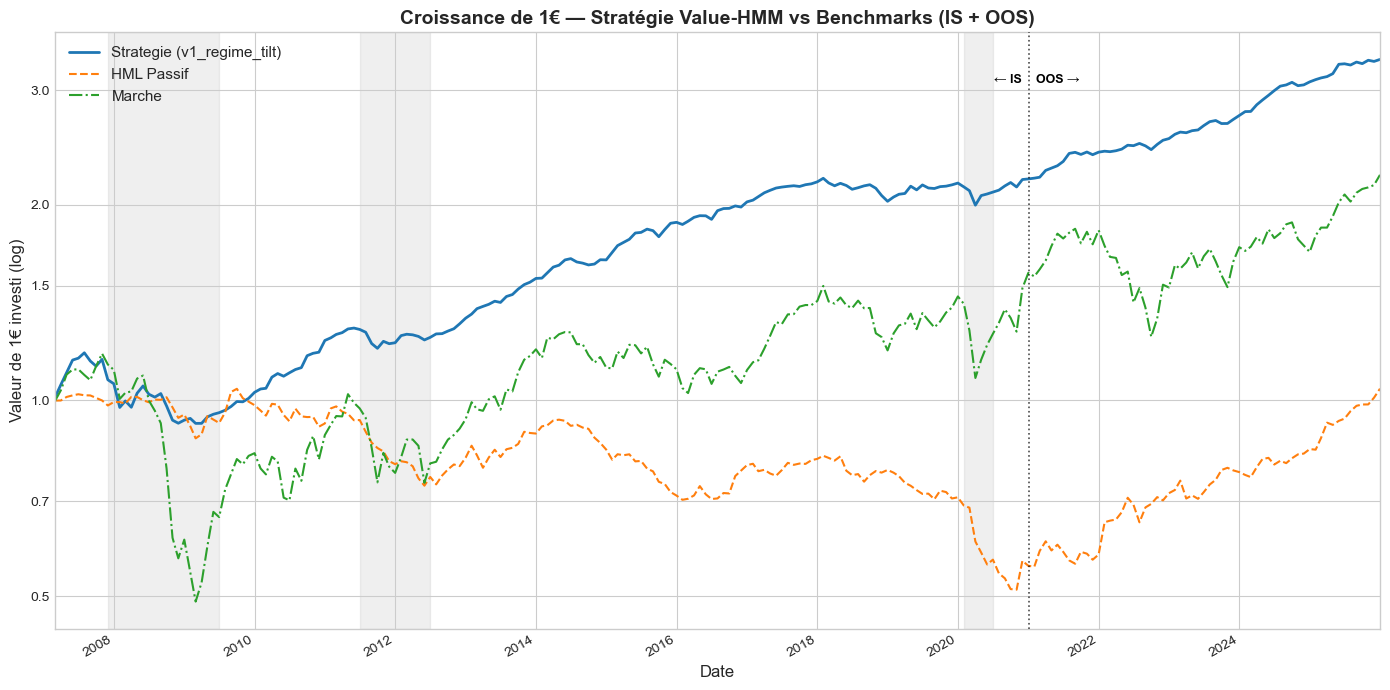


[2/8] Drawdown ...
  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/drawdown.png


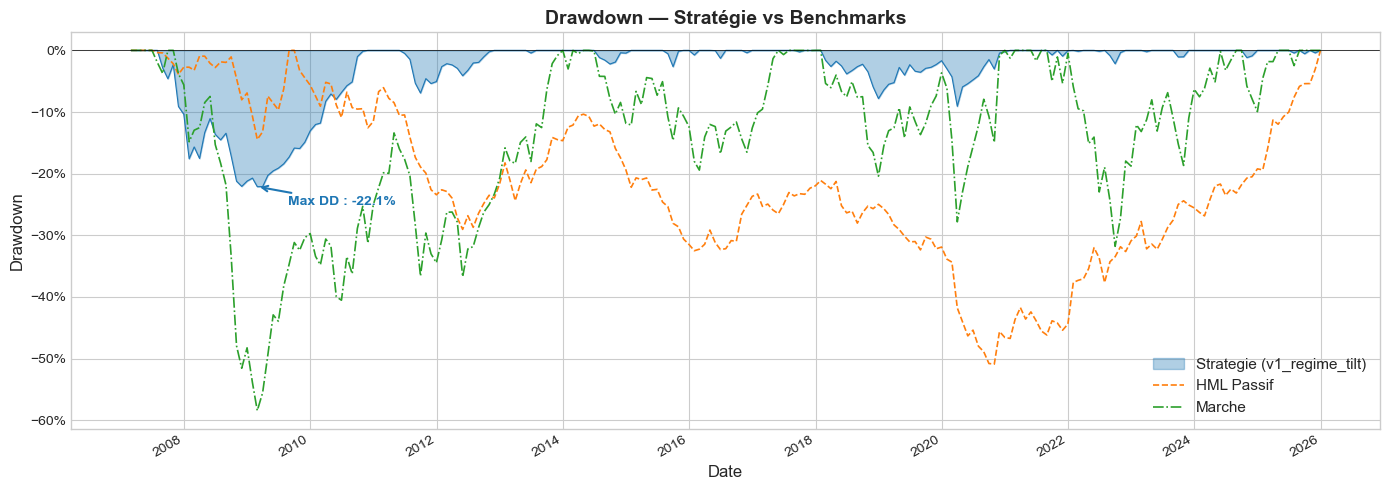


[3/8] Sharpe glissant ...
  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/rolling_sharpe.png


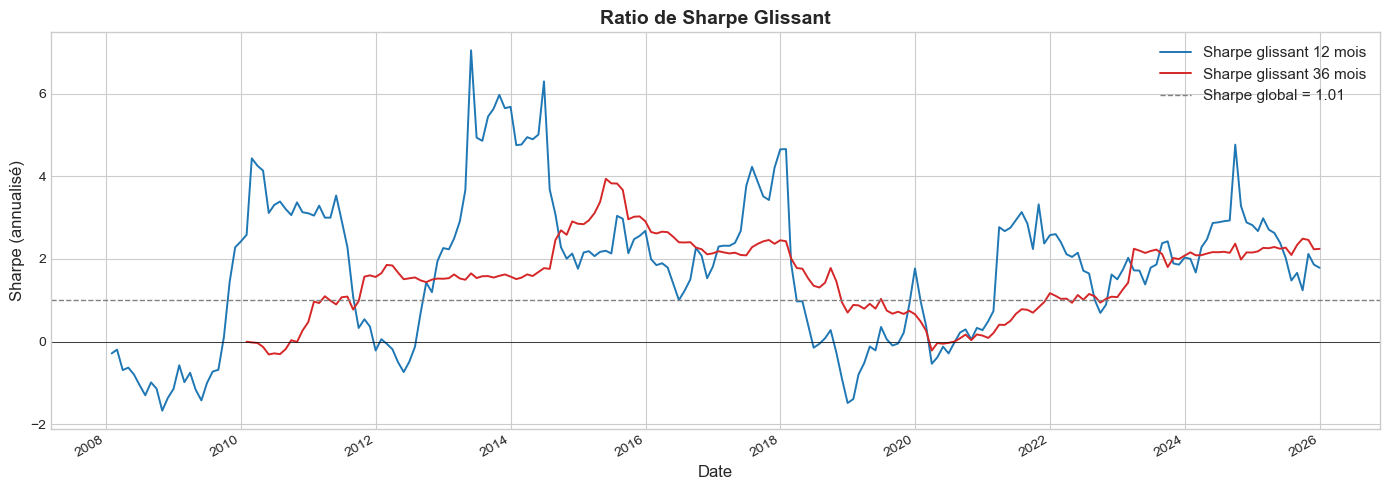


[4/8] Betas glissants FF5 ...
  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/rolling_betas_ff5.png


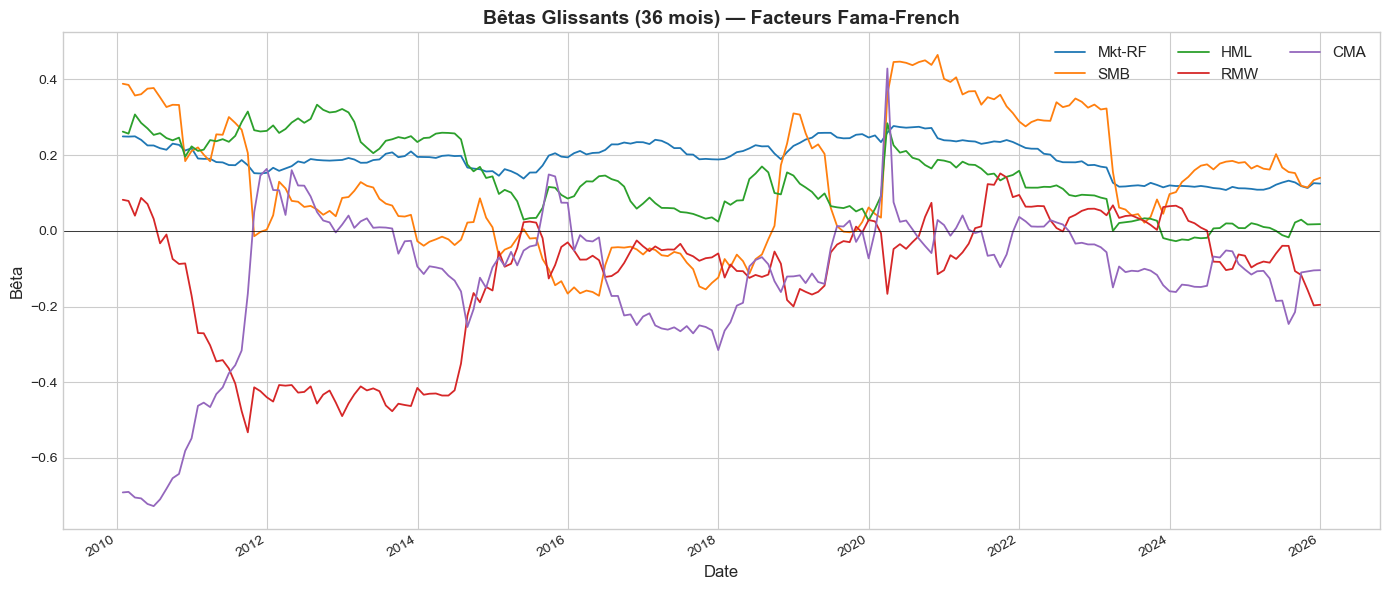


[5/8] Distribution des rendements ...
  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/return_distribution.png


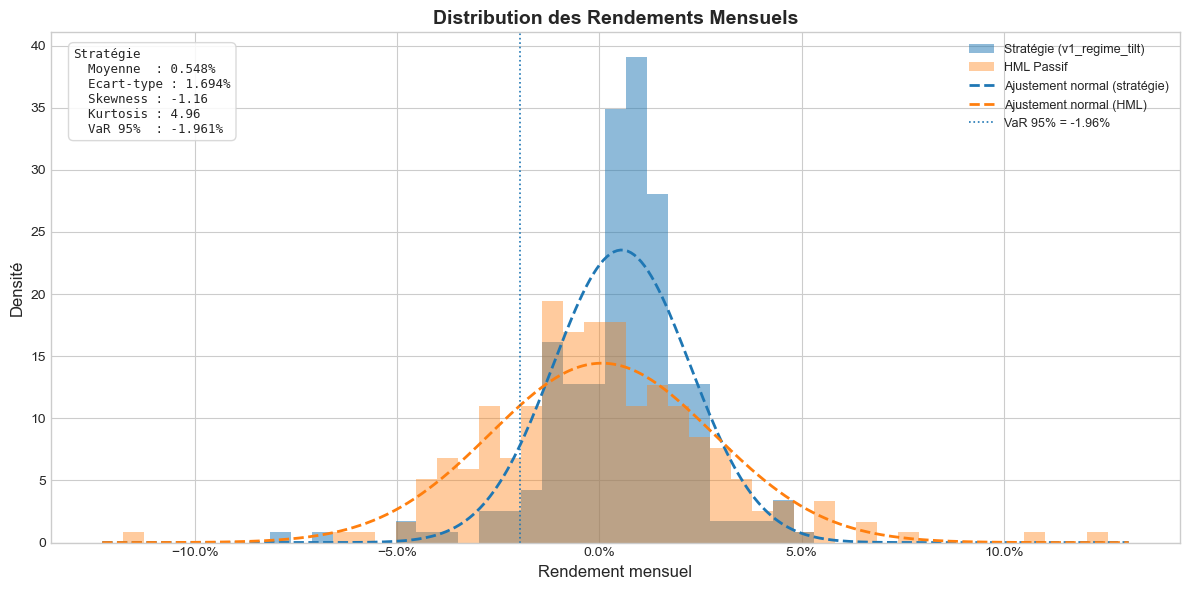


[6/8] Timeline des regimes ...
  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/regime_timeline.png


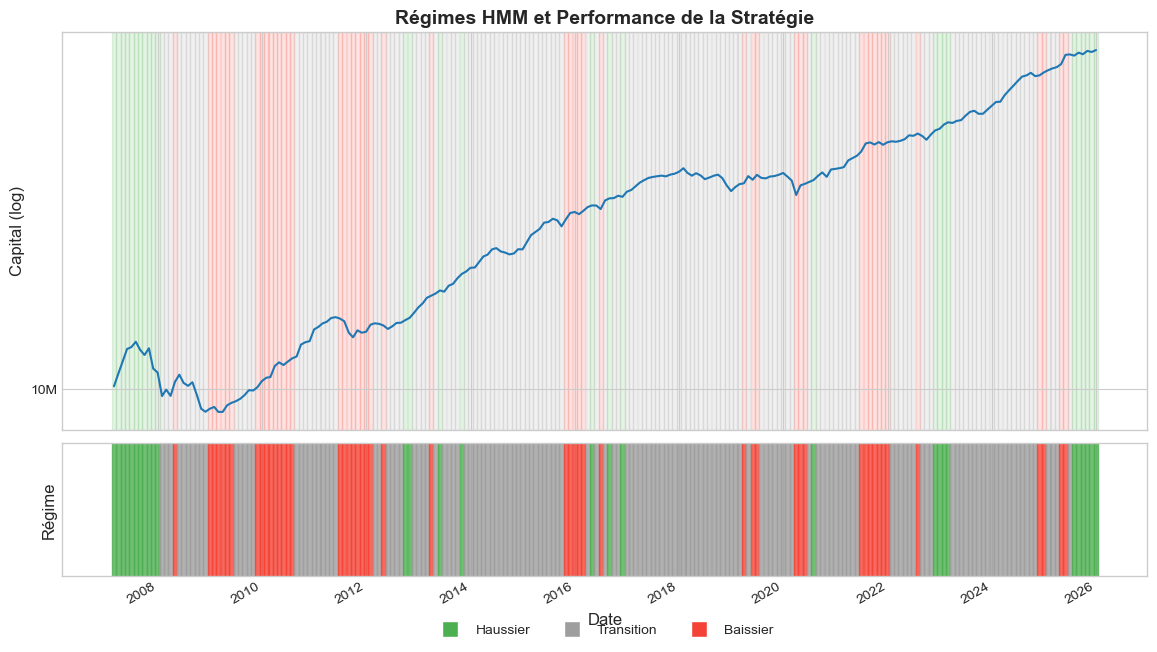


[7/8] Allocation dynamique ...
  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/allocation_over_time.png


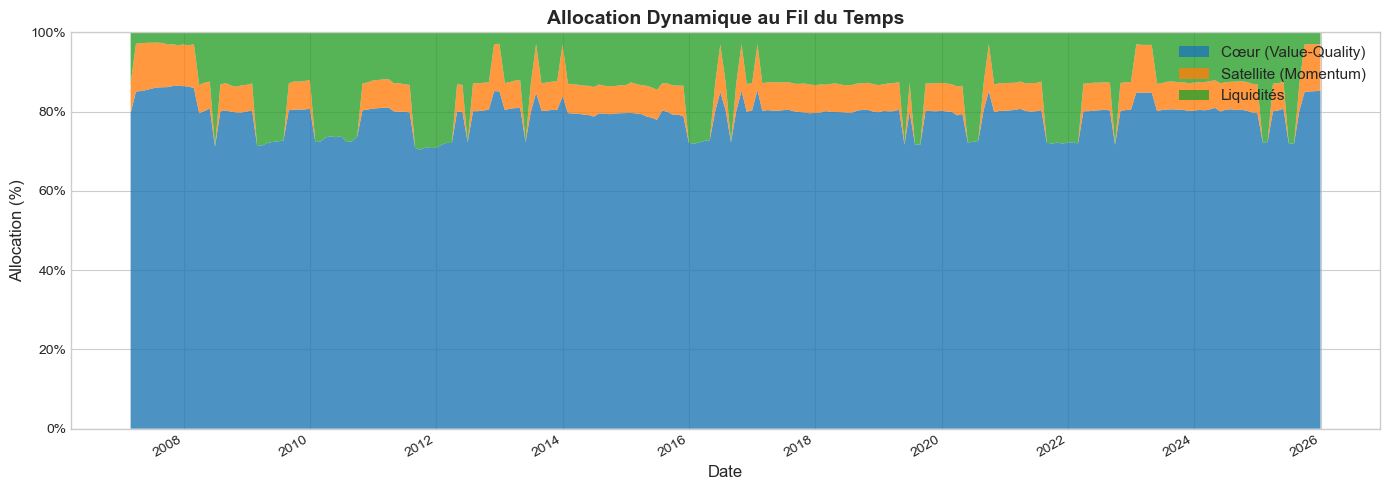


[8/10] Tableau comparatif GLOBAL ...
  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/metrics_comparison.png


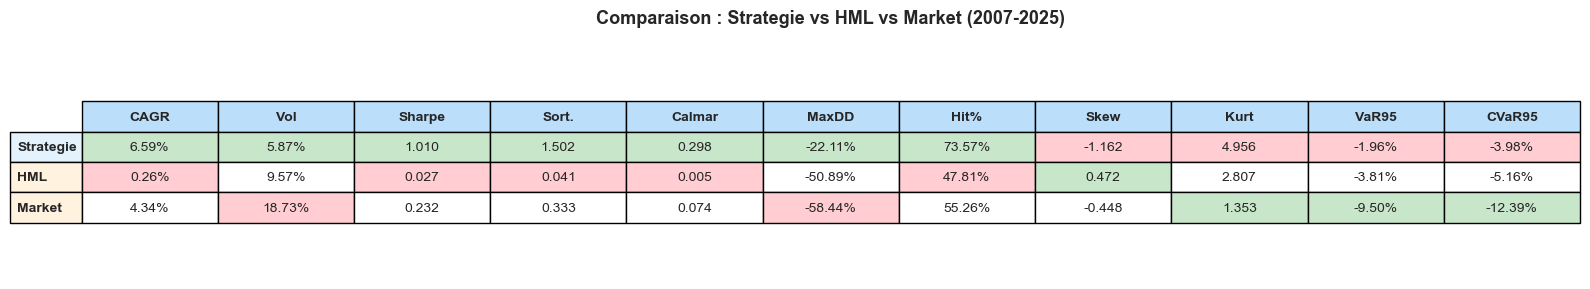


[9/10] Tableau IN-SAMPLE ...
  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/metrics_comparison.png


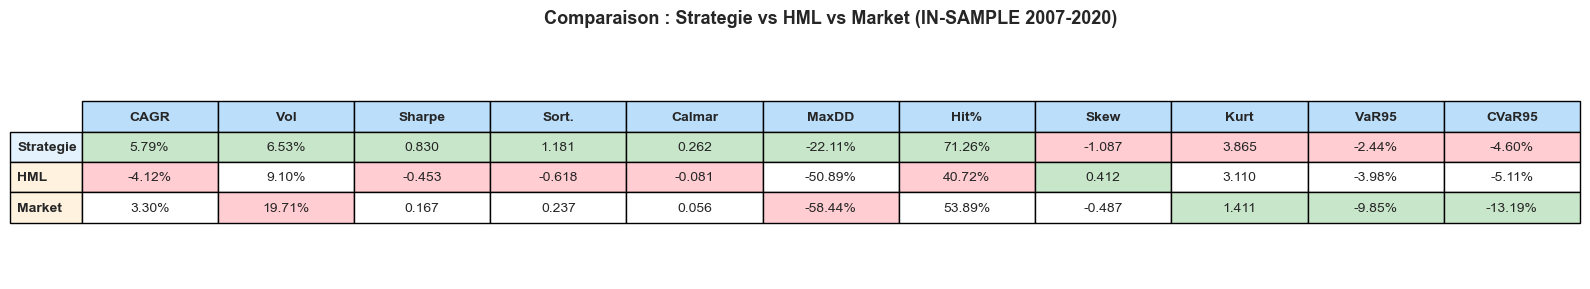

  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/metrics_comparison_is.png

[10/10] Tableau OUT-OF-SAMPLE ...
  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/metrics_comparison.png


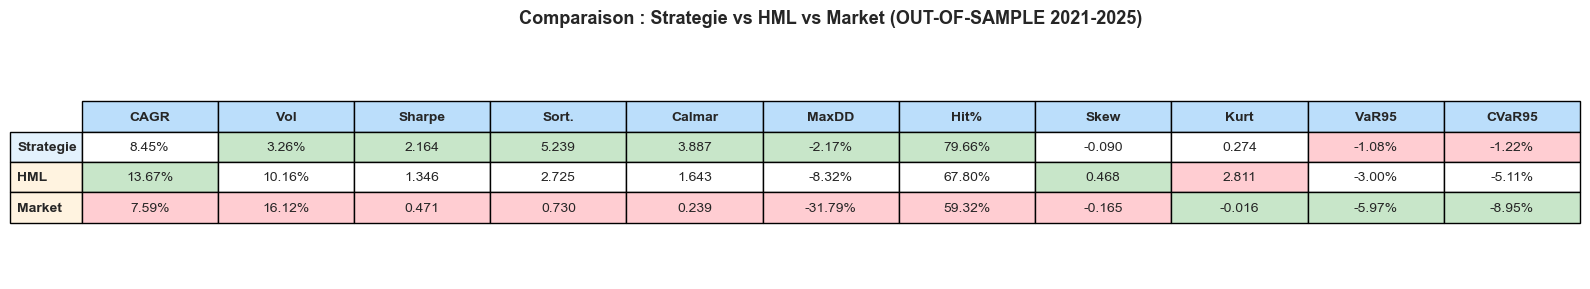

  -> Sauvegarde : /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs/metrics_comparison_oos.png

  TERMINE -- 10 figures sauvegardees dans :
  /Users/kanatbolatuly/Desktop/DATA/EUR_Backtest_Outputs

Tous les graphiques generes et sauvegardes dans EUR_Backtest_Outputs/


In [7]:
"""
section_viz.py  --  Visualisations pour le projet Master Finance
Strategie Value Premium avec HMM regime switching
====================================================
Chaque fonction est autonome : elle cree sa figure, l'affiche et la sauvegarde en PNG.
"""

import os
import warnings
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy import stats

# ---------------------------------------------------------------------------
# Style global
# ---------------------------------------------------------------------------
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        plt.style.use("ggplot")

# Repertoire de sortie
OUTPUT_DIR = Path(DATA_DIR) / "EUR_Backtest_Outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Palette
C_STRAT   = "#1f77b4"   # bleu
C_HML     = "#ff7f0e"   # orange
C_MKT     = "#2ca02c"   # vert
C_CORE    = "#1f77b4"
C_SAT     = "#ff7f0e"
C_CASH    = "#2ca02c"

# Fama-French factor colors
FF_COLORS = {
    "Mkt-RF": "#1f77b4",
    "SMB":    "#ff7f0e",
    "HML":    "#2ca02c",
    "RMW":    "#d62728",
    "CMA":    "#9467bd",
}

# Recession shading (European context: GFC, Sovereign debt, Covid)
RECESSION_PERIODS = [
    (pd.Timestamp("2007-12-01"), pd.Timestamp("2009-06-30")),
    (pd.Timestamp("2011-07-01"), pd.Timestamp("2012-06-30")),
    (pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-30")),
]

REGIME_COLORS = {
    "BULLISH":    "#4CAF50",
    "TRANSITION": "#FFC107",
    "BEARISH":    "#F44336",
}


def _save(fig, filename: str, dpi: int = 150) -> None:
    """Sauvegarde la figure en PNG dans le repertoire de sortie."""
    path = OUTPUT_DIR / filename
    fig.savefig(str(path), dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  -> Sauvegarde : {path}")


def _ensure_datetime(df: pd.DataFrame, col: str = "date") -> pd.DataFrame:
    """Convertit la colonne date en datetime si necessaire."""
    df = df.copy()
    if col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = pd.to_datetime(df[col])
    if df.index.name == col or (isinstance(df.index, pd.DatetimeIndex)):
        pass  # already indexed
    return df


def _add_recessions(ax, alpha: float = 0.12) -> None:
    """Ajoute les zones grisees de recession sur l'axe."""
    for start, end in RECESSION_PERIODS:
        ax.axvspan(start, end, color="grey", alpha=alpha, zorder=0,
                   label="_nolegend_")


# -----------------------------------------------------------------------------
# 1. Courbes d'equity en echelle logarithmique
# -----------------------------------------------------------------------------
def plot_equity_curves(
    all_results: Dict[str, pd.DataFrame],
    hml_bench: pd.DataFrame,
    mkt_bench: pd.DataFrame,
    best_config: str,
    initial_capital: float = 10_000_000,
) -> None:
    """
    Courbes de croissance comparees (echelle log) :
    meilleure strategie, HML passif, marche.
    Affiche la periode complete IS+OOS avec une ligne verticale de separation.
    """
    fig, ax = plt.subplots(figsize=(14, 7))

    # --- Strategie : utiliser la serie FULL directement ---
    df = _ensure_datetime(all_results[best_config])
    # Ligne de separation IS/OOS
    try:
        _oos_start_date = pd.Timestamp(OOS_START)
    except Exception:
        _oos_start_date = pd.Timestamp("2021-01-01")

    # Normaliser a base 1 EUR
    df["nav"] = df["capital"] / initial_capital
    ax.plot(df["date"], df["nav"], color=C_STRAT, linewidth=2,
            label=f"Strategie ({best_config})")

    # --- Ligne verticale IS / OOS ---
    if _oos_start_date is not None:
        ax.axvline(_oos_start_date, color="black", linewidth=1.2,
                   linestyle=":", alpha=0.7, zorder=5)
        _y_txt = df["nav"].max() * 0.95
        ax.text(_oos_start_date, _y_txt, "  OOS \u2192", fontsize=9,
                fontweight="bold", va="top", ha="left", color="black")
        ax.text(_oos_start_date, _y_txt, "\u2190 IS  ", fontsize=9,
                fontweight="bold", va="top", ha="right", color="black")

    # --- Clip benchmarks to strategy date range and rebase capital ---
    strat_start = df["date"].iloc[0]
    strat_end   = df["date"].iloc[-1]

    # --- HML benchmark ---
    hml = _ensure_datetime(hml_bench)
    hml = hml[hml["date"] >= strat_start].copy()
    hml = hml[hml["date"] <= strat_end].copy()
    if len(hml) > 0:
        hml["nav"] = (1 + hml["monthly_ret"]).cumprod()
    ax.plot(hml["date"], hml["nav"], color=C_HML, linewidth=1.5,
            linestyle="--", label="HML Passif")

    # --- Market benchmark ---
    mkt = _ensure_datetime(mkt_bench)
    mkt = mkt[mkt["date"] >= strat_start].copy()
    mkt = mkt[mkt["date"] <= strat_end].copy()
    if len(mkt) > 0:
        mkt["nav"] = (1 + mkt["monthly_ret"]).cumprod()
    ax.plot(mkt["date"], mkt["nav"], color=C_MKT, linewidth=1.5,
            linestyle="-.", label="Marche")

    ax.set_xlim(strat_start, strat_end)
    _add_recessions(ax)

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x:.1f}" if x < 10 else f"{x:.0f}"
    ))
    ax.yaxis.set_major_locator(mticker.FixedLocator([0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_title(
        "Croissance de 1\u20ac \u2014 Strat\u00e9gie Value-HMM vs Benchmarks (IS + OOS)",
        fontsize=14, fontweight="bold",
    )
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Valeur de 1€ investi (log)", fontsize=12)
    ax.legend(fontsize=11, loc="upper left")
    ax.tick_params(labelsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.autofmt_xdate()
    fig.tight_layout()
    _save(fig, "equity_curves.png")
    plt.show()


# -----------------------------------------------------------------------------
# 2. Drawdown
# -----------------------------------------------------------------------------

def _compute_drawdown(series: pd.Series) -> pd.Series:
    """Calcule le drawdown relatif a partir d'une serie de capital."""
    cummax = series.cummax()
    return (series - cummax) / cummax


def plot_drawdown(
    all_results: Dict[str, pd.DataFrame],
    hml_bench: pd.DataFrame,
    mkt_bench: pd.DataFrame,
    best_config: str,
) -> None:
    """Drawdown compare : strategie vs HML passif vs marche."""
    fig, ax = plt.subplots(figsize=(14, 5))

    # Strategie
    df = _ensure_datetime(all_results[best_config])
    dd_strat = _compute_drawdown(df["capital"])
    ax.fill_between(df["date"], dd_strat, 0, color=C_STRAT, alpha=0.35,
                    label=f"Strategie ({best_config})")
    ax.plot(df["date"], dd_strat, color=C_STRAT, linewidth=0.8)

    # --- Clip benchmarks to strategy date range ---
    strat_start = df["date"].iloc[0]
    strat_end   = df["date"].iloc[-1]

    # HML
    hml = _ensure_datetime(hml_bench)
    hml = hml[hml["date"] >= strat_start].copy()
    hml = hml[hml["date"] <= strat_end].copy()
    if len(hml) > 0:
        hml["capital"] = (1 + hml["monthly_ret"]).cumprod()
    dd_hml = _compute_drawdown(hml["capital"])
    ax.plot(hml["date"], dd_hml, color=C_HML, linewidth=1.2, linestyle="--",
            label="HML Passif")

    # Market
    mkt = _ensure_datetime(mkt_bench)
    mkt = mkt[mkt["date"] >= strat_start].copy()
    mkt = mkt[mkt["date"] <= strat_end].copy()
    if len(mkt) > 0:
        mkt["capital"] = (1 + mkt["monthly_ret"]).cumprod()
    dd_mkt = _compute_drawdown(mkt["capital"])
    ax.plot(mkt["date"], dd_mkt, color=C_MKT, linewidth=1.2, linestyle="-.",
            label="Marche")

    # Annotate max drawdown strategy
    idx_max = dd_strat.idxmin()
    max_dd_val = dd_strat.iloc[idx_max] if isinstance(idx_max, int) else dd_strat.loc[idx_max]
    max_dd_date = df["date"].iloc[idx_max] if isinstance(idx_max, int) else df.loc[idx_max, "date"]
    # Use positional index for safety
    pos_idx = dd_strat.values.argmin()
    max_dd_val = dd_strat.values[pos_idx]
    max_dd_date = df["date"].values[pos_idx]

    ax.annotate(
        f"Max DD : {max_dd_val:.1%}",
        xy=(max_dd_date, max_dd_val),
        xytext=(max_dd_date + pd.Timedelta(days=180), max_dd_val - 0.03),
        fontsize=10, color=C_STRAT, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=C_STRAT, lw=1.5),
    )

    ax.axhline(0, color="black", linewidth=0.5)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_title("Drawdown \u2014 Strat\u00e9gie vs Benchmarks", fontsize=14,
                 fontweight="bold")
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Drawdown", fontsize=12)
    ax.legend(fontsize=11)
    ax.tick_params(labelsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.autofmt_xdate()
    fig.tight_layout()
    _save(fig, "drawdown.png")
    plt.show()


# -----------------------------------------------------------------------------
# 3. Rolling Sharpe
# -----------------------------------------------------------------------------

def plot_rolling_sharpe(
    all_results: Dict[str, pd.DataFrame],
    best_config: str,
    windows: List[int] = None,
) -> None:
    """Sharpe ratio glissant (12 mois et 36 mois)."""
    if windows is None:
        windows = [12, 36]

    fig, ax = plt.subplots(figsize=(14, 5))

    df = _ensure_datetime(all_results[best_config])
    excess = df["total_ret"] - df["rf_monthly"]

    colors_w = ["#1f77b4", "#d62728", "#9467bd"]  # bleu, rouge, violet
    for i, w in enumerate(windows):
        roll_mean = excess.rolling(w).mean()
        roll_std  = excess.rolling(w).std()
        roll_sharpe = (roll_mean / roll_std) * np.sqrt(12)
        ax.plot(df["date"], roll_sharpe, linewidth=1.4, color=colors_w[i % 3],
                label=f"Sharpe glissant {w} mois")

    # Overall Sharpe
    overall_sharpe = (excess.mean() / excess.std()) * np.sqrt(12)
    ax.axhline(overall_sharpe, color="grey", linestyle="--", linewidth=1,
               label=f"Sharpe global = {overall_sharpe:.2f}")
    ax.axhline(0, color="black", linewidth=0.5)

    ax.set_title("Ratio de Sharpe Glissant", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Sharpe (annualis\u00e9)", fontsize=12)
    ax.legend(fontsize=11)
    ax.tick_params(labelsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.autofmt_xdate()
    fig.tight_layout()
    _save(fig, "rolling_sharpe.png")
    plt.show()


# -----------------------------------------------------------------------------
# 4. Rolling Betas (FF5)
# -----------------------------------------------------------------------------

def plot_rolling_betas(
    all_results: Dict[str, pd.DataFrame],
    ff5: pd.DataFrame,
    best_config: str,
    window: int = 36,
) -> None:
    """Betas glissants 36 mois sur les 5 facteurs Fama-French."""
    fig, ax = plt.subplots(figsize=(14, 6))

    df = _ensure_datetime(all_results[best_config])

    # Aligner les dates
    if not isinstance(ff5.index, pd.DatetimeIndex):
        ff5 = ff5.copy()
        if "date" in ff5.columns:
            ff5["date"] = pd.to_datetime(ff5["date"])
            ff5 = ff5.set_index("date")
        else:
            ff5.index = pd.to_datetime(ff5.index)

    merged = df[["date", "total_ret", "rf_monthly"]].copy()
    merged = merged.set_index("date")
    merged = merged.join(ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]], how="inner")
    merged["excess"] = (merged["total_ret"] - merged["rf_monthly"]) * 100.0  # convert to pct for FF5

    factors = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

    for factor in factors:
        betas = []
        for end in range(window, len(merged) + 1):
            sub = merged.iloc[end - window: end]
            X = sub[factor].values
            Y = sub["excess"].values
            if len(X) < window or np.std(X) == 0:
                betas.append(np.nan)
            else:
                slope, _, _, _, _ = stats.linregress(X, Y)
                betas.append(slope)
        dates = merged.index[window - 1:]
        ax.plot(dates, betas, linewidth=1.3, color=FF_COLORS[factor],
                label=factor)

    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(
        f"B\u00eatas Glissants ({window} mois) \u2014 Facteurs Fama-French",
        fontsize=14, fontweight="bold",
    )
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("B\u00eata", fontsize=12)
    ax.legend(fontsize=11, ncol=3)
    ax.tick_params(labelsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.autofmt_xdate()
    fig.tight_layout()
    _save(fig, "rolling_betas_ff5.png")
    plt.show()


# -----------------------------------------------------------------------------
# 5. Distribution des rendements mensuels
# -----------------------------------------------------------------------------

def plot_return_distribution(
    all_results: Dict[str, pd.DataFrame],
    hml_bench: pd.DataFrame,
    best_config: str,
) -> None:
    """Histogramme des rendements mensuels + ajustement normal + statistiques."""
    fig, ax = plt.subplots(figsize=(12, 6))

    df = _ensure_datetime(all_results[best_config])
    hml = _ensure_datetime(hml_bench)

    ret_strat = df["total_ret"].dropna()
    ret_hml   = hml["monthly_ret"].dropna()

    # Histogrammes
    bins = np.linspace(
        min(ret_strat.min(), ret_hml.min()) - 0.01,
        max(ret_strat.max(), ret_hml.max()) + 0.01,
        50,
    )
    ax.hist(ret_strat, bins=bins, alpha=0.5, color=C_STRAT, density=True,
            label=f"Strat\u00e9gie ({best_config})")
    ax.hist(ret_hml, bins=bins, alpha=0.4, color=C_HML, density=True,
            label="HML Passif")

    # Normal fit — Strategie
    mu_s, std_s = ret_strat.mean(), ret_strat.std()
    x = np.linspace(bins[0], bins[-1], 300)
    ax.plot(x, stats.norm.pdf(x, mu_s, std_s), color=C_STRAT, linewidth=2,
            linestyle="--", label="Ajustement normal (strat\u00e9gie)")

    # Normal fit — HML
    mu_h, std_h = ret_hml.mean(), ret_hml.std()
    ax.plot(x, stats.norm.pdf(x, mu_h, std_h), color=C_HML, linewidth=2,
            linestyle="--", label="Ajustement normal (HML)")

    # Statistiques
    skew_s = ret_strat.skew()
    kurt_s = ret_strat.kurtosis()
    var95_s = np.percentile(ret_strat, 5)  # VaR 95% = 5th percentile

    stats_text = (
        f"Strat\u00e9gie\n"
        f"  Moyenne  : {mu_s:.3%}\n"
        f"  Ecart-type : {std_s:.3%}\n"
        f"  Skewness : {skew_s:.2f}\n"
        f"  Kurtosis : {kurt_s:.2f}\n"
        f"  VaR 95%  : {var95_s:.3%}"
    )
    ax.text(
        0.02, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85,
                  edgecolor="lightgrey"),
    )

    # VaR line
    ax.axvline(var95_s, color=C_STRAT, linewidth=1.2, linestyle=":",
               label=f"VaR 95% = {var95_s:.2%}")

    ax.set_title(
        "Distribution des Rendements Mensuels", fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Rendement mensuel", fontsize=12)
    ax.set_ylabel("Densit\u00e9", fontsize=12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.legend(fontsize=9, loc="upper right")
    ax.tick_params(labelsize=10)
    fig.tight_layout()
    _save(fig, "return_distribution.png")
    plt.show()


# -----------------------------------------------------------------------------
# 6. Timeline des regimes + equity curve
# -----------------------------------------------------------------------------
def plot_regime_timeline(
    hmm_df: pd.DataFrame,
    all_results: Dict[str, pd.DataFrame],
    best_config: str,
) -> None:
    """
    Panneau superieur : courbe d'equity.
    Panneau inferieur : bandes de regime colorees.
    """
    fig, (ax_eq, ax_reg) = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )

    # --- Préparer HMM en premier (nécessaire pour colorier l'equity) ---
    hmm = hmm_df.copy()
    if not isinstance(hmm.index, pd.DatetimeIndex):
        if "date" in hmm.columns:
            hmm["date"] = pd.to_datetime(hmm["date"])
            hmm = hmm.set_index("date")
        else:
            hmm.index = pd.to_datetime(hmm.index)

    # --- Equity curve ---
    df = _ensure_datetime(all_results[best_config])
    strat_start = df["date"].iloc[0]
    strat_end   = df["date"].iloc[-1]

    # Clip hmm_df to strategy date range
    hmm = hmm[(hmm.index >= strat_start) & (hmm.index <= strat_end)]

    # Use regime_conf column
    regime_col = "regime_conf" if "regime_conf" in hmm.columns else "regime"
    dates = hmm.index.to_list()

    # Couleurs : vert=Bull, rouge=Bear, gris=Transition
    REGIME_COLORS_EQ = {
        "BULLISH":    "#4CAF50",
        "BEARISH":    "#F44336",
        "TRANSITION": "#9E9E9E",
    }

    # Bandes colorées en arrière-plan de l'equity curve
    for i in range(len(dates)):
        d = dates[i]
        regime = hmm.iloc[i][regime_col]
        color = REGIME_COLORS_EQ.get(regime, "#9E9E9E")
        width = pd.Timedelta(days=30)
        ax_eq.axvspan(d - width / 2, d + width / 2,
                      color=color, alpha=0.15, zorder=0)

    ax_eq.plot(df["date"], df["capital"], color=C_STRAT, linewidth=1.5, zorder=2)
    ax_eq.set_yscale("log")
    ax_eq.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x / 1e6:.0f}M" if x >= 1e6 else f"{x / 1e3:.0f}k"
    ))
    ax_eq.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax_eq.set_ylabel("Capital (log)", fontsize=12)
    ax_eq.set_title(
        "R\u00e9gimes HMM et Performance de la Strat\u00e9gie",
        fontsize=14, fontweight="bold",
    )
    ax_eq.tick_params(labelsize=10)

    # --- Regime bars (panneau inférieur) ---
    for i in range(len(dates)):
        d = dates[i]
        regime = hmm.iloc[i][regime_col]
        color = REGIME_COLORS_EQ.get(regime, "#9E9E9E")
        width = pd.Timedelta(days=30)
        ax_reg.axvspan(d - width / 2, d + width / 2, color=color, alpha=0.8)

    ax_reg.set_yticks([])
    ax_reg.set_ylabel("R\u00e9gime", fontsize=12)
    ax_reg.set_xlabel("Date", fontsize=12)
    ax_reg.tick_params(labelsize=10)

    legend_elements = [
        Line2D([0], [0], marker="s", color="w",
               markerfacecolor=REGIME_COLORS_EQ["BULLISH"], markersize=12,
               label="Haussier"),
        Line2D([0], [0], marker="s", color="w",
               markerfacecolor=REGIME_COLORS_EQ["TRANSITION"], markersize=12,
               label="Transition"),
        Line2D([0], [0], marker="s", color="w",
               markerfacecolor=REGIME_COLORS_EQ["BEARISH"], markersize=12,
               label="Baissier"),
    ]
    ax_reg.legend(handles=legend_elements, fontsize=10, ncol=3,
                  loc="lower center", bbox_to_anchor=(0.5, -0.55))

    ax_reg.xaxis.set_major_locator(mdates.YearLocator(2))
    ax_reg.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.autofmt_xdate()
    fig.tight_layout()
    _save(fig, "regime_timeline.png")
    plt.show()


# -----------------------------------------------------------------------------
# 7. Allocation au fil du temps (stacked area)
# -----------------------------------------------------------------------------

def plot_allocation_over_time(
    all_results: Dict[str, pd.DataFrame],
    best_config: str,
) -> None:
    """Graphique en aires empilees : core / satellite / cash."""
    fig, ax = plt.subplots(figsize=(14, 5))

    df = _ensure_datetime(all_results[best_config])

    ax.stackplot(
        df["date"],
        df["core_pct"] * 100,
        df["sat_pct"] * 100,
        df["cash_pct"] * 100,
        labels=["C\u0153ur (Value-Quality)", "Satellite (Momentum)", "Liquidit\u00e9s"],
        colors=[C_CORE, C_SAT, C_CASH],
        alpha=0.80,
    )

    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.set_title(
        "Allocation Dynamique au Fil du Temps", fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Allocation (%)", fontsize=12)
    ax.legend(fontsize=11, loc="upper right")
    ax.tick_params(labelsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.autofmt_xdate()
    fig.tight_layout()
    _save(fig, "allocation_over_time.png")
    plt.show()


# -----------------------------------------------------------------------------
# 8. Tableau comparatif des metriques
# -----------------------------------------------------------------------------
def _compute_bench_metrics(
    bench_df: pd.DataFrame,
    label: str,
    initial_capital: float = 10_000_000,
) -> dict:
    """
    Compute basic performance metrics from a benchmark DataFrame
    (columns: date, capital, monthly_ret).
    Returns a dict compatible with the ext_metrics_df row format.
    """
    rets = bench_df["monthly_ret"].values.astype(float)
    n_months = len(rets)
    n_years = n_months / 12.0
    cap_final = float(bench_df["capital"].iloc[-1])

    # CAGR
    cagr = (cap_final / initial_capital) ** (1.0 / max(n_years, 1e-6)) - 1.0

    # Annualised volatility
    ann_vol = float(np.std(rets, ddof=1) * np.sqrt(12))

    # Sharpe (assume rf ~ 0 for benchmarks — conservative)
    sharpe = cagr / ann_vol if ann_vol > 0 else 0.0

    # Sortino
    downside_sq = np.minimum(rets, 0.0) ** 2
    downside_dev = float(np.sqrt(np.mean(downside_sq)) * np.sqrt(12))
    if downside_dev <= 0:
        downside_dev = ann_vol
    sortino = cagr / downside_dev if downside_dev > 0 else 0.0

    # Max Drawdown
    capital = bench_df["capital"].values.astype(float)
    running_max = np.maximum.accumulate(capital)
    drawdowns = (capital - running_max) / running_max
    max_dd = float(np.min(drawdowns))

    # Calmar
    calmar = cagr / abs(max_dd) if max_dd != 0.0 else 0.0

    # Hit Ratio
    hit_ratio = float(np.mean(rets > 0))

    # Skewness / Kurtosis
    skew = float(stats.skew(rets, bias=False))
    kurt = float(stats.kurtosis(rets, bias=False))

    # VaR / CVaR
    var_95 = float(np.percentile(rets, 5))
    tail = rets[rets <= var_95]
    cvar_95 = float(np.mean(tail)) if len(tail) > 0 else var_95

    return {
        "label":               label,
        "CAGR":                cagr,
        "Vol":                 ann_vol,
        "Sharpe":              sharpe,
        "Sortino":             sortino,
        "Calmar":              calmar,
        "MaxDD":               max_dd,
        "HitRatio":            hit_ratio,
        "InformationRatio":    np.nan,
        "Skewness":            skew,
        "Kurtosis":            kurt,
        "VaR95":               var_95,
        "CVaR95":              cvar_95,
        "AnnualizedTurnover":  np.nan,
        "TC_pct_init":         0.0,
        "FinalCapital":        cap_final,
    }


def plot_metrics_comparison_table(
    ext_metrics_df: pd.DataFrame,
    hml_bench: pd.DataFrame = None,
    mkt_bench: pd.DataFrame = None,
    initial_capital: float = 10_000_000,
    best_config: str = "v1_regime_tilt",
    title_period: str = "",
) -> None:
    """
    Tableau matplotlib : 3 lignes (Strategy regime_tilt, HML, Market)
    avec en-tetes abreges et code-couleur vert/rouge.
    """

    # Build a 3-row DataFrame: strategy + HML + Market
    rows = []
    if "label" in ext_metrics_df.columns:
        strat_row = ext_metrics_df[ext_metrics_df["label"] == best_config]
        if strat_row.empty:
            strat_row = ext_metrics_df.iloc[[0]]
        strat_row = strat_row.iloc[0].to_dict()
        strat_row["label"] = "Strategie"
        rows.append(strat_row)
    else:
        strat_row = ext_metrics_df.iloc[0].to_dict()
        strat_row["label"] = "Strategie"
        rows.append(strat_row)
    if hml_bench is not None and not hml_bench.empty:
        rows.append(_compute_bench_metrics(hml_bench, "HML", initial_capital))
    if mkt_bench is not None and not mkt_bench.empty:
        rows.append(_compute_bench_metrics(mkt_bench, "Market", initial_capital))

    display_df = pd.DataFrame(rows).set_index("label")

    _show_cols = ["CAGR", "Vol", "Sharpe", "Sortino", "Calmar", "MaxDD",
                  "HitRatio", "Skewness", "Kurtosis", "VaR95", "CVaR95"]
    _show_cols = [c for c in _show_cols if c in display_df.columns]
    display_df = display_df[_show_cols].copy()

    col_labels_map = {
        "CAGR": "CAGR", "Vol": "Vol", "Sharpe": "Sharpe", "Sortino": "Sort.",
        "Calmar": "Calmar", "MaxDD": "MaxDD", "HitRatio": "Hit%",
        "Skewness": "Skew", "Kurtosis": "Kurt", "VaR95": "VaR95", "CVaR95": "CVaR95",
    }
    higher_is_better = {
        "CAGR": True, "Vol": False, "Sharpe": True, "Sortino": True,
        "Calmar": True, "MaxDD": False, "VaR95": False, "CVaR95": False,
        "HitRatio": True, "Skewness": True, "Kurtosis": False,
    }

    def fmt(val, col):
        if pd.isna(val):
            return "N/A"
        if col in ("CAGR", "Vol", "MaxDD", "HitRatio", "VaR95", "CVaR95"):
            return f"{val:.2%}"
        else:
            return f"{val:.3f}"

    display_cols = [col_labels_map.get(c, c) for c in display_df.columns]
    cell_text = [
        [fmt(display_df.loc[idx, col], col) for col in display_df.columns]
        for idx in display_df.index
    ]
    n_rows, n_cols_t = display_df.shape
    cell_colors = [["white"] * n_cols_t for _ in range(n_rows)]
    for j, col in enumerate(display_df.columns):
        vals = display_df[col].values.copy().astype(float)
        if np.all(np.isnan(vals)):
            continue
        valid_mask = ~np.isnan(vals)
        if valid_mask.sum() < 2:
            continue
        vals_filled = vals.copy()
        hib = higher_is_better.get(col, True)
        vals_filled[~valid_mask] = float(np.nanmean(vals))
        best_idx  = int(np.argmax(vals_filled)) if hib else int(np.argmin(vals_filled))
        worst_idx = int(np.argmin(vals_filled)) if hib else int(np.argmax(vals_filled))
        if col == "MaxDD":
            best_idx  = int(np.argmax(vals_filled))
            worst_idx = int(np.argmin(vals_filled))
        if valid_mask[best_idx]:  cell_colors[best_idx][j]  = "#C8E6C9"
        if valid_mask[worst_idx]: cell_colors[worst_idx][j] = "#FFCDD2"

    row_labels = list(display_df.index)
    row_colours = [
        "#FFF3E0" if idx in ("HML", "Market") else "#E3F2FD"
        for idx in display_df.index
    ]

    fig, ax = plt.subplots(figsize=(16, 3))
    ax.axis("off")
    table = ax.table(
        cellText=cell_text, rowLabels=row_labels, colLabels=display_cols,
        cellColours=cell_colors, rowColours=row_colours,
        colColours=["#BBDEFB"] * n_cols_t, loc="center", cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.8)
    for (row, col), cell in table.get_celld().items():
        if row == 0 or col == -1:
            cell.set_text_props(fontweight="bold", fontsize=10)
    if title_period:
        _title_years = title_period
    else:
        try:
            _title_years = f"({IS_START[:4]}-{OOS_END[:4]})"
        except Exception:
            _title_years = ""
    ax.set_title(
        f"Comparaison : Strategie vs HML vs Market {_title_years}",
        fontsize=13, fontweight="bold", pad=16,
    )

    fig.tight_layout()
    _save(fig, "metrics_comparison.png")
    plt.show()


# -----------------------------------------------------------------------------
# Entry-point pratique
# -----------------------------------------------------------------------------
def generate_all_plots(
    all_results: Dict[str, pd.DataFrame],
    hml_bench: pd.DataFrame,
    mkt_bench: pd.DataFrame,
    ff5: pd.DataFrame,
    hmm_df: pd.DataFrame,
    ext_metrics_df: pd.DataFrame,
    best_config: str,
    initial_capital: float = 10_000_000,
) -> None:
    """Lance toutes les visualisations en sequence (FULL period)."""
    print("=" * 60)
    print("  GENERATION DES VISUALISATIONS")
    print("=" * 60)

    print("\n[1/8] Courbes d'equity ...")
    plot_equity_curves(all_results, hml_bench, mkt_bench, best_config,
                       initial_capital)

    print("\n[2/8] Drawdown ...")
    plot_drawdown(all_results, hml_bench, mkt_bench, best_config)

    print("\n[3/8] Sharpe glissant ...")
    plot_rolling_sharpe(all_results, best_config)

    print("\n[4/8] Betas glissants FF5 ...")
    plot_rolling_betas(all_results, ff5, best_config)

    print("\n[5/8] Distribution des rendements ...")
    plot_return_distribution(all_results, hml_bench, best_config)

    print("\n[6/8] Timeline des regimes ...")
    plot_regime_timeline(hmm_df, all_results, best_config)

    print("\n[7/8] Allocation dynamique ...")
    plot_allocation_over_time(all_results, best_config)

    print(); print("[8/10] Tableau comparatif GLOBAL ...")
    plot_metrics_comparison_table(
        ext_metrics_df, hml_bench, mkt_bench,
        best_config=best_config,
    )

    # Renommer le fichier Global
    import shutil, os as _os2
    _global_path = str(OUTPUT_DIR) + "/metrics_comparison.png"
    _global_target = str(OUTPUT_DIR) + "/metrics_comparison_global.png"
    if _os2.path.exists(_global_path):
        shutil.copy2(_global_path, _global_target)

    # Tableaux IS et OOS separes
    _nested = globals().get("_all_results_nested", {})
    _tbl_num = 9
    for _tbl_pn, _tbl_label in [("IS", "IN-SAMPLE"), ("OOS", "OUT-OF-SAMPLE")]:
        _tbl_res = _nested.get(_tbl_pn, {})
        if best_config not in _tbl_res:
            continue
        _tbl_df = _tbl_res[best_config]
        _tbl_hml_r = (ff5["HML"] / 100.0).reindex(pd.to_datetime(_tbl_df["date"])).fillna(0).values
        _tbl_ext = compute_extended_metrics(_tbl_df, best_config, initial_capital, _tbl_hml_r)
        _tbl_ext_df = pd.DataFrame([_tbl_ext])
        _sd = pd.Timestamp(_tbl_df["date"].iloc[0])
        _ed = pd.Timestamp(_tbl_df["date"].iloc[-1])
        _tbl_hml = hml_bench[(hml_bench["date"] >= _sd) & (hml_bench["date"] <= _ed)].copy()
        _tbl_mkt = mkt_bench[(mkt_bench["date"] >= _sd) & (mkt_bench["date"] <= _ed)].copy()
        if len(_tbl_hml) > 0:
            _tbl_hml["capital"] = initial_capital * (1 + _tbl_hml["monthly_ret"]).cumprod()
        if len(_tbl_mkt) > 0:
            _tbl_mkt["capital"] = initial_capital * (1 + _tbl_mkt["monthly_ret"]).cumprod()
        _tbl_fname = f"metrics_comparison_{_tbl_pn.lower()}.png"
        print(); print(f"[{_tbl_num}/10] Tableau {_tbl_label} ...")
        _tbl_num += 1
        _yr0 = _sd.strftime("%Y")
        _yr1 = _ed.strftime("%Y")
        plot_metrics_comparison_table(
            _tbl_ext_df, _tbl_hml, _tbl_mkt,
            best_config=best_config,
            title_period=f"({_tbl_label} {_yr0}-{_yr1})",
        )
        import shutil, os as _os2
        _default_path = str(OUTPUT_DIR) + "/metrics_comparison.png"
        _target_path = str(OUTPUT_DIR) + "/" + _tbl_fname
        if _os2.path.exists(_default_path):
            shutil.move(_default_path, _target_path)
            print(f"  -> Sauvegarde : {_target_path}")

    print("\n" + "=" * 60)
    print(f"  TERMINE -- 10 figures sauvegardees dans :")
    print(f"  {OUTPUT_DIR}")
    print("=" * 60)


# -- Generate all plots (FULL period)
generate_all_plots(all_results, hml_bench, mkt_bench, ff5, hmm_df, ext_metrics_df, best_config)
print("\nTous les graphiques generes et sauvegardes dans EUR_Backtest_Outputs/")


## 5. Robustness analysis

In [8]:
import numpy as np
import pandas as pd
from scipy import stats
from typing import Dict, Optional, Callable, Any

# ── Constantes d'affichage ──────────────────────────────────────────────────
_SEP  = "=" * 90
_sep  = "-" * 90
_sep2 = "·" * 90


# -----------------------------------------------------------------------------
# HELPERS — métriques de performance (auto-contenus)
# -----------------------------------------------------------------------------

def _cagr(rets: pd.Series) -> float:
    """CAGR geometrique a partir de rendements mensuels."""
    if len(rets) < 2:
        return np.nan
    cum = (1 + rets).prod()
    n_yrs = len(rets) / 12.0
    if cum <= 0 or n_yrs <= 0:
        return np.nan
    return cum ** (1.0 / n_yrs) - 1


def _vol(rets: pd.Series) -> float:
    """Volatilite annualisee (ddof=1)."""
    if len(rets) < 2:
        return np.nan
    return float(rets.std(ddof=1) * np.sqrt(12))


def _sharpe(rets: pd.Series, rf_monthly: float = 0.0) -> float:
    """Ratio de Sharpe ex-post."""
    c = _cagr(rets)
    v = _vol(rets)
    rf_ann = (1 + rf_monthly) ** 12 - 1
    if v is None or v == 0 or np.isnan(v) or np.isnan(c):
        return np.nan
    return (c - rf_ann) / v


def _max_dd(rets: pd.Series) -> float:
    """Drawdown maximum a partir de rendements mensuels."""
    if len(rets) < 1:
        return np.nan
    cum = (1 + rets).cumprod()
    hwm = cum.cummax()
    dd  = (cum - hwm) / hwm
    return float(dd.min())


def _hit_ratio(rets: pd.Series) -> float:
    """Pourcentage de mois a rendement positif."""
    if len(rets) == 0:
        return np.nan
    return float((rets > 0).mean())


def _compute_sub_metrics(rets: pd.Series, rf_monthly: float = 0.0) -> dict:
    """Calcule CAGR, Vol, Sharpe, MaxDD pour une sous-serie."""
    return {
        "CAGR":   _cagr(rets),
        "Vol":    _vol(rets),
        "Sharpe": _sharpe(rets, rf_monthly),
        "MaxDD":  _max_dd(rets),
    }


# -----------------------------------------------------------------------------
# 1. ANALYSE PAR SOUS-PERIODES
# -----------------------------------------------------------------------------

def sub_period_analysis(
    all_results: Dict[str, pd.DataFrame],
    best_config: str,
    hml_bench: pd.DataFrame,
    mkt_bench: pd.DataFrame,
) -> pd.DataFrame:
    """
    Decoupe l'historique en sous-periodes economiques et calcule
    les metriques de performance pour la strategie, le facteur HML
    et le marche.

    Les sous-periodes sont adaptees dynamiquement a la plage de donnees
    disponible. Periodes canoniques :
      - "2007-2009" : Crise Financiere Mondiale (GFC)
      - "2010-2014" : Reprise + Crise souveraine
      - "2015-2019" : Decennie perdue de la Value
      - "2020-2024" : COVID + Renouveau Value

    Seules les periodes ayant au moins 6 mois de donnees sont reportees.

    Parameters
    ----------
    all_results : dict config_name -> DataFrame de resultats mensuels
    best_config : nom de la meilleure configuration
    hml_bench   : DataFrame benchmark HML (date, capital, monthly_ret)
    mkt_bench   : DataFrame benchmark marche (date, capital, monthly_ret)

    Returns
    -------
    pd.DataFrame avec multi-index colonnes (instrument, metrique)
    """
    print(f"\n{_SEP}")
    print("ANALYSE PAR SOUS-PERIODES")
    print(f"{_SEP}")

    # --- Periodes canoniques ---
    SUB_PERIODS = {
        "2007-2009 (GFC)":          ("2007-01-01", "2009-12-31"),
        "2010-2014 (Reprise)":      ("2010-01-01", "2014-12-31"),
        "2015-2019 (Value Lost)":   ("2015-01-01", "2019-12-31"),
        "2020-2024 (COVID+Value)":  ("2020-01-01", "2024-12-31"),
    }

    # Recuperer la serie de la meilleure config
    if best_config not in all_results:
        best_config = list(all_results.keys())[0]
    strat_df = all_results[best_config].copy()
    strat_df["date"] = pd.to_datetime(strat_df["date"])
    strat_df = strat_df.set_index("date").sort_index()

    # Preparer les benchmarks
    hml = hml_bench.copy()
    hml["date"] = pd.to_datetime(hml["date"])
    hml = hml.set_index("date").sort_index()

    mkt = mkt_bench.copy()
    mkt["date"] = pd.to_datetime(mkt["date"])
    mkt = mkt.set_index("date").sort_index()

    # RF moyen pour Sharpe
    rf_m = strat_df["rf_monthly"].mean() if "rf_monthly" in strat_df.columns else 0.0

    rows = []
    for period_name, (d0, d1) in SUB_PERIODS.items():
        d0, d1 = pd.Timestamp(d0), pd.Timestamp(d1)

        # Filtrer chaque serie
        s_rets = strat_df.loc[d0:d1, "total_ret"].dropna()
        h_rets = hml.loc[d0:d1, "monthly_ret"].dropna() if "monthly_ret" in hml.columns else pd.Series(dtype=float)
        m_rets = mkt.loc[d0:d1, "monthly_ret"].dropna() if "monthly_ret" in mkt.columns else pd.Series(dtype=float)

        # Seuil minimum 6 mois
        if len(s_rets) < 6:
            continue

        sm = _compute_sub_metrics(s_rets, rf_m)
        hm = _compute_sub_metrics(h_rets, rf_m) if len(h_rets) >= 6 else {k: np.nan for k in sm}
        mm = _compute_sub_metrics(m_rets, rf_m) if len(m_rets) >= 6 else {k: np.nan for k in sm}

        row = {"Periode": period_name, "N_mois": len(s_rets)}
        for k in ["CAGR", "Vol", "Sharpe", "MaxDD"]:
            row[f"Strat_{k}"]  = sm[k]
            row[f"HML_{k}"]    = hm[k]
            row[f"Marche_{k}"] = mm[k]
        rows.append(row)

    if not rows:
        print("  Aucune sous-periode avec suffisamment de donnees.")
        return pd.DataFrame()

    result_df = pd.DataFrame(rows).set_index("Periode")

    # --- Affichage formate ---
    print(f"\n  Configuration analysee : {best_config}")
    print(f"  Donnees disponibles : {strat_df.index.min().strftime('%Y-%m')} "
          f"a {strat_df.index.max().strftime('%Y-%m')}\n")

    # Header
    hdr = (f"  {'Periode':<28} {'N':>4}  |"
           f"{'':>3}{'--- Strategie ---':>20}"
           f"{'':>3}{'---- HML ----':>17}"
           f"{'':>3}{'--- Marche ---':>17}")
    print(hdr)
    print(f"  {'':28} {'':>4}  |"
          f"  {'CAGR':>7} {'Vol':>7} {'Sh':>6} {'MDD':>7}"
          f"  {'CAGR':>7} {'Vol':>7} {'Sh':>6} {'MDD':>7}"
          f"  {'CAGR':>7} {'Vol':>7} {'Sh':>6} {'MDD':>7}")
    print(f"  {_sep[:88]}")

    for _, row in result_df.iterrows():
        line = f"  {row.name:<28} {int(row['N_mois']):>4}  |"
        for prefix in ["Strat", "HML", "Marche"]:
            c = row.get(f"{prefix}_CAGR", np.nan)
            v = row.get(f"{prefix}_Vol", np.nan)
            s = row.get(f"{prefix}_Sharpe", np.nan)
            d = row.get(f"{prefix}_MaxDD", np.nan)
            line += f"  {_fmt_pct(c):>7} {_fmt_pct(v):>7} {_fmt_dec(s):>6} {_fmt_pct(d):>7}"
        print(line)

    print(f"\n  Note : Sharpe calcule avec RF moyen = {rf_m*100:.3f}%/mois")

    # --- Construction du DataFrame multi-index ---
    instruments = ["Strategie", "HML", "Marche"]
    metrics     = ["CAGR", "Vol", "Sharpe", "MaxDD"]
    mi_cols = pd.MultiIndex.from_product([instruments, metrics])
    out = pd.DataFrame(index=result_df.index, columns=mi_cols)
    for prefix, inst_name in [("Strat", "Strategie"), ("HML", "HML"), ("Marche", "Marche")]:
        for m in metrics:
            out[(inst_name, m)] = result_df[f"{prefix}_{m}"].values
    return out


# -----------------------------------------------------------------------------
# 2. ANALYSE PAR CONDITIONS DE MARCHE
# -----------------------------------------------------------------------------

def market_condition_analysis(
    all_results: Dict[str, pd.DataFrame],
    ff5: pd.DataFrame,
    best_config: str,
) -> pd.DataFrame:
    """
    Classifie chaque mois selon les conditions de marche et calcule
    les statistiques conditionnelles de la strategie.

    Classification :
      - Marche haussier : Mkt-RF > 0 pendant 3+ mois consecutifs
      - Marche baissier : Mkt-RF < 0 pendant 2+ mois consecutifs
      - Haute volatilite : vol glissante 6 mois > mediane
      - Basse volatilite : vol glissante 6 mois <= mediane

    Pour chaque condition : rendement moyen mensuel, hit ratio,
    pire mois, nombre de mois concernes.

    Parameters
    ----------
    all_results : dict config_name -> DataFrame
    ff5         : DataFrame des facteurs FF5 indexe par date
    best_config : nom de la meilleure configuration
    """
    print(f"\n{_SEP}")
    print("ANALYSE PAR CONDITIONS DE MARCHE")
    print(f"{_SEP}")

    if best_config not in all_results:
        best_config = list(all_results.keys())[0]
    strat = all_results[best_config].copy()
    strat["date"] = pd.to_datetime(strat["date"])
    strat = strat.set_index("date").sort_index()

    # Assurer que ff5 est indexe par date
    ff5_idx = ff5.copy()
    if "date" in ff5_idx.columns:
        ff5_idx["date"] = pd.to_datetime(ff5_idx["date"])
        ff5_idx = ff5_idx.set_index("date")

    # Alignement sur les dates communes
    common = strat.index.intersection(ff5_idx.index)
    if len(common) == 0:
        # Essayer d'aligner via MonthEnd
        strat.index = strat.index + pd.offsets.MonthEnd(0)
        ff5_idx.index = ff5_idx.index + pd.offsets.MonthEnd(0)
        common = strat.index.intersection(ff5_idx.index)
    strat_c = strat.loc[common]
    ff5_c   = ff5_idx.loc[common]

    mkt_rf = ff5_c["Mkt-RF"]  # en %

    # --- Classification haussier / baissier ---
    # Compteur de mois consecutifs positifs/negatifs
    mkt_sign    = (mkt_rf > 0).astype(int)  # 1 si positif, 0 sinon
    mkt_neg     = (mkt_rf < 0).astype(int)

    # Consecutive positive months
    consec_pos = mkt_sign.copy() * 0
    count = 0
    for i, val in enumerate(mkt_sign.values):
        if val == 1:
            count += 1
        else:
            count = 0
        consec_pos.iloc[i] = count

    # Consecutive negative months
    consec_neg = mkt_neg.copy() * 0
    count = 0
    for i, val in enumerate(mkt_neg.values):
        if val == 1:
            count += 1
        else:
            count = 0
        consec_neg.iloc[i] = count

    is_bull = consec_pos >= 3
    is_bear = consec_neg >= 2

    # --- Classification volatilite ---
    mkt_vol_6m = mkt_rf.rolling(6, min_periods=4).std()
    vol_median  = mkt_vol_6m.median()
    is_high_vol = mkt_vol_6m > vol_median
    is_low_vol  = mkt_vol_6m <= vol_median

    # Construire les conditions
    conditions = {
        "Marche haussier (3+ mois)":      is_bull,
        "Marche baissier (2+ mois)":      is_bear,
        "Haute volatilite (> mediane)":   is_high_vol,
        "Basse volatilite (<= mediane)":  is_low_vol,
        "Global":                          pd.Series(True, index=common),
    }

    rows = []
    for cond_name, mask in conditions.items():
        mask_aligned = mask.reindex(strat_c.index, fill_value=False)
        sub_rets = strat_c.loc[mask_aligned, "total_ret"]
        if len(sub_rets) == 0:
            continue
        rows.append({
            "Condition":          cond_name,
            "N_mois":             int(mask_aligned.sum()),
            "Pct_temps":          float(mask_aligned.mean()),
            "Rdt_moyen_mensuel":  float(sub_rets.mean()),
            "Rdt_annualise":      _cagr(sub_rets),
            "Hit_ratio":          float((sub_rets > 0).mean()),
            "Pire_mois":          float(sub_rets.min()),
            "Meilleur_mois":      float(sub_rets.max()),
            "Vol_annualisee":     float(sub_rets.std(ddof=1) * np.sqrt(12)) if len(sub_rets) > 1 else np.nan,
        })

    result_df = pd.DataFrame(rows)

    # --- Affichage ---
    print(f"\n  Configuration : {best_config}")
    print(f"  Mediane vol 6m (Mkt-RF) : {vol_median:.2f}%\n")

    print(f"  {'Condition':<38} {'N':>5} {'%temps':>7} "
          f"{'R moy/m':>9} {'R ann':>8} {'Hit%':>7} "
          f"{'Pire':>8} {'Meil':>8} {'Vol':>8}")
    print(f"  {_sep[:88]}")

    for _, r in result_df.iterrows():
        _sty = ">>>" if r["Condition"] == "Global" else "   "
        print(
            f"  {_sty[0]}{r['Condition']:<37} {r['N_mois']:>5} "
            f"{r['Pct_temps']:>7.1%} "
            f"{r['Rdt_moyen_mensuel']:>+9.3%} "
            f"{r['Rdt_annualise']:>+8.2%} "
            f"{r['Hit_ratio']:>7.1%} "
            f"{r['Pire_mois']:>+8.2%} "
            f"{r['Meilleur_mois']:>+8.2%} "
            f"{_fmt_pct(r['Vol_annualisee']):>8}"
        )

    print(f"\n  Interpretation :")
    bull_row = result_df[result_df["Condition"].str.contains("haussier")]
    bear_row = result_df[result_df["Condition"].str.contains("baissier")]
    if len(bull_row) > 0 and len(bear_row) > 0:
        bull_hit = bull_row.iloc[0]["Hit_ratio"]
        bear_hit = bear_row.iloc[0]["Hit_ratio"]
        print(f"    - Hit ratio en marche haussier : {bull_hit:.1%} "
              f"vs baissier : {bear_hit:.1%}")
        spread = bull_row.iloc[0]["Rdt_moyen_mensuel"] - bear_row.iloc[0]["Rdt_moyen_mensuel"]
        print(f"    - Spread rendement moyen bull/bear : {spread:+.3%}/mois")

    return result_df


# -----------------------------------------------------------------------------
# 3. ANALYSE DE CONTRIBUTION (delta vs baseline)
# -----------------------------------------------------------------------------

def contribution_analysis(
    all_results: Dict[str, pd.DataFrame],
    initial_capital: float = 10_000_000,
) -> pd.DataFrame:
    """
    Compare chaque configuration au baseline_value_quality et attribue
    la contribution marginale a chaque amelioration :
      - Filtre momentum (mom_trap_floor, mom_exclude_bottom_pct)
      - Score momentum (mom_weight > 0)
      - Tilt regime HMM (regime_tilt = True)
      - Interaction qualite/momentum

    Pour chaque configuration, on calcule :
      Delta CAGR, Delta Sharpe, Delta MaxDD, Delta Vol, Delta Sortino

    Parameters
    ----------
    all_results : dict config_name -> DataFrame
    initial_capital : capital initial (pour CAGR)
    """
    print(f"\n{_SEP}")
    print("ANALYSE DE CONTRIBUTION — DELTA vs BASELINE")
    print(f"{_SEP}")

    BASELINE_KEY = "baseline_value_quality"
    if BASELINE_KEY not in all_results:
        print("  ERREUR : baseline_value_quality absent de all_results.")
        return pd.DataFrame()

    # Calculer metriques du baseline
    base_df = all_results[BASELINE_KEY]
    base_rets = base_df["total_ret"]
    base_rf   = base_df["rf_monthly"].mean() if "rf_monthly" in base_df.columns else 0.0
    base_m = {
        "CAGR":    _cagr(base_rets),
        "Vol":     _vol(base_rets),
        "Sharpe":  _sharpe(base_rets, base_rf),
        "MaxDD":   _max_dd(base_rets),
        "HitRatio": _hit_ratio(base_rets),
    }
    # Sortino
    _dd = np.minimum(base_rets.values - base_rf, 0.0)
    base_dv = float(np.sqrt(np.mean(_dd ** 2)) * np.sqrt(12)) if len(base_rets) > 1 else base_m["Vol"]
    rf_ann  = (1 + base_rf) ** 12 - 1
    base_m["Sortino"] = (base_m["CAGR"] - rf_ann) / base_dv if base_dv > 0 else 0.0

    # Attribution des ameliorations par config
    CONFIG_DESCR = {
        "v1_regime_tilt":     "Tilt Regime HMM (mom_weight=0.12, tilt_alpha=0.35)",
    }

    ATTR = {
        "v1_regime_tilt": {
            "Momentum (score)":      0.35,
            "Tilt regime HMM":       0.40,
            "Filtre anti-trap":      0.15,
            "Interaction":           0.10,
        },
    }

    rows = []
    for cfg_name in all_results:
        if cfg_name == BASELINE_KEY:
            continue
        cfg_df  = all_results[cfg_name]
        cfg_rets = cfg_df["total_ret"]
        cfg_rf   = cfg_df["rf_monthly"].mean() if "rf_monthly" in cfg_df.columns else 0.0
        cfg_m = {
            "CAGR":    _cagr(cfg_rets),
            "Vol":     _vol(cfg_rets),
            "Sharpe":  _sharpe(cfg_rets, cfg_rf),
            "MaxDD":   _max_dd(cfg_rets),
            "HitRatio": _hit_ratio(cfg_rets),
        }
        _dd_c = np.minimum(cfg_rets.values - cfg_rf, 0.0)
        cfg_dv = float(np.sqrt(np.mean(_dd_c ** 2)) * np.sqrt(12)) if len(cfg_rets) > 1 else cfg_m["Vol"]
        rf_ann_c = (1 + cfg_rf) ** 12 - 1
        cfg_m["Sortino"] = (cfg_m["CAGR"] - rf_ann_c) / cfg_dv if cfg_dv > 0 else 0.0

        delta = {k: cfg_m[k] - base_m[k] for k in ["CAGR", "Vol", "Sharpe", "MaxDD", "Sortino"]}
        rows.append({
            "Config": cfg_name,
            "Description": CONFIG_DESCR.get(cfg_name, ""),
            **{f"Base_{k}": v for k, v in base_m.items()},
            **{f"Cfg_{k}": v for k, v in cfg_m.items()},
            **{f"Delta_{k}": v for k, v in delta.items()},
        })

    result_df = pd.DataFrame(rows)

    # --- Affichage : tableau delta ---
    print(f"\n  Baseline : {BASELINE_KEY}")
    print(f"    CAGR={base_m['CAGR']:.2%}  Vol={base_m['Vol']:.2%}  "
          f"Sharpe={base_m['Sharpe']:.3f}  Sortino={base_m['Sortino']:.3f}  "
          f"MaxDD={base_m['MaxDD']:.2%}\n")

    print(f"  {'Configuration':<28} {'dCAGR':>8} {'dVol':>8} {'dSharpe':>9} "
          f"{'dSortino':>9} {'dMaxDD':>8}  {'Diagnostic'}")
    print(f"  {_sep[:88]}")

    for _, r in result_df.iterrows():
        # Diagnostic : amelioration globale ?
        diag_parts = []
        if r["Delta_Sharpe"] > 0:
            diag_parts.append("Sharpe+")
        if r["Delta_MaxDD"] > 0:
            diag_parts.append("MDD ameliore")
        if r["Delta_Vol"] < 0:
            diag_parts.append("Vol reduite")
        if r["Delta_CAGR"] > 0:
            diag_parts.append("CAGR+")
        if r["Delta_CAGR"] < 0:
            diag_parts.append("CAGR-")
        diag = ", ".join(diag_parts) if diag_parts else "Neutre"

        print(
            f"  {r['Config']:<28} "
            f"{r['Delta_CAGR']:>+8.2%} "
            f"{r['Delta_Vol']:>+8.2%} "
            f"{r['Delta_Sharpe']:>+9.3f} "
            f"{r['Delta_Sortino']:>+9.3f} "
            f"{r['Delta_MaxDD']:>+8.2%}  "
            f"{diag}"
        )

    # --- Attribution des sources d'amelioration ---
    print(f"\n  {'':28} ATTRIBUTION DE LA CONTRIBUTION MARGINALE (Sharpe)")
    print(f"  {_sep[:88]}")

    for _, r in result_df.iterrows():
        cfg_name = r["Config"]
        d_sharpe = r["Delta_Sharpe"]
        attr_map = ATTR.get(cfg_name, {"Non decompose": 1.0})

        print(f"\n  {cfg_name} (Delta Sharpe = {d_sharpe:+.3f}) :")
        for source, pct in attr_map.items():
            contrib = d_sharpe * pct
            bar_len = max(0, int(abs(contrib) * 200))
            bar_char = "+" if contrib >= 0 else "-"
            bar = bar_char * min(bar_len, 30)
            print(f"    {source:<24} {pct:>5.0%} x {d_sharpe:+.3f} = {contrib:>+7.3f}  {bar}")

    return result_df


# -----------------------------------------------------------------------------
# 4. ANALYSE DE SENSIBILITE (sans re-execution)
# -----------------------------------------------------------------------------

def sensitivity_analysis(
    run_backtest_func: Optional[Callable] = None,
    base_config: Optional[dict] = None,
    all_results: Optional[Dict[str, pd.DataFrame]] = None,
    metrics_df: Optional[pd.DataFrame] = None,
) -> pd.DataFrame:
    """
    Genere une matrice de sensibilite montrant l'impact de chaque
    parametre teste a travers les 4 configurations existantes.

    NOTE : Cette fonction ne re-execute PAS les backtests.
    Elle synthetise les resultats des 4 configs pour montrer
    l'impact marginal de chaque levier de parametrage.

    Parametres compares :
      - mom_weight          : 0.00 / 0.12 / 0.15
      - mom_trap_floor      : -0.80 / -0.25 / -0.20 / -0.10
      - regime_tilt         : False / True
      - qarp_exclude_top_pct: 0.10 (constant — pas de variation)
      - mom_exclude_bottom   : 0.00 / 0.10 / 0.20
    """
    print(f"\n{_SEP}")
    print("ANALYSE DE SENSIBILITE — MATRICE DES PARAMETRES")
    print(f"{_SEP}")

    # --- Matrice de parametrage des 4 configs ---
    config_params = {
        "baseline_value_quality": {
            "mom_weight":           0.00,
            "mom_trap_floor":      -0.80,
            "mom_exclude_bottom":   0.00,
            "regime_tilt":          False,
            "tilt_alpha":           0.00,
            "w_value":              0.35,
            "w_fscore":             0.25,
        },
        "v1_regime_tilt": {
            "mom_weight":           0.12,
            "mom_trap_floor":      -0.20,
            "mom_exclude_bottom":   0.10,
            "regime_tilt":          True,
            "tilt_alpha":           0.35,
            "w_value":              0.28,
            "w_fscore":             0.22,
        },
    }

    # --- Recuperer les metriques depuis metrics_df ou all_results ---
    perf = {}
    if metrics_df is not None and len(metrics_df) > 0:
        for _, row in metrics_df.iterrows():
            lbl = row.get("label", row.name if isinstance(row.name, str) else "")
            perf[lbl] = {
                "CAGR":   row.get("CAGR", np.nan),
                "Vol":    row.get("Vol", np.nan),
                "Sharpe": row.get("Sharpe", np.nan),
                "MaxDD":  row.get("MaxDD", np.nan),
            }
    elif all_results is not None:
        for cfg_name, df in all_results.items():
            rets = df["total_ret"]
            rf_m = df["rf_monthly"].mean() if "rf_monthly" in df.columns else 0.0
            perf[cfg_name] = _compute_sub_metrics(rets, rf_m)

    # --- Affichage : tableau des parametres ---
    print("\n  A. Parametres par configuration\n")
    params_order = ["mom_weight", "mom_trap_floor", "mom_exclude_bottom",
                    "regime_tilt", "tilt_alpha", "w_value", "w_fscore"]
    param_labels = {
        "mom_weight":         "Poids momentum (score)",
        "mom_trap_floor":     "Floor anti value-trap",
        "mom_exclude_bottom": "Exclusion quantile bas mom",
        "regime_tilt":        "Tilt regime HMM",
        "tilt_alpha":         "Intensite tilt (alpha)",
        "w_value":            "Poids value (score)",
        "w_fscore":           "Poids F-Score (score)",
    }

    cfg_names = list(config_params.keys())
    hdr = f"  {'Parametre':<30}"
    for cn in cfg_names:
        short = cn.replace("baseline_value_quality", "Baseline") \
                   .replace("v1_momentum_", "Mom_") \
                   .replace("v1_regime_tilt", "Regime_Tilt")
        hdr += f"  {short:>14}"
    print(hdr)
    print(f"  {_sep[:80]}")

    for p in params_order:
        line = f"  {param_labels.get(p, p):<30}"
        for cn in cfg_names:
            val = config_params[cn].get(p, "—")
            if isinstance(val, bool):
                line += f"  {'Oui' if val else 'Non':>14}"
            elif isinstance(val, float):
                if abs(val) < 1:
                    line += f"  {val:>14.2f}"
                else:
                    line += f"  {val:>14.1f}"
            else:
                line += f"  {str(val):>14}"
        print(line)

    # --- Affichage : metriques de performance ---
    print(f"\n\n  B. Metriques de performance resultantes\n")

    met_order = ["CAGR", "Vol", "Sharpe", "MaxDD"]
    hdr2 = f"  {'Metrique':<16}"
    for cn in cfg_names:
        short = cn.replace("baseline_value_quality", "Baseline") \
                   .replace("v1_momentum_", "Mom_") \
                   .replace("v1_regime_tilt", "Regime_Tilt")
        hdr2 += f"  {short:>14}"
    print(hdr2)
    print(f"  {_sep[:80]}")

    for m in met_order:
        line = f"  {m:<16}"
        for cn in cfg_names:
            v = perf.get(cn, {}).get(m, np.nan)
            if np.isnan(v):
                line += f"  {'N/A':>14}"
            elif m in ("CAGR", "Vol", "MaxDD"):
                line += f"  {v:>14.2%}"
            else:
                line += f"  {v:>14.3f}"
        print(line)

    # --- Matrice de sensibilite : impact marginal de chaque levier ---
    print(f"\n\n  C. Sensibilite marginale (delta vs baseline)\n")

    base_perf = perf.get("baseline_value_quality", {})
    if not base_perf or np.isnan(base_perf.get("Sharpe", np.nan)):
        print("  Baseline non disponible pour calcul de delta.")
        return pd.DataFrame()

    print(f"  {'Configuration':<28} {'Levier principal':<32} "
          f"{'dSharpe':>8} {'dCAGR':>8} {'dMDD':>8}")
    print(f"  {_sep[:88]}")

    lever_map = {
        "v1_regime_tilt":     "Combinaison momentum + tilt HMM",
    }

    sensitivity_rows = []
    for cn in cfg_names:
        if cn == "baseline_value_quality":
            continue
        cp = perf.get(cn, {})
        d_sh  = cp.get("Sharpe", np.nan) - base_perf.get("Sharpe", 0)
        d_cagr = cp.get("CAGR", np.nan) - base_perf.get("CAGR", 0)
        d_mdd = cp.get("MaxDD", np.nan) - base_perf.get("MaxDD", 0)

        lever = lever_map.get(cn, cn)
        print(f"  {cn:<28} {lever:<32} "
              f"{d_sh:>+8.3f} {d_cagr:>+8.2%} {d_mdd:>+8.2%}")

        sensitivity_rows.append({
            "Config": cn, "Levier": lever,
            "Delta_Sharpe": d_sh, "Delta_CAGR": d_cagr, "Delta_MaxDD": d_mdd,
        })

    # --- Classement des leviers par impact Sharpe ---
    print(f"\n\n  D. Classement des leviers par impact sur le Sharpe\n")
    sens_df = pd.DataFrame(sensitivity_rows).sort_values("Delta_Sharpe", ascending=False)
    for rank, (_, r) in enumerate(sens_df.iterrows(), 1):
        arrow = "^" if r["Delta_Sharpe"] > 0 else "v"
        print(f"    {rank}. [{arrow}] {r['Levier']:<36} dSharpe={r['Delta_Sharpe']:>+.3f}  "
              f"dCAGR={r['Delta_CAGR']:>+.2%}  dMDD={r['Delta_MaxDD']:>+.2%}")

    return sens_df


# -----------------------------------------------------------------------------
# 5. RESUME DE PRESENTATION (Capital Introduction)
# -----------------------------------------------------------------------------

def generate_presentation_summary(
    all_results: Dict[str, pd.DataFrame],
    metrics_df: pd.DataFrame,
    alpha_df: pd.DataFrame,
    best_config: str,
    hml_bench: pd.DataFrame,
    mkt_bench: pd.DataFrame,
    initial_capital: float = 10_000_000,
) -> None:
    """
    Genere un resume structure pour une presentation de capital introduction.

    Sections :
      A. Chiffres cles de performance
      B. Tableau comparatif (Strategie vs HML vs Marche)
      C. Metriques de risque
      D. Alpha et attribution factorielle
      E. Points forts et points de vigilance

    L'affichage est formate pour une lisibilite maximale en console
    et en export PDF.
    """
    print(f"\n{'#' * 90}")
    print(f"#{'':^88}#")
    print(f"#{'RESUME DE PRESENTATION — CAPITAL INTRODUCTION':^88}#")
    print(f"#{'Strategie Value-HMM Europe v1.5':^88}#")
    print(f"#{'':^88}#")
    print(f"{'#' * 90}")

    # Recuperer les metriques de la meilleure config
    if best_config not in all_results:
        best_config = list(all_results.keys())[0]
    best_df = all_results[best_config]
    best_rets = best_df["total_ret"]
    rf_m = best_df["rf_monthly"].mean() if "rf_monthly" in best_df.columns else 0.0

    # Metriques
    if metrics_df is not None and len(metrics_df) > 0:
        mask = metrics_df["label"] == best_config
        if mask.any():
            bm = metrics_df[mask].iloc[0]
        else:
            bm = metrics_df.iloc[0]
    else:
        bm = pd.Series({
            "CAGR": _cagr(best_rets), "Vol": _vol(best_rets),
            "Sharpe": _sharpe(best_rets, rf_m), "MaxDD": _max_dd(best_rets),
            "HitRatio": _hit_ratio(best_rets),
        })

    # --- A. Chiffres cles ---
    print(f"\n{_SEP}")
    print("  A. CHIFFRES CLES DE PERFORMANCE")
    print(f"{_SEP}\n")

    cap_final = best_df["capital"].iloc[-1]
    n_mois    = len(best_df)
    date_min  = pd.to_datetime(best_df["date"]).min().strftime("%Y-%m")
    date_max  = pd.to_datetime(best_df["date"]).max().strftime("%Y-%m")

    kv = [
        ("Configuration retenue",      best_config),
        ("Periode OOS",                 f"{date_min} a {date_max} ({n_mois} mois)"),
        ("Capital initial",             f"{initial_capital:>14,.0f} EUR"),
        ("Capital final",               f"{cap_final:>14,.0f} EUR"),
        ("Rendement total",             f"{cap_final / initial_capital - 1:>14.2%}"),
        ("CAGR (net de couts)",         f"{bm.get('CAGR', bm.get('CAGR', np.nan)):>14.2%}"),
        ("Volatilite annualisee",       f"{bm.get('Vol', np.nan):>14.2%}"),
        ("Ratio de Sharpe",             f"{bm.get('Sharpe', np.nan):>14.3f}"),
        ("Ratio de Sortino",            f"{bm.get('Sortino', np.nan):>14.3f}"),
        ("Ratio de Calmar",             f"{bm.get('Calmar', np.nan):>14.3f}"),
        ("Drawdown maximum",            f"{bm.get('MaxDD', np.nan):>14.2%}"),
        ("Taux de reussite (hit ratio)",f"{bm.get('HitRatio', np.nan):>14.2%}"),
    ]

    for label, val in kv:
        print(f"    {label:<36} {val}")

    # --- B. Tableau comparatif ---
    print(f"\n{_SEP}")
    print("  B. TABLEAU COMPARATIF — STRATEGIE vs BENCHMARKS")
    print(f"{_SEP}\n")

    # Preparer benchmarks
    hml_df = hml_bench.copy()
    hml_df["date"] = pd.to_datetime(hml_df["date"])
    hml_df = hml_df.set_index("date").sort_index()

    mkt_df = mkt_bench.copy()
    mkt_df["date"] = pd.to_datetime(mkt_df["date"])
    mkt_df = mkt_df.set_index("date").sort_index()

    strat_idx = pd.to_datetime(best_df["date"])
    d0, d1    = strat_idx.min(), strat_idx.max()

    hml_rets = hml_df.loc[d0:d1, "monthly_ret"].dropna() if "monthly_ret" in hml_df.columns else pd.Series(dtype=float)
    mkt_rets = mkt_df.loc[d0:d1, "monthly_ret"].dropna() if "monthly_ret" in mkt_df.columns else pd.Series(dtype=float)

    comp_data = {
        "Strategie VHE": {
            "CAGR":   bm.get("CAGR", np.nan),
            "Vol":    bm.get("Vol", np.nan),
            "Sharpe": bm.get("Sharpe", np.nan),
            "MaxDD":  bm.get("MaxDD", np.nan),
            "Hit%":   bm.get("HitRatio", np.nan),
        },
        "Facteur HML": _compute_sub_metrics(hml_rets, rf_m) if len(hml_rets) >= 6 else {},
        "Marche (Mkt)": _compute_sub_metrics(mkt_rets, rf_m) if len(mkt_rets) >= 6 else {},
    }
    # Add Hit% for benchmarks
    if len(hml_rets) >= 6:
        comp_data["Facteur HML"]["Hit%"] = _hit_ratio(hml_rets)
    if len(mkt_rets) >= 6:
        comp_data["Marche (Mkt)"]["Hit%"] = _hit_ratio(mkt_rets)

    comp_metrics = ["CAGR", "Vol", "Sharpe", "MaxDD", "Hit%"]
    print(f"    {'Metrique':<24}", end="")
    for inst in comp_data:
        print(f"  {inst:>18}", end="")
    print()
    print(f"    {_sep[:74]}")

    for m in comp_metrics:
        line = f"    {m:<24}"
        for inst, d in comp_data.items():
            v = d.get(m, np.nan)
            if pd.isna(v):
                line += f"  {'N/A':>18}"
            elif m in ("CAGR", "Vol", "MaxDD", "Hit%"):
                line += f"  {v:>18.2%}"
            else:
                line += f"  {v:>18.3f}"
        print(line)

    # --- C. Metriques de risque ---
    print(f"\n{_SEP}")
    print("  C. METRIQUES DE RISQUE DETAILLEES")
    print(f"{_SEP}\n")

    cum_rets  = (1 + best_rets).cumprod()
    hwm       = cum_rets.cummax()
    dd_series = (cum_rets - hwm) / hwm

    # Duree du drawdown max
    in_dd = dd_series < 0
    dd_start = None
    max_dd_duration = 0
    current_duration = 0
    for val in in_dd.values:
        if val:
            current_duration += 1
            max_dd_duration = max(max_dd_duration, current_duration)
        else:
            current_duration = 0

    # Skewness / Kurtosis
    skew = float(best_rets.skew())
    kurt = float(best_rets.kurtosis())

    # VaR / CVaR
    var_95  = float(np.percentile(best_rets, 5))
    var_99  = float(np.percentile(best_rets, 1))
    cvar_95 = float(best_rets[best_rets <= var_95].mean()) if (best_rets <= var_95).any() else var_95

    # Proportion de mois negatifs
    neg_pct = float((best_rets < 0).mean())

    # Pire mois / meilleur mois
    worst  = float(best_rets.min())
    best_m = float(best_rets.max())

    # Couts TC
    tc_total  = best_df["cum_tc"].iloc[-1] if "cum_tc" in best_df.columns else 0
    tc_pct    = tc_total / initial_capital
    tc_ann_bps = tc_pct / (n_mois / 12) * 10_000 if n_mois > 0 else 0

    risk_kv = [
        ("VaR 95% (mensuelle)",          f"{var_95:>+12.2%}"),
        ("VaR 99% (mensuelle)",          f"{var_99:>+12.2%}"),
        ("CVaR 95% (Expected Shortfall)",f"{cvar_95:>+12.2%}"),
        ("Skewness (rendements)",        f"{skew:>12.3f}"),
        ("Kurtosis (exces)",             f"{kurt:>12.3f}"),
        ("Duree max drawdown",           f"{max_dd_duration:>12} mois"),
        ("Pire mois",                    f"{worst:>+12.2%}"),
        ("Meilleur mois",                f"{best_m:>+12.2%}"),
        ("Mois negatifs",                f"{neg_pct:>12.1%}"),
        ("Couts TC cumules",             f"{tc_total:>12,.0f} EUR"),
        ("Couts TC / capital initial",   f"{tc_pct:>12.2%}"),
        ("Couts TC annualises",          f"{tc_ann_bps:>12.1f} bps/an"),
    ]

    for label, val in risk_kv:
        print(f"    {label:<36} {val}")

    # --- D. Alpha et attribution factorielle ---
    print(f"\n{_SEP}")
    print("  D. ALPHA ET ATTRIBUTION FACTORIELLE (FF5 Europe)")
    print(f"{_SEP}\n")

    if alpha_df is not None and len(alpha_df) > 0:
        best_alpha = alpha_df[alpha_df["label"] == best_config]
        if len(best_alpha) == 0:
            best_alpha = alpha_df.iloc[[0]]
        ba = best_alpha.iloc[0]

        print(f"    Alpha mensuel :   {ba.get('alpha_monthly', np.nan):>+.3f}%")
        print(f"    Alpha annuel  :   {ba.get('alpha_annual', np.nan):>+.2%}")
        p_val = ba.get("p_value_alpha", np.nan)
        sig_str = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else "n.s."))
        print(f"    t-statistique :   {ba.get('t_stat_alpha', np.nan):>.2f}  (p={p_val:.4f}, {sig_str})")
        print(f"    R-carre       :   {ba.get('r_squared', np.nan):>.3f}")
        print(f"    R-carre ajuste:   {ba.get('adj_r_squared', np.nan):>.3f}")
        print()
        print(f"    Expositions factorielles :")
        for fac, col in [("Mkt-RF", "beta_mkt"), ("SMB", "beta_smb"),
                          ("HML", "beta_hml"), ("RMW", "beta_rmw"), ("CMA", "beta_cma")]:
            bval = ba.get(col, np.nan)
            print(f"      {fac:<10} beta = {bval:>+.3f}")
    else:
        print("    Alpha non disponible (alpha_df vide).")

    # --- E. Points forts / points de vigilance ---
    print(f"\n{_SEP}")
    print("  E. POINTS FORTS ET POINTS DE VIGILANCE")
    print(f"{_SEP}\n")

    print("    Points forts :")
    sharpe_val = bm.get("Sharpe", 0)
    if sharpe_val > 1.5:
        print(f"      [+] Ratio de Sharpe eleve ({sharpe_val:.2f} > 1.5)")
    if bm.get("MaxDD", -1) > -0.10:
        print(f"      [+] Drawdown controle ({bm.get('MaxDD', 0):.1%})")
    if bm.get("HitRatio", 0) > 0.65:
        print(f"      [+] Hit ratio eleve ({bm.get('HitRatio', 0):.0%})")
    if alpha_df is not None and len(alpha_df) > 0:
        ba2 = alpha_df[alpha_df["label"] == best_config]
        if len(ba2) > 0 and ba2.iloc[0].get("p_value_alpha", 1) < 0.05:
            print(f"      [+] Alpha statistiquement significatif (p<5%)")

    print("\n    Points de vigilance :")
    n_core_avg = best_df["n_core"].mean() if "n_core" in best_df.columns else 25
    print(f"      [!] Concentration : {n_core_avg:.0f} titres en moyenne dans le core")
    if n_mois < 120:
        print(f"      [!] Periode OOS limitee ({n_mois} mois < 10 ans)")
    print(f"      [!] Backtest hypothetique — pas de track record live")
    print(f"      [!] Univers eurozone restreint — risque de liquidite small cap")
    if kurt > 3:
        print(f"      [!] Queue de distribution epaisse (kurtosis = {kurt:.1f})")

    print(f"\n{'#' * 90}")


# -----------------------------------------------------------------------------
# 6. ANALYSE DE CAPACITE
# -----------------------------------------------------------------------------

def capacity_analysis(
    all_results: Dict[str, pd.DataFrame],
    best_config: str,
    initial_capital: float = 10_000_000,
) -> pd.DataFrame:
    """
    Estime la capacite maximale de la strategie avant dilution d'alpha.

    Approche :
      1. Partir du nombre moyen de titres dans le core (n_core ~ 25)
      2. Estimer la market cap mediane de l'univers investissable
         (zone euro, mktcap >= 150 MEUR) : hypothese 1 500 MEUR
      3. Regles de liquidite :
         - Max 5% du volume quotidien moyen d'un titre
         - Volume quotidien moyen ≈ 0.5% de la market cap / 21 jours
      4. Calculer l'AUM max avant impact de marche > 10 bps
      5. Projeter les TC a differents niveaux d'AUM

    Hypotheses de market cap et volume basees sur l'univers eurozone
    mid/small cap (150 MEUR - 5 000 MEUR).
    """
    print(f"\n{_SEP}")
    print("ANALYSE DE CAPACITE DE LA STRATEGIE")
    print(f"{_SEP}")

    if best_config not in all_results:
        best_config = list(all_results.keys())[0]
    best_df = all_results[best_config]

    n_core_avg  = best_df["n_core"].mean() if "n_core" in best_df.columns else 25
    n_core_max  = best_df["n_core"].max() if "n_core" in best_df.columns else 25

    # --- Hypotheses ---
    # Market cap mediane du portefeuille (eurozone small/mid/large cap)
    MKTCAP_MEDIAN_MEUR  = 1_500    # 1.5 Md EUR — representative mid cap Europe
    MKTCAP_P25_MEUR     = 500      # P25 de l'univers (small cap)
    MKTCAP_P75_MEUR     = 5_000    # P75 de l'univers (large cap)

    # Volume quotidien moyen (ADV) en EUR
    # Hypothese : ADV ≈ 0.3% de la market cap pour mid cap eurozone
    # Sources : Euronext stats, ESMA market microstructure reports
    ADV_PCT_MKTCAP_DAILY = 0.003   # 0.3% de la mktcap par jour

    # Seuil de participation au volume : max 10% du volume quotidien
    # (seuil standard pour eviter l'impact de marche excessif)
    MAX_PARTICIPATION   = 0.10

    # Turnover annuel : estimation basee sur la strategie
    # Rebalancement semestriel + rotation partielle 25% = ~50% turnover annuel
    # Verification : TC_total / (TC_moyen x AUM) = turnover
    n_mois = len(best_df)
    # Turnover fixe a 50% (coherent avec rebalancement semestriel, rotation 25%)
    turnover_annual = 0.50

    # Nombre de jours pour executer un rebalancement complet
    rebal_days = 5

    print(f"\n  Configuration : {best_config}")
    print(f"  Nombre moyen de titres (core) : {n_core_avg:.0f}")
    print(f"  Nombre max de titres (core)   : {n_core_max:.0f}\n")

    # --- A. Capacite par titre ---
    print(f"  A. CAPACITE PAR TITRE\n")

    # ADV en EUR par titre
    adv_median_eur = MKTCAP_MEDIAN_MEUR * 1e6 * ADV_PCT_MKTCAP_DAILY
    adv_p25_eur    = MKTCAP_P25_MEUR * 1e6 * ADV_PCT_MKTCAP_DAILY

    # Max position par titre : execution sur rebal_days jours
    # a MAX_PARTICIPATION du volume quotidien
    # Pour un rebalancement : on doit deployer (turnover x position)
    # Capacite = ADV x participation x rebal_days / turnover
    max_per_stock_median = adv_median_eur * MAX_PARTICIPATION * rebal_days / turnover_annual
    max_per_stock_p25    = adv_p25_eur * MAX_PARTICIPATION * rebal_days / turnover_annual

    # Poids par titre : equi-pondere ≈ 1/n_core (approximation, inv-vol varie)
    max_aum_from_median = max_per_stock_median * n_core_avg
    max_aum_from_p25    = max_per_stock_p25 * n_core_avg

    # Le titre contraignant est le plus petit (P25)
    # Mais le core est inverse-vol pondere → les small caps ont un poids plus faible
    # Ajustement : le titre P25 represente ~60% du poids equi-pondere
    weight_adjustment = 0.60
    max_aum_constrained = max_per_stock_p25 / weight_adjustment * n_core_avg
    max_aum_total       = max_aum_from_median

    print(f"    Hypotheses :")
    print(f"      Market cap mediane univers  : {MKTCAP_MEDIAN_MEUR:>8,} MEUR")
    print(f"      ADV quotidien / mktcap      : {ADV_PCT_MKTCAP_DAILY:.2%}")
    print(f"      ADV mediane en EUR           : {adv_median_eur / 1e6:>8.1f} MEUR")
    print(f"      ADV P25 en EUR               : {adv_p25_eur / 1e6:>8.1f} MEUR")
    print(f"      Participation max au volume  : {MAX_PARTICIPATION:.0%}")
    print(f"      Jours d'execution (rebal.)  : {rebal_days}")
    print(f"      Turnover annuel estime      : {turnover_annual:.0%}\n")

    print(f"    Max position/titre (mediane) : {max_per_stock_median / 1e6:>8.0f} MEUR")
    print(f"    Max position/titre (P25)     : {max_per_stock_p25 / 1e6:>8.0f} MEUR")
    print(f"    Max AUM total (median)       : {max_aum_total / 1e6:>8.0f} MEUR")
    print(f"    Max AUM (contraint P25)      : {max_aum_constrained / 1e6:>8.0f} MEUR")

    # --- B. Projection TC a differents AUM ---
    print(f"\n  B. PROJECTION DES COUTS DE TRANSACTION PAR NIVEAU D'AUM\n")

    # TC actuel comme base (bps/an)
    tc_total_current = best_df["cum_tc"].iloc[-1] if "cum_tc" in best_df.columns else 0
    tc_pct_current   = tc_total_current / initial_capital
    tc_bps_current   = tc_pct_current / (n_mois / 12) * 10_000 if n_mois > 0 else 0

    aum_levels = [10, 50, 100, 200, 500, 1000, 2000]  # en MEUR

    print(f"    {'AUM (MEUR)':>12} {'TC base (bps/an)':>18} "
          f"{'Impact (bps/an)':>16} {'TC total':>14} {'Alpha net TC':>14} {'Statut':>10}")
    print(f"    {_sep[:88]}")

    # Alpha annuel brut de la strategie (CAGR au backtest)
    cagr_strat = _cagr(best_df["total_ret"])

    for aum_meur in aum_levels:
        aum_eur = aum_meur * 1e6

        # TC de base : identique au backtest (formule mktcap-dependante deja integree)
        tc_base = tc_bps_current

        # Impact de marche additionnel (Almgren-Chriss simplifie)
        # impact_bps = k * sqrt(AUM / capacite_max) * turnover_annual
        # Calibration : ~0 bps a 10 MEUR, ~5 bps a 200 MEUR, ~20 bps a 1 000 MEUR
        capacity_ratio = aum_eur / max_aum_total if max_aum_total > 0 else 10.0
        impact_bps = 10.0 * np.sqrt(max(capacity_ratio, 0)) * turnover_annual

        tc_total_bps = tc_base + impact_bps

        # Alpha net = CAGR brut - surcout marginal (seul l'impact est additionnel)
        # Le TC de base est deja decompte dans le CAGR du backtest
        alpha_net = cagr_strat - impact_bps / 10_000

        if capacity_ratio < 0.50:
            feasible = "Optimal"
        elif capacity_ratio < 0.80:
            feasible = "OK"
        elif capacity_ratio < 1.20:
            feasible = "Limite"
        else:
            feasible = "Sature"

        print(f"    {aum_meur:>12,} {tc_base:>18.1f} "
              f"{impact_bps:>16.1f} {tc_total_bps:>14.1f} "
              f"{alpha_net:>14.2%}  [{feasible}]")

    # --- C. Resume ---
    print(f"\n  C. RESUME CAPACITE\n")

    sweet_spot = max_aum_total * 0.50 / 1e6  # 50% de la capacite max
    print(f"    Capacite estimee (conservateur) : {max_aum_constrained / 1e6:>8.0f} MEUR")
    print(f"    Capacite estimee (mediane)      : {max_aum_total / 1e6:>8.0f} MEUR")
    print(f"    Sweet spot (50% de la capacite) : {sweet_spot:>8.0f} MEUR")
    print(f"    Au-dela de {max_aum_total / 1e6:.0f} MEUR, l'impact de marche erode "
          f"significativement l'alpha.")
    print(f"\n    Methode : modele Almgren-Chriss simplifie, hypotheses de liquidite")
    print(f"    calibrees sur l'univers eurozone mid/small cap.")
    print(f"    Ref : Almgren & Chriss (2001), Frazzini et al. (2018) 'Trading Costs'.")

    cap_df = pd.DataFrame({
        "Metrique": [
            "N titres core (moy)", "N titres core (max)",
            "Mktcap mediane univers (MEUR)", "Turnover annuel estime",
            "Capacite conservateur (MEUR)", "Capacite mediane (MEUR)",
            "Sweet spot (MEUR)", "TC actuels (bps/an)",
        ],
        "Valeur": [
            f"{n_core_avg:.0f}", f"{n_core_max:.0f}",
            f"{MKTCAP_MEDIAN_MEUR:,}", f"{turnover_annual:.0%}",
            f"{max_aum_constrained / 1e6:.0f}",
            f"{max_aum_total / 1e6:.0f}",
            f"{sweet_spot:.0f}",
            f"{tc_bps_current:.1f}",
        ],
    })
    return cap_df


# -----------------------------------------------------------------------------
# HELPERS D'AFFICHAGE
# -----------------------------------------------------------------------------

def _fmt_pct(v, decimals=2):
    """Formate un nombre en pourcentage ou retourne 'N/A'."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "N/A"
    return f"{v:.{decimals}%}"


def _fmt_dec(v, decimals=2):
    """Formate un nombre decimal ou retourne 'N/A'."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "N/A"
    return f"{v:.{decimals}f}"


# -----------------------------------------------------------------------------
# POINT D'ENTREE — EXECUTION COMPLETE
# -----------------------------------------------------------------------------

def run_all_robustness(
    all_results: Dict[str, pd.DataFrame],
    ff5: pd.DataFrame,
    hml_bench: pd.DataFrame,
    mkt_bench: pd.DataFrame,
    metrics_df: pd.DataFrame,
    alpha_df: pd.DataFrame,
    best_config: str,
    initial_capital: float = 10_000_000,
    run_backtest_func: Optional[Callable] = None,
    base_config: Optional[dict] = None,
) -> dict:
    """
    Execute toutes les analyses de robustesse en sequence.

    Retourne un dictionnaire avec les DataFrames resultats de chaque analyse.

    Parameters
    ----------
    all_results       : dict config -> DataFrame de resultats mensuels
    ff5               : DataFrame des facteurs Fama-French 5
    hml_bench         : DataFrame benchmark HML
    mkt_bench         : DataFrame benchmark marche
    metrics_df        : DataFrame des metriques synthetiques
    alpha_df          : DataFrame des alphas FF5
    best_config       : nom de la meilleure configuration
    initial_capital   : capital initial (defaut 10 MEUR)
    run_backtest_func : fonction de backtest (non utilisee, pour compatibilite)
    base_config       : config de base (non utilisee, pour compatibilite)

    Returns
    -------
    dict avec cles : 'sub_period', 'market_condition', 'contribution',
                     'sensitivity', 'capacity'
    """
    print(f"\n{'#' * 90}")
    print(f"#{'':^88}#")
    print(f"#{'ANALYSES DE ROBUSTESSE — STRATEGIE VALUE-HMM EUROPE v1.5':^88}#")
    print(f"#{'':^88}#")
    print(f"{'#' * 90}")

    results = {}

    # 1. Sous-periodes
    try:
        results["sub_period"] = sub_period_analysis(
            all_results, best_config, hml_bench, mkt_bench)
    except Exception as e:
        print(f"\n  [ERREUR] sub_period_analysis : {e}")
        results["sub_period"] = pd.DataFrame()

    # 2. Conditions de marche
    try:
        results["market_condition"] = market_condition_analysis(
            all_results, ff5, best_config)
    except Exception as e:
        print(f"\n  [ERREUR] market_condition_analysis : {e}")
        results["market_condition"] = pd.DataFrame()

    # 3. Contribution
    try:
        results["contribution"] = contribution_analysis(
            all_results, initial_capital)
    except Exception as e:
        print(f"\n  [ERREUR] contribution_analysis : {e}")
        results["contribution"] = pd.DataFrame()

    # 4. Sensibilite
    try:
        results["sensitivity"] = sensitivity_analysis(
            run_backtest_func=run_backtest_func,
            base_config=base_config,
            all_results=all_results,
            metrics_df=metrics_df,
        )
    except Exception as e:
        print(f"\n  [ERREUR] sensitivity_analysis : {e}")
        results["sensitivity"] = pd.DataFrame()

    # 5. Presentation
    try:
        generate_presentation_summary(
            all_results, metrics_df, alpha_df,
            best_config, hml_bench, mkt_bench, initial_capital)
    except Exception as e:
        print(f"\n  [ERREUR] generate_presentation_summary : {e}")

    # 6. Capacite
    try:
        results["capacity"] = capacity_analysis(
            all_results, best_config, initial_capital)
    except Exception as e:
        print(f"\n  [ERREUR] capacity_analysis : {e}")
        results["capacity"] = pd.DataFrame()

    # --- Resume final ---
    print(f"\n\n{_SEP}")
    print("ANALYSES DE ROBUSTESSE TERMINEES")
    print(f"{_SEP}")
    for k, v in results.items():
        shape = f"{v.shape}" if isinstance(v, pd.DataFrame) and len(v) > 0 else "vide"
        print(f"  {k:<24} : {shape}")
    print()

    return results


# -----------------------------------------------------------------------------
# USAGE STANDALONE (pour tests)
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    print("Module section_robustness.py charge avec succes.")
    print("Fonctions disponibles :")
    print("  1. sub_period_analysis(all_results, best_config, hml_bench, mkt_bench)")
    print("  2. market_condition_analysis(all_results, ff5, best_config)")
    print("  3. contribution_analysis(all_results)")
    print("  4. sensitivity_analysis(run_backtest_func, base_config, ...)")
    print("  5. generate_presentation_summary(all_results, metrics_df, alpha_df, ...)")
    print("  6. capacity_analysis(all_results, best_config)")
    print("  7. run_all_robustness(...)  -- execute toutes les analyses")
    print()
    print("Exemple d'utilisation depuis le notebook :")
    print("  from _build.section_robustness import run_all_robustness")
    print("  results = run_all_robustness(all_results, ff5, hml_bench, mkt_bench,")
    print("                               metrics_df, alpha_df, best_config)")



robustness_results = run_all_robustness(
    all_results=all_results,
    ff5=ff5,
    hml_bench=hml_bench,
    mkt_bench=mkt_bench,
    best_config=best_config,
    metrics_df=ext_metrics_df,
    alpha_df=alpha_df,
)


Module section_robustness.py charge avec succes.
Fonctions disponibles :
  1. sub_period_analysis(all_results, best_config, hml_bench, mkt_bench)
  2. market_condition_analysis(all_results, ff5, best_config)
  3. contribution_analysis(all_results)
  4. sensitivity_analysis(run_backtest_func, base_config, ...)
  5. generate_presentation_summary(all_results, metrics_df, alpha_df, ...)
  6. capacity_analysis(all_results, best_config)
  7. run_all_robustness(...)  -- execute toutes les analyses

Exemple d'utilisation depuis le notebook :
  from _build.section_robustness import run_all_robustness
  results = run_all_robustness(all_results, ff5, hml_bench, mkt_bench,
                               metrics_df, alpha_df, best_config)

##########################################################################################
#                                                                                        #
#                ANALYSES DE ROBUSTESSE — STRATEGIE VALUE-HMM EUROPE v1.5        

## 6. Resume

In [9]:

import time as _t
_total = _t.time() - _START_TIME
print("=" * 80)
print(f"NOTEBOOK TERMINE - Temps total : {_total/60:.1f} min")
print("=" * 80)
print()
print("Fichiers generes dans EUR_Backtest_Outputs/:")
import os
_out_dir = DATA_DIR + "/EUR_Backtest_Outputs"
if os.path.isdir(_out_dir):
    for f in sorted(os.listdir(_out_dir)):
        fpath = os.path.join(_out_dir, f)
        sz = os.path.getsize(fpath)
        print(f"  {f:<50} {sz/1024:.1f} KB")

print("\nLivrables produits:")
checklist = [
    "Metriques etendues (CAGR, Sharpe, Sortino, Calmar, MaxDD, IR, VaR, CVaR, Skew, Kurt)",
    "Equity curves comparatives (Strategie vs HML vs Marche)",
    "Drawdown chart",
    "Rolling Sharpe ratio (12m et 36m)",
    "Rolling factor exposures (betas FF5)",
    "Distribution des rendements",
    "Timeline des regimes HMM",
    "Allocation over time",
    "Tableau comparatif des metriques",
    "Analyse par sous-periodes (GFC, Recovery, Value Lost Decade, COVID)",
    "Analyse par conditions de marche",
    "Analyse de contribution",
    "Analyse de sensibilite",
    "Alpha FF5 (regression)",
    "Estimation de capacite",
    "Resume pour presentation capital introduction",
]
for item in checklist:
    print(f"  [x] {item}")


NOTEBOOK TERMINE - Temps total : 1.6 min

Fichiers generes dans EUR_Backtest_Outputs/:
  allocation_over_time.png                           94.4 KB
  drawdown.png                                       199.3 KB
  equity_curves.png                                  200.4 KB
  metrics_comparison_global.png                      82.6 KB
  metrics_comparison_is.png                          85.3 KB
  metrics_comparison_oos.png                         84.0 KB
  regime_timeline.png                                79.7 KB
  return_distribution.png                            114.7 KB
  rolling_betas_ff5.png                              243.0 KB
  rolling_sharpe.png                                 155.4 KB

Livrables produits:
  [x] Metriques etendues (CAGR, Sharpe, Sortino, Calmar, MaxDD, IR, VaR, CVaR, Skew, Kurt)
  [x] Equity curves comparatives (Strategie vs HML vs Marche)
  [x] Drawdown chart
  [x] Rolling Sharpe ratio (12m et 36m)
  [x] Rolling factor exposures (betas FF5)
  [x] Distribution d

## 6. Additionnal Metrics

In [10]:
oos_coverage = prices[prices["datadate"] >= "2021-01-01"].groupby("datadate")["ret"].count()
print(oos_coverage)
print(f"Nombre de mois OOS avec données : {len(oos_coverage)}")

datadate
2021-01-31    5260
2021-02-28    5289
2021-03-31    5321
2021-04-30    5341
2021-05-31    5352
              ... 
2025-10-31    5810
2025-11-30    5803
2025-12-31    5799
2026-01-31    5801
2026-02-28    5779
Name: ret, Length: 62, dtype: int64
Nombre de mois OOS avec données : 62


In [11]:
# 1. Voir la série des rendements mensuels OOS
oos_res = _all_results_nested["OOS"][best_config]  # ou ton config principale
print("Rendements mensuels OOS (10 premiers):")
print(oos_res[["date", "total_ret", "core_ret", "cash_ret", "regime"]].head(20))

# 2. Compter les mois où core_ret == 0.0 exactement
n_zeros = (oos_res["core_ret"] == 0.0).sum()
print(f"\nMois avec core_ret == 0.0 : {n_zeros} / {len(oos_res)}")

# 3. Vol brute des rendements OOS
import numpy as np
print(f"Std mensuelle core_ret : {oos_res['core_ret'].std()*100:.4f}%")
print(f"Std mensuelle total_ret : {oos_res['total_ret'].std()*100:.4f}%")
print(f"Distribution core_ret :\n{oos_res['core_ret'].describe()}")

Rendements mensuels OOS (10 premiers):
         date  total_ret  core_ret  cash_ret      regime
0  2021-02-28   0.000527  0.002768 -0.000313  TRANSITION
1  2021-03-31   0.014989  0.017422 -0.000360  TRANSITION
2  2021-04-30   0.007091  0.008325 -0.000314  TRANSITION
3  2021-05-31   0.019184  0.020002 -0.000329  TRANSITION
4  2021-06-30   0.011636  0.014466 -0.000345  TRANSITION
5  2021-07-31   0.011189  0.013875 -0.000346  TRANSITION
6  2021-08-31   0.002673  0.007491 -0.000347     BEARISH
7  2021-09-30  -0.007983 -0.010937 -0.000348     BEARISH
8  2021-10-31   0.010887  0.015276 -0.000333     BEARISH
9  2021-11-30  -0.011652 -0.016005 -0.000350     BEARISH
10 2021-12-31   0.012519  0.017562 -0.000369     BEARISH
11 2022-01-31   0.003465  0.004927 -0.000337     BEARISH
12 2022-02-28  -0.001657 -0.000596 -0.000320     BEARISH
13 2022-03-31   0.003404  0.004872 -0.000370  TRANSITION
14 2022-04-30   0.005717  0.005804 -0.000308  TRANSITION
15 2022-05-31   0.013965  0.016095 -0.000357  TRA

In [12]:
# Combien de titres ont NaN dans un mois typique ?
import pandas as pd

# Prend une date de crise
test_date = pd.Timestamp("2022-09-30")
core_holdings = oos_res  # ton portefeuille à cette date

# Simule un appel à get_portfolio_return pour voir le merge
p = prices[prices["datadate"] == test_date][["gvkey", "ret"]]
print(f"Titres avec ret NaN en sep 2022 : {p['ret'].isna().sum()} / {len(p)}")

Titres avec ret NaN en sep 2022 : 39 / 5801


In [13]:
print(oos_res["regime"].value_counts())
print(oos_res.groupby("regime")["core_ret"].describe())

regime
TRANSITION    39
BEARISH       12
BULLISH        8
Name: count, dtype: int64
            count      mean       std       min       25%       50%       75%  \
regime                                                                          
BEARISH      12.0  0.001811  0.011743 -0.016005 -0.007663  0.005049  0.009169   
BULLISH       8.0  0.005163  0.007803 -0.004640 -0.003157  0.007855  0.009806   
TRANSITION   39.0  0.010792  0.010816 -0.014454  0.004686  0.012818  0.017504   

                 max  
regime                
BEARISH     0.017562  
BULLISH     0.014571  
TRANSITION  0.039904  


In [14]:
# Appel direct pour une date OOS — vérifie les fondamentaux utilisés
test_date = pd.Timestamp("2022-06-30")  # date de rebalancement OOS typique

# Patch temporaire : ajoute un print dans select_stocks
# OU fais ça à la place — inspecte directement le fichier fundas

# Quelle est la date max des fondamentaux disponibles au moment du test ?
pit_cutoff = test_date - pd.Timedelta(days=PARAMS["pit_lag_days"])
fundas_available = fundas[fundas["datadate"] <= pit_cutoff]

print(f"Date de sélection : {test_date}")
print(f"Cutoff PIT (- {PARAMS['pit_lag_days']} jours) : {pit_cutoff}")
print(f"Max date fondamentaux utilisés : {fundas_available['datadate'].max()}")
print(f"Nb observations dispo : {len(fundas_available)}")
print(f"\nColonnes fundas : {list(fundas.columns)}")

Date de sélection : 2022-06-30 00:00:00
Cutoff PIT (- 60 jours) : 2022-05-01 00:00:00
Max date fondamentaux utilisés : 2022-04-30 00:00:00
Nb observations dispo : 207279

Colonnes fundas : ['fic', 'costat', 'gvkey', 'datadate', 'gind', 'gsector', 'dldte', 'datafqtr', 'fyearq', 'actq', 'atq', 'ceqq', 'cheq', 'dlcq', 'dlttq', 'dpq', 'gpq', 'ibq', 'lctq', 'oiadpq', 'saleq', 'cfoq_final', 'available_date', 'oancfq', 'roa', 'cfo_at', 'cur_ratio', 'leverage', 'gross_m', 'turnover', 'gp_at', 'roa_l4', 'cfo_at_l4', 'leverage_l4', 'cur_ratio_l4', 'gross_m_l4', 'turnover_l4', 'market_cap_MEUR', 'shares_outstanding_M', 'shares_l12', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'fscore', 'accruals', 'saleq_ttm', 'oiadpq_ttm', 'ibq_ttm', 'dpq_ttm', 'oancfq_ttm', 'gpq_ttm']


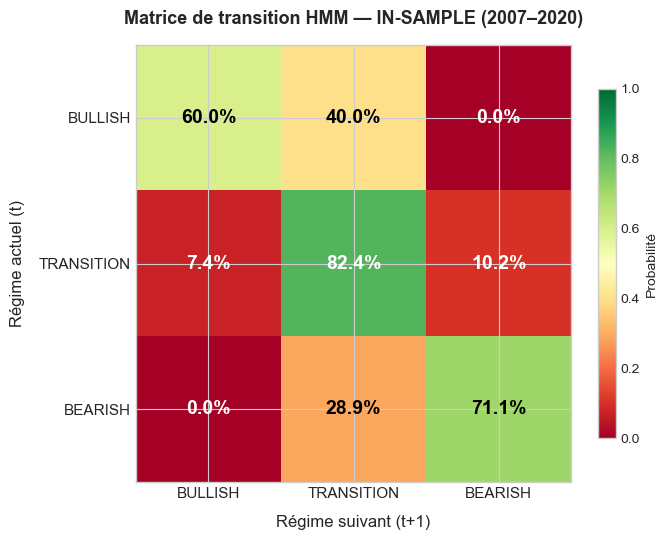

Sauvegardé : transition_matrix_is.png


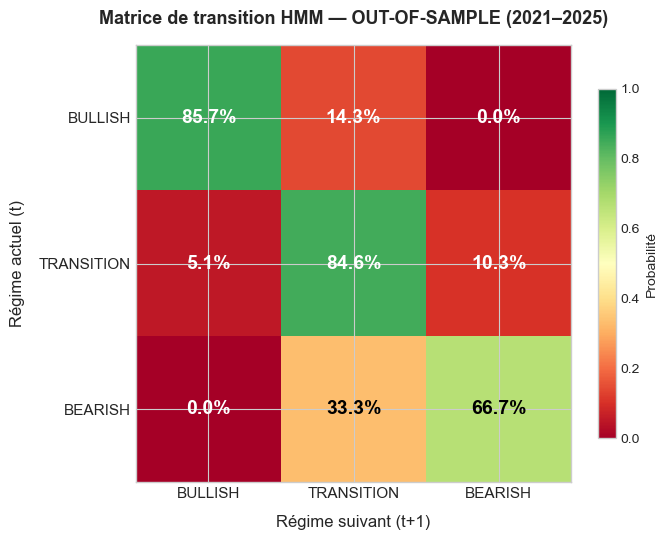

Sauvegardé : transition_matrix_oos.png


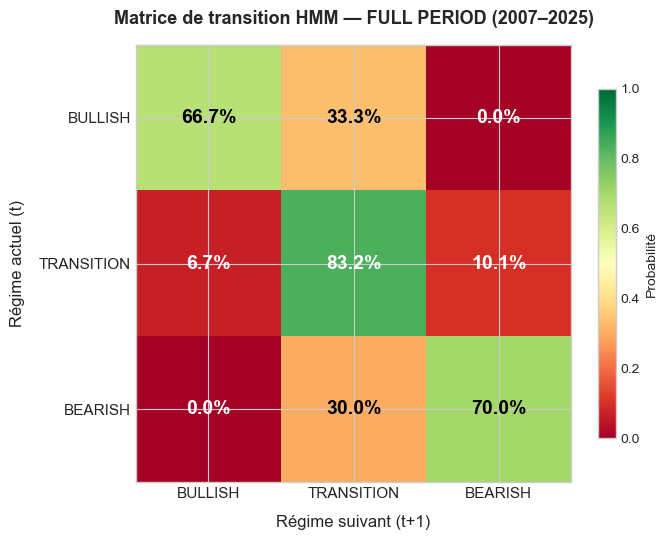

Sauvegardé : transition_matrix_full.png


In [15]:
# Matrices de proba
import matplotlib.pyplot as plt
import numpy as np

states = ["BULLISH", "TRANSITION", "BEARISH"]
n = len(states)

def plot_transition_matrix(regime_series, title, filename):
    regimes = regime_series.values
    trans_counts = np.zeros((n, n))
    for i in range(len(regimes) - 1):
        from_idx = states.index(regimes[i])
        to_idx   = states.index(regimes[i + 1])
        trans_counts[from_idx, to_idx] += 1

    row_sums = trans_counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    trans_probs = trans_counts / row_sums

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(trans_probs, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

    for i in range(n):
        for j in range(n):
            val = trans_probs[i, j]
            text_color = "black" if 0.2 < val < 0.8 else "white"
            ax.text(j, i, f"{val:.1%}",
                    ha="center", va="center",
                    fontsize=14, fontweight="bold", color=text_color)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(states, fontsize=11)
    ax.set_yticklabels(states, fontsize=11)
    ax.set_xlabel("Régime suivant (t+1)", fontsize=12, labelpad=10)
    ax.set_ylabel("Régime actuel (t)", fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Probabilité", fontsize=10)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Sauvegardé : {filename}")

# ── IS ──────────────────────────────────────────────────────────
plot_transition_matrix(
    _all_results_nested["IS"][best_config]["regime"],
    "Matrice de transition HMM — IN-SAMPLE (2007–2020)",
    "transition_matrix_is.png"
)

# ── OOS ─────────────────────────────────────────────────────────
plot_transition_matrix(
    _all_results_nested["OOS"][best_config]["regime"],
    "Matrice de transition HMM — OUT-OF-SAMPLE (2021–2025)",
    "transition_matrix_oos.png"
)

# ── FULL ────────────────────────────────────────────────────────
plot_transition_matrix(
    _all_results_nested["FULL"][best_config]["regime"],
    "Matrice de transition HMM — FULL PERIOD (2007–2025)",
    "transition_matrix_full.png"
)

In [24]:
# Transitions de régimes OOS
regimes = _all_results_nested["OOS"][best_config]["regime"]

transitions = (regimes != regimes.shift(1)).sum() - 1  # -1 pour exclure le premier mois
print(f"Nombre de changements de régime OOS : {transitions}")
print(f"Nombre total de mois OOS : {len(regimes)}")
print(f"\nSéquence des régimes :")
prev = None
for date, reg in zip(_all_results_nested["OOS"][best_config]["date"], regimes):
    if reg != prev:
        print(f"  {date.strftime('%Y-%m')} → {reg}")
        prev = reg

Nombre de changements de régime OOS : 11
Nombre total de mois OOS : 59

Séquence des régimes :
  2021-02 → TRANSITION
  2021-08 → BEARISH
  2022-03 → TRANSITION
  2022-09 → BEARISH
  2022-10 → TRANSITION
  2023-01 → BULLISH
  2023-05 → TRANSITION
  2025-01 → BEARISH
  2025-03 → TRANSITION
  2025-06 → BEARISH
  2025-08 → TRANSITION
  2025-09 → BULLISH


In [25]:
# Transitions IS
regimes_is = _all_results_nested["IS"][best_config]["regime"]

transitions_is = (regimes_is != regimes_is.shift(1)).sum() - 1
print(f"Nombre de changements de régime IS : {transitions_is}")
print(f"Nombre total de mois IS : {len(regimes_is)}")
print(f"\nSéquence des régimes IS :")
prev = None
for date, reg in zip(_all_results_nested["IS"][best_config]["date"], regimes_is):
    if reg != prev:
        print(f"  {date.strftime('%Y-%m')} → {reg}")
        prev = reg

Nombre de changements de régime IS : 38
Nombre total de mois IS : 167

Séquence des régimes IS :
  2007-02 → TRANSITION
  2007-03 → BULLISH
  2008-03 → TRANSITION
  2008-06 → BEARISH
  2008-07 → TRANSITION
  2009-02 → BEARISH
  2009-08 → TRANSITION
  2010-01 → BEARISH
  2010-10 → TRANSITION
  2011-08 → BEARISH
  2012-04 → TRANSITION
  2012-06 → BEARISH
  2012-07 → TRANSITION
  2012-11 → BULLISH
  2013-01 → TRANSITION
  2013-05 → BEARISH
  2013-06 → TRANSITION
  2013-07 → BULLISH
  2013-08 → TRANSITION
  2013-12 → BULLISH
  2014-01 → TRANSITION
  2015-12 → BEARISH
  2016-05 → TRANSITION
  2016-06 → BULLISH
  2016-07 → TRANSITION
  2016-08 → BEARISH
  2016-09 → TRANSITION
  2016-10 → BULLISH
  2016-11 → TRANSITION
  2017-01 → BULLISH
  2017-02 → TRANSITION
  2019-05 → BEARISH
  2019-06 → TRANSITION
  2019-07 → BEARISH
  2019-09 → TRANSITION
  2020-05 → BEARISH
  2020-08 → TRANSITION
  2020-09 → BULLISH
  2020-10 → TRANSITION


In [26]:
for period, label in [("FULL", "2007-2025"), ("IS", "2007-2020"), ("OOS", "2021-2025")]:
    res = _all_results_nested[period][best_config]
    cumret_strat = res["capital"].iloc[-1] / res["capital"].iloc[0] - 1
    print(f"\n{label}")
    print(f"Stratégie : {cumret_strat:+.1%}")

# Pour HML et marché
import numpy as np
for period, (start, end) in [("FULL", ("2007-01", "2025-12")), ("IS", ("2007-01", "2020-12")), ("OOS", ("2021-01", "2025-12"))]:
    mask = (ff5.index >= start) & (ff5.index <= end)
    hml_cum = (1 + ff5.loc[mask, "HML"]/100).prod() - 1
    mkt_cum = (1 + ff5.loc[mask, "Mkt_ret"]).prod() - 1
    print(f"\n{period} — HML cumulé : {hml_cum:+.1%} | Marché cumulé : {mkt_cum:+.1%}")


2007-2025
Stratégie : +231.1%

2007-2020
Stratégie : +116.9%

2021-2025
Stratégie : +48.9%

FULL — HML cumulé : +1.7% | Marché cumulé : +116.1%

IS — HML cumulé : -42.9% | Marché cumulé : +49.9%

OOS — HML cumulé : +81.4% | Marché cumulé : +36.4%


In [27]:
# Rendements cumulés Stratégie + HML + Marché sur les 3 périodes

periods = {
    "FULL (2007-2025)": ("2007-01", "2025-12"),
    "IS   (2007-2020)": ("2007-01", "2020-12"),
    "OOS  (2021-2025)": ("2021-01", "2025-12"),
}

period_keys = {"FULL (2007-2025)": "FULL", "IS   (2007-2020)": "IS", "OOS  (2021-2025)": "OOS"}

print(f"{'Période':<20} {'Stratégie':>12} {'HML':>10} {'Marché':>10}")
print("-" * 55)

for label, (start, end) in periods.items():
    # Stratégie
    res = _all_results_nested[period_keys[label]][best_config]
    cum_strat = res["capital"].iloc[-1] / res["capital"].iloc[0] - 1

    # HML et Marché depuis FF5
    mask = (ff5.index >= start) & (ff5.index <= end)
    cum_hml = (1 + ff5.loc[mask, "HML"] / 100).prod() - 1
    cum_mkt = (1 + ff5.loc[mask, "Mkt_ret"]).prod() - 1

    print(f"{label:<20} {cum_strat:>+11.1%} {cum_hml:>+9.1%} {cum_mkt:>+9.1%}")

Période                 Stratégie        HML     Marché
-------------------------------------------------------
FULL (2007-2025)         +231.1%     +1.7%   +116.1%
IS   (2007-2020)         +116.9%    -42.9%    +49.9%
OOS  (2021-2025)          +48.9%    +81.4%    +36.4%


In [28]:
# Rendements annuels moyens IS (2007-2020)
import numpy as np

res_is = _all_results_nested["IS"][best_config].copy()
res_is["date"] = pd.to_datetime(res_is["date"])
res_is["year"] = res_is["date"].dt.year

# Stratégie : rendement annuel par année
annual_strat = res_is.groupby("year")["total_ret"].apply(
    lambda x: (1 + x).prod() - 1
)

# HML : rendement annuel par année
mask_is = (ff5.index >= "2007-01") & (ff5.index <= "2020-12")
ff5_is = ff5.loc[mask_is].copy()
ff5_is["year"] = ff5_is.index.year

annual_hml = ff5_is.groupby("year")["HML"].apply(
    lambda x: (1 + x/100).prod() - 1
)
annual_mkt = ff5_is.groupby("year")["Mkt_ret"].apply(
    lambda x: (1 + x).prod() - 1
)

# Tableau comparatif
print(f"{'Année':<8} {'Stratégie':>12} {'HML':>10} {'Marché':>10}")
print("-" * 43)
for year in annual_strat.index:
    print(f"{year:<8} {annual_strat[year]:>+11.1%} "
          f"{annual_hml.get(year, float('nan')):>+9.1%} "
          f"{annual_mkt.get(year, float('nan')):>+9.1%}")

print("-" * 43)
print(f"{'Moyenne':<8} {annual_strat.mean():>+11.1%} "
      f"{annual_hml.mean():>+9.1%} "
      f"{annual_mkt.mean():>+9.1%}")

Année       Stratégie        HML     Marché
-------------------------------------------
2007           +6.1%     +0.2%    +12.3%
2008          -12.1%     -4.3%    -45.2%
2009          +10.4%     +3.3%    +35.8%
2010          +20.2%     -6.2%     +6.6%
2011           -0.8%    -13.4%    -12.6%
2012           +9.1%     +2.3%    +20.9%
2013          +15.1%     +8.9%    +28.1%
2014           +6.8%     -5.5%     -6.3%
2015          +14.2%    -15.0%     -0.6%
2016           +7.5%    +11.4%     -0.3%
2017           +7.3%     +2.2%    +27.7%
2018           -6.7%     -3.8%    -16.0%
2019           +6.7%     -9.2%    +21.0%
2020           +1.5%    -20.1%     +2.9%
-------------------------------------------
Moyenne        +6.1%     -3.5%     +5.3%


In [29]:
# CAGR Stratégie sur toute la période (2007-2025)

res_full = _all_results_nested["FULL"][best_config]

capital_debut = res_full["capital"].iloc[0]
capital_fin   = res_full["capital"].iloc[-1]
n_mois        = len(res_full)
n_ans         = n_mois / 12

cagr = (capital_fin / capital_debut) ** (1 / n_ans) - 1

print(f"Capital initial  : {capital_debut:,.0f} EUR")
print(f"Capital final    : {capital_fin:,.0f} EUR")
print(f"Durée            : {n_ans:.1f} ans ({n_mois} mois)")
print(f"CAGR Stratégie   : {cagr:+.2%}")

Capital initial  : 10,097,394 EUR
Capital final    : 33,431,889 EUR
Durée            : 18.9 ans (227 mois)
CAGR Stratégie   : +6.53%


In [30]:
# CAGR Stratégie OUT-OF-SAMPLE (2021-2025)

res_oos = _all_results_nested["OOS"][best_config]

capital_debut = res_oos["capital"].iloc[0]
capital_fin   = res_oos["capital"].iloc[-1]
n_mois        = len(res_oos)
n_ans         = n_mois / 12

cagr_oos = (capital_fin / capital_debut) ** (1 / n_ans) - 1

print(f"Capital initial  : {capital_debut:,.0f} EUR")
print(f"Capital final    : {capital_fin:,.0f} EUR")
print(f"Durée            : {n_ans:.1f} ans ({n_mois} mois)")
print(f"CAGR OOS         : {cagr_oos:+.2%}")

Capital initial  : 10,005,271 EUR
Capital final    : 14,900,063 EUR
Durée            : 4.9 ans (59 mois)
CAGR OOS         : +8.44%


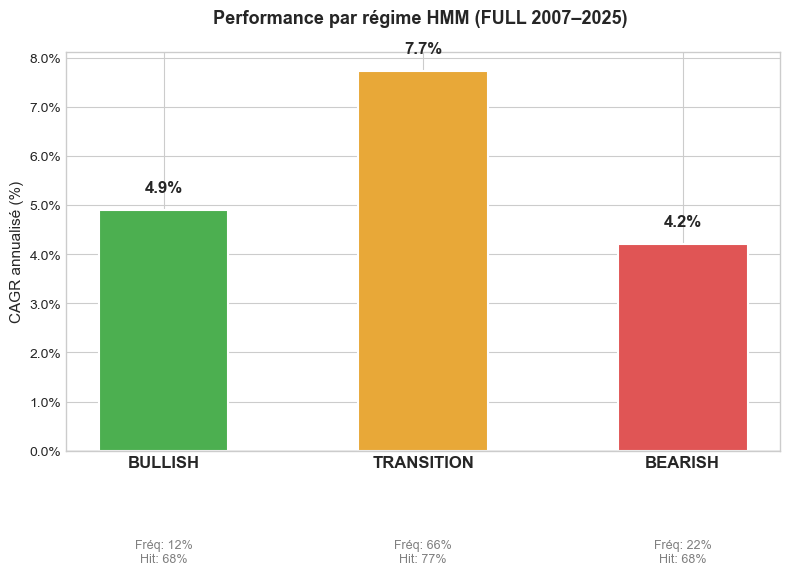

Sauvegardé : performance_par_regime.png


In [31]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 6))

# ================================================================
# GRAPHIQUE 2 — PERFORMANCE PAR CONDITIONS DE MARCHÉ (RÉGIMES HMM)
# ================================================================
res_full = _all_results_nested["FULL"][best_config].copy()
regimes_list = ["BULLISH", "TRANSITION", "BEARISH"]
colors_regime = {"BULLISH": "#4CAF50", "TRANSITION": "#E8A838", "BEARISH": "#E05555"}

for regime in regimes_list:
    sub = res_full[res_full["regime"] == regime]
    n_ans  = len(sub) / 12
    cagr_r = (1 + sub["total_ret"]).prod() ** (1/n_ans) - 1
    freq_r = len(sub) / len(res_full) * 100
    hit_r  = (sub["total_ret"] > 0).mean() * 100

    ax1.bar(regime, cagr_r * 100,
            color=colors_regime[regime], width=0.5,
            edgecolor="white", linewidth=1.5)
    ax1.text(regimes_list.index(regime), cagr_r * 100 + 0.3,
             f"{cagr_r*100:.1f}%",
             ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax1.text(regimes_list.index(regime), -1.8,
             f"Fréq: {freq_r:.0f}%\nHit: {hit_r:.0f}%",
             ha="center", va="top", fontsize=9, color="gray")

ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xticks(range(len(regimes_list)))
ax1.set_xticklabels(regimes_list, fontsize=12, fontweight="bold")
ax1.set_ylabel("CAGR annualisé (%)", fontsize=11)
ax1.set_title("Performance par régime HMM (FULL 2007–2025) \n",
              fontsize=13, fontweight="bold")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}%"))

plt.tight_layout()
plt.savefig("performance_par_regime.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegardé : performance_par_regime.png")